In [1]:
import pandas as pd
import requests
import json
from datetime import datetime

In [2]:
# 腾讯日线
def get_price_day_tx(code, end_date='', count=10, frequency='1d'):
    unit = 'week' if frequency in '1w' else 'month' if frequency in '1M' else 'day'
    if end_date:
        end_date = end_date.strftime('%Y-%m-%d') if isinstance(end_date, datetime.date) else end_date.split(' ')[0]
    end_date = '' if end_date == datetime.datetime.now().strftime('%Y-%m-%d') else end_date
    URL = f'http://web.ifzq.gtimg.cn/appstock/app/fqkline/get?param={code},{unit},,{end_date},{count},qfq'
    try:
        st = json.loads(requests.get(URL).content)
        ms = 'qfq' + unit
        stk = st['data'][code]
        buf = stk[ms] if ms in stk else stk[unit]
        df = pd.DataFrame(buf, columns=['time', 'open', 'close', 'high', 'low', 'volume'], dtype='float')
        df.time = pd.to_datetime(df.time)
        df.set_index(['time'], inplace=True)
        df.index.name = ''
        return df
    except Exception as e:
        print(f"获取日线数据出错: {e}")
        return None

In [3]:
# 腾讯分钟线
def get_price_min_tx(code, end_date=None, count=10, frequency='1d'):
    ts = int(frequency[:-1]) if frequency[:-1].isdigit() else 1
    if end_date:
        end_date = end_date.strftime('%Y-%m-%d') if isinstance(end_date, datetime.date) else end_date.split(' ')[0]
    URL = f'http://ifzq.gtimg.cn/appstock/app/kline/mkline?param={code},m{ts},,{count}'
    try:
        st = json.loads(requests.get(URL).content)
        buf = st['data'][code]['m' + str(ts)]
        df = pd.DataFrame(buf, columns=['time', 'open', 'close', 'high', 'low', 'volume', 'n1', 'n2'])
        df = df[['time', 'open', 'close', 'high', 'low', 'volume']]
        df[['open', 'close', 'high', 'low', 'volume']] = df[['open', 'close', 'high', 'low', 'volume']].astype('float')
        df.time = pd.to_datetime(df.time)
        df.set_index(['time'], inplace=True)
        df.index.name = ''
        df['close'][-1] = float(st['data'][code]['qt'][code][3])
        return df
    except Exception as e:
        print(f"获取分钟线数据出错: {e}")
        return None

In [4]:
# 新浪全周期获取函数
def get_price_sina(code, end_date='', count=10, frequency='60m'):
    frequency = frequency.replace('1d', '240m').replace('1w', '1200m').replace('1M', '7200m')
    ts = int(frequency[:-1]) if frequency[:-1].isdigit() else 1
    if (end_date != '') & (frequency in ['240m', '1200m', '7200m']):
        end_date = pd.to_datetime(end_date) if not isinstance(end_date, datetime.date) else end_date
        unit = 4 if frequency == '1200m' else 29 if frequency == '7200m' else 1
        count = count + (datetime.datetime.now() - end_date).days // unit
    URL = f'http://money.finance.sina.com.cn/quotes_service/api/json_v2.php/CN_MarketData.getKLineData?symbol={code}&scale={ts}&ma=5&datalen={count}'
    try:
        dstr = json.loads(requests.get(URL).content)
        df = pd.DataFrame(dstr, columns=['day', 'open', 'high', 'low', 'close', 'volume'])
        df['open'] = df['open'].astype(float)
        df['high'] = df['high'].astype(float)
        df['low'] = df['low'].astype(float)
        df['close'] = df['close'].astype(float)
        df['volume'] = df['volume'].astype(float)
        df.day = pd.to_datetime(df.day)
        df.set_index(['day'], inplace=True)
        df.index.name = ''
        if (end_date != '') & (frequency in ['240m', '1200m', '7200m']):
            return df[df.index <= end_date][-count:]
        return df
    except Exception as e:
        print(f"获取新浪数据出错: {e}")
        return None

In [5]:
def get_price(code, end_date='', count=10, frequency='1d', fields=[]):
    xcode = code.replace('.XSHG', '').replace('.XSHE', '')
    xcode = 'sh' + xcode if ('XSHG' in code) else 'sz' + xcode if ('XSHE' in code) else code

    if frequency in ['1d', '1w', '1M']:
        try:
            return get_price_sina(xcode, end_date=end_date, count=count, frequency=frequency)
        except:
            return get_price_day_tx(xcode, end_date=end_date, count=count, frequency=frequency)

    if frequency in ['1m', '5m', '15m', '30m', '60m']:
        if frequency == '1m':
            return get_price_min_tx(xcode, end_date=end_date, count=count, frequency=frequency)
        try:
            return get_price_sina(xcode, end_date=end_date, count=count, frequency=frequency)
        except:
            return get_price_min_tx(xcode, end_date=end_date, count=count, frequency=frequency)

In [6]:
import akshare as ak

In [7]:
import pandas as pd
from datetime import datetime, timedelta

# 1. 计算日期区间
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)          # 365 天前
start_str = start_dt.strftime('%Y%m%d')
end_str   = end_dt.strftime('%Y%m%d')

# 2. 股票代码（示例：贵州茅台）
#    AkShare A 股格式：去掉后缀，6 位数字
symbol_code = '600519'          # 贵州茅台
# 如果要加交易所后缀，上证 6 开头用 .SH，深证 0/3 开头用 .SZ
# 这里 ak.stock_zh_a_hist 不需要后缀！

# 3. 拉取数据（前复权）
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

In [8]:
df_raw

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2024-12-24,600519,1473.44,1487.26,1492.44,1470.03,22105,3.394160e+09,1.52,0.84,12.37,0.18
1,2024-12-25,600519,1487.24,1478.44,1487.24,1474.54,17123,2.621062e+09,0.85,-0.59,-8.82,0.14
2,2024-12-26,600519,1482.44,1476.23,1487.22,1471.44,18287,2.798840e+09,1.07,-0.15,-2.21,0.15
3,2024-12-27,600519,1477.34,1477.41,1484.44,1467.94,20759,3.170191e+09,1.12,0.08,1.18,0.17
4,2024-12-30,600519,1482.41,1473.44,1492.40,1473.44,25130,3.849543e+09,1.28,-0.27,-3.97,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...
239,2025-12-18,600519,1409.54,1407.04,1414.92,1402.15,17830,2.551178e+09,0.91,-0.15,-2.10,0.14
240,2025-12-19,600519,1410.00,1410.00,1412.45,1401.01,26509,3.733028e+09,0.81,0.21,2.96,0.21
241,2025-12-22,600519,1410.00,1408.26,1414.14,1406.58,20426,2.881637e+09,0.54,-0.12,-1.74,0.16
242,2025-12-23,600519,1408.26,1407.86,1412.93,1397.19,24507,3.445377e+09,1.12,-0.03,-0.40,0.20


In [9]:
import numpy as np
import mplfinance as mpf

In [10]:
# 2. 整理成英文列名并设 Date 为索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '收盘': 'Close',
                       '最高': 'High',
                       '最低': 'Low',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

In [11]:
# 3. 计算 50 日均线
df['MA50'] = df['Close'].rolling(window=50).mean()

# 伞形线识别

In [12]:
def identify_umbrella_lines(
        data: pd.DataFrame,
        body_ratio: float = 0.3,
        lower_shadow_min: float = 2.0,
        upper_shadow_max: float = 0.1,
        trend_lookback: int = 5,
        use_ma50: bool = True,
) -> pd.DataFrame:
    """
    识别伞形线，并区分锤子线（Hammer）与上吊线（Hanging Man）

    要求原始列：Open, High, Low, Close
    可选列：MA50（如果 use_ma50=True 且已有则复用，否则自动计算）

    参数说明：
    - body_ratio:   实体占当日高低区间的最大比例（越小越“纺锤/伞形”）
    - lower_shadow_min: 下影线长度至少是实体的多少倍
    - upper_shadow_max: 上影线长度不超过实体的多少倍
    - trend_lookback:   回看 N 根K线，用收盘价判断是上涨趋势还是下跌趋势
    - use_ma50:    是否使用 MA50 作为“上/下方”辅助过滤
    """

    df = data.copy()

    # -------- 1. 预计算基础量 --------
    o, h, l, c = df['Open'], df['High'], df['Low'], df['Close']

    real_body = (c - o).abs()
    total_range = (h - l).replace(0, np.nan)  # 防止除零
    lower_shadow = np.minimum(o, c) - l
    upper_shadow = h - np.maximum(o, c)

    df['Entity'] = real_body
    df['Lower_Shadow'] = lower_shadow
    df['Upper_Shadow'] = upper_shadow

    # -------- 2. 形态：是否为“伞形线” --------
    # 实体较小 + 下影够长 + 上影很短
    body_small = (real_body / total_range) <= body_ratio
    long_lower = lower_shadow >= lower_shadow_min * real_body
    short_upper = upper_shadow <= upper_shadow_max * real_body

    umbrella = body_small & long_lower & short_upper

    # -------- 3. 趋势过滤：区分锤子线 / 上吊线 --------
    # 3.1 MA50 作为辅助（可选）
    if use_ma50:
        if 'MA50' not in df.columns:
            df['MA50'] = c.rolling(window=50, min_periods=1).mean()
        ma50 = df['MA50']
        close_above_ma = c > ma50
        close_below_ma = c < ma50
    else:
        # 不用 MA50，只用趋势来区分
        close_above_ma = pd.Series(False, index=df.index)
        close_below_ma = pd.Series(False, index=df.index)

    # 3.2 短期趋势：用 N 根前的收盘价判断涨跌
    prev_close = c.shift(trend_lookback)
    down_trend = prev_close.notna() & (c < prev_close)   # 之前在跌
    up_trend   = prev_close.notna() & (c > prev_close)   # 之前在涨

    # -------- 4. 最终信号 --------
    # 锤子线：伞形线 + 之前有下跌趋势 + （可选）当前在 MA50 下方
    hammer = umbrella & down_trend & ( (~use_ma50) | close_below_ma )

    # 上吊线：伞形线 + 之前有上涨趋势 + （可选）当前在 MA50 上方
    hanging_man = umbrella & up_trend & ( (~use_ma50) | close_above_ma )

    df['Hammer'] = hammer
    df['Hanging_Man'] = hanging_man

    # -------- 5. 上吊线验证信号（可选）--------
    # 条件：次日收盘价 < 上吊线实体中点
    body_mid = (o + c) / 2
    next_close = c.shift(-1)
    hanging_valid = hanging_man & (next_close < body_mid)
    df['Hanging_Man_Valid'] = hanging_valid

    return df


In [13]:
df = identify_umbrella_lines(df)

In [14]:
# 5. 构造 mplfinance 附加图层
addplots = [mpf.make_addplot(df['MA50'], color='blue', width=1.2, title='MA50')]

In [15]:
# 信号散点位置
# 锤子线：在最低价下方一点画绿色上箭头
hammer_sig = np.where(df['Hammer'], df['Low'] * 0.99, np.nan)

# 上吊线：在最高价上方一点画红色下箭头
hanging_sig = np.where(df['Hanging_Man_Valid'], df['High'] * 1.01, np.nan)

# 只有存在信号时才添加图层
if not np.all(np.isnan(hammer_sig)):
    addplots.append(
        mpf.make_addplot(
            hammer_sig,
            type='scatter',
            markersize=80,
            marker='^',
            color='green',
            label='Hammer'
        )
    )

if not np.all(np.isnan(hanging_sig)):
    addplots.append(
        mpf.make_addplot(
            hanging_sig,
            type='scatter',
            markersize=80,
            marker='v',
            color='red',
            label='Hanging Man (valid)'
        )
    )


E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20254 (\N{CJK UNIFIED IDEOGRAPH-4F1E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35782 (\N{CJK UNIFIED IDEOGRAPH-8BC6}) missing from fon

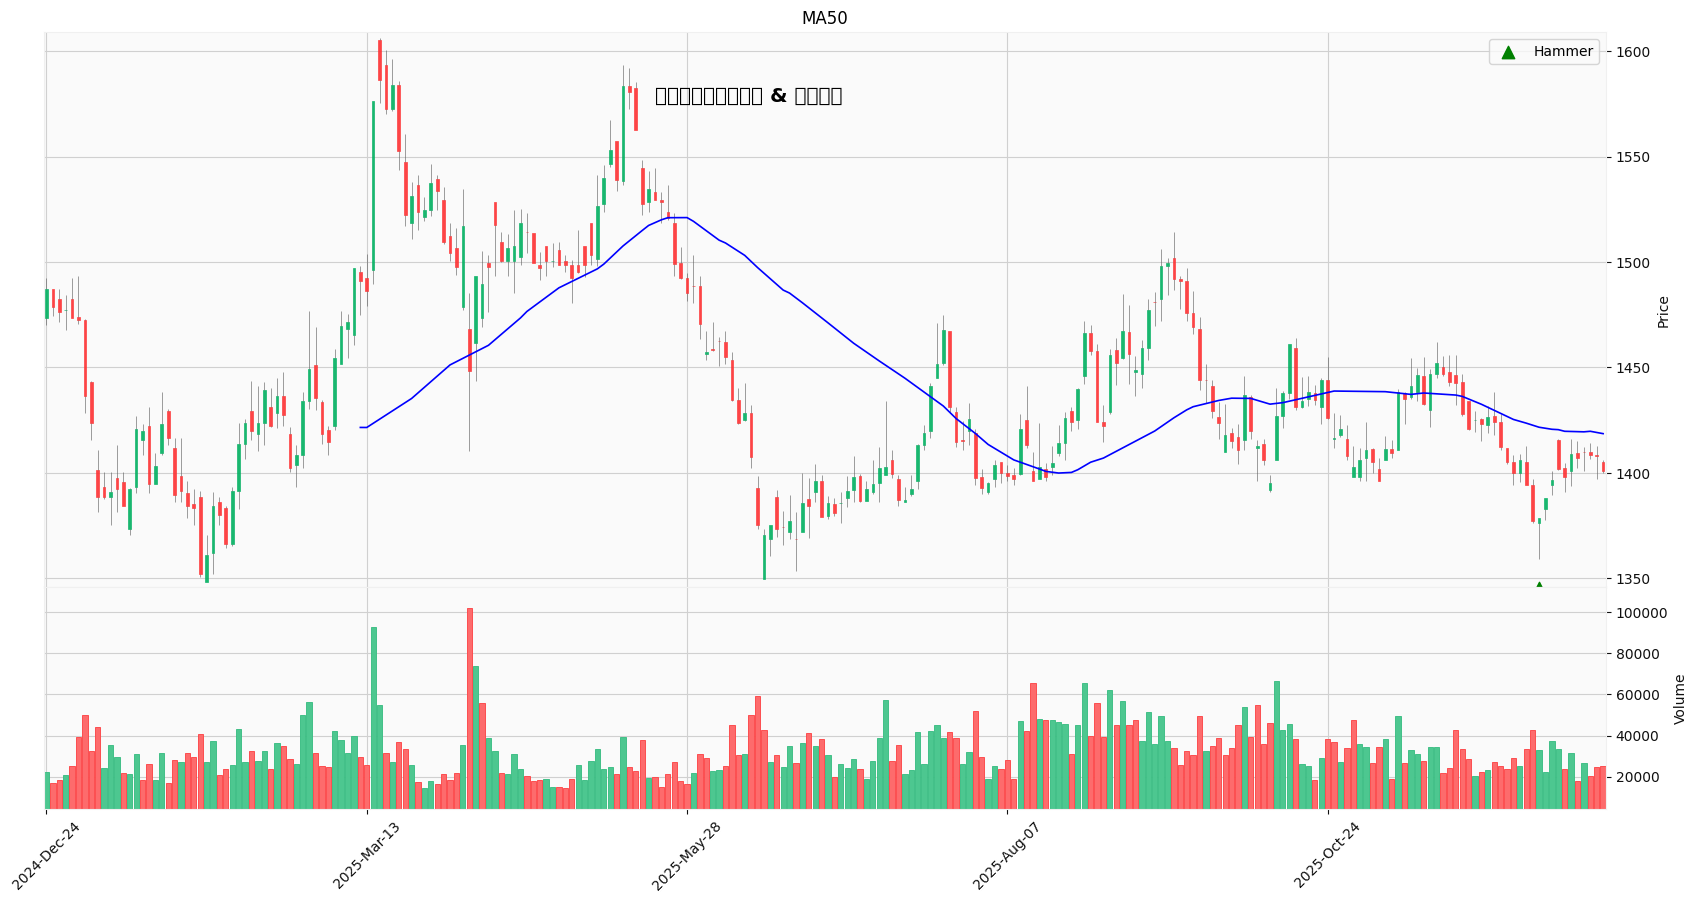

In [16]:
 mpf.plot(
    df,
    type='candle',
    style='yahoo',
    title='伞形线识别（锤子线 & 上吊线）',
    ylabel='Price',
    volume=True,
    addplot=addplots,
    figsize=(18, 9),
    tight_layout=True,
)

# 吞没形态

C:\Users\Lyj15\AppData\Local\Temp\ipykernel_12708\874924349.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  color_opposite_or_doji = ((bull2 & bear1) | (bear2 & bull1) | doji1.fillna(False))
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21534 (\N{CJK UNIFIED IDEOGRAPH-541E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27809 (\N{CJK UNIFIED IDEOGRAPH-6CA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Ba

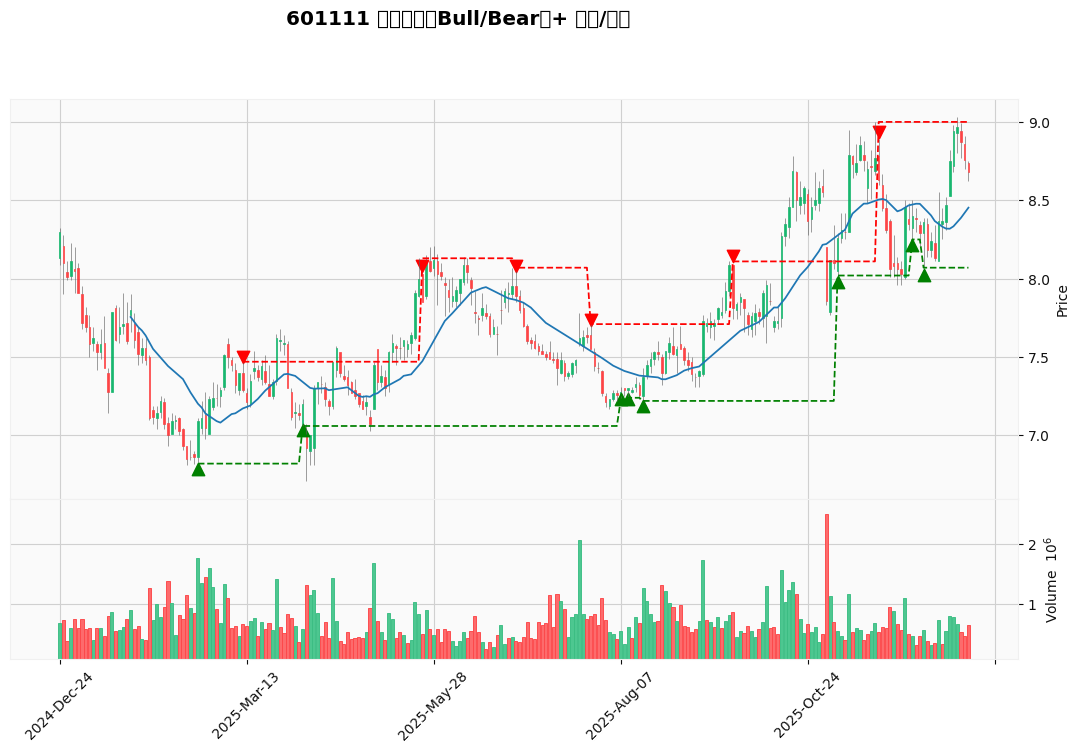

In [17]:
# ========= 1. 用 AkShare 取最近 365 天前复权数据 =========
symbol_code = '601111'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列名 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 原吞没识别逻辑（无需改动） =========
ma_len = 20
vol_ma_len = 20
small_body_pct = 0.10
use_equal_ok = True
vol_filter = False
confirm_close = False
confirm_shift = 1

df["Body"] = (df["Close"] - df["Open"]).abs()
df["Range"] = (df["High"] - df["Low"]).replace(0, np.nan)
df["Bull"] = (df["Close"] > df["Open"]).astype(int)
df["Bear"] = (df["Close"] < df["Open"]).astype(int)
df["DojiSmall"] = (df["Body"] <= small_body_pct * df["Range"]).fillna(False)
df["MA"] = df["Close"].rolling(ma_len).mean()
df["VOL_MA"] = df["Volume"].rolling(vol_ma_len).mean()
df["DownTrend"] = df["Close"] < df["MA"]
df["UpTrend"] = df["Close"] > df["MA"]

o1, h1, l1, c1 = [df[c].shift(1) for c in ["Open", "High", "Low", "Close"]]
bull1, bear1, doji1 = df["Bull"].shift(1) == 1, df["Bear"].shift(1) == 1, df["DojiSmall"].shift(1)
o2, h2, l2, c2 = df["Open"], df["High"], df["Low"], df["Close"]
bull2, bear2 = df["Bull"] == 1, df["Bear"] == 1

if use_equal_ok:
    engulf_body = (np.minimum(o2, c2) <= np.minimum(o1, c1)) & (np.maximum(o2, c2) >= np.maximum(o1, c1))
else:
    engulf_body = (np.minimum(o2, c2) < np.minimum(o1, c1)) & (np.maximum(o2, c2) > np.maximum(o1, c1))

color_opposite_or_doji = ((bull2 & bear1) | (bear2 & bull1) | doji1.fillna(False))
vol_ok = df["Volume"] > df["VOL_MA"] if vol_filter else pd.Series(True, index=df.index)

bull_basic = engulf_body & color_opposite_or_doji & df["DownTrend"] & bull2 & vol_ok
bear_basic = engulf_body & color_opposite_or_doji & df["UpTrend"] & bear2 & vol_ok

if confirm_close:
    bull_confirm = df["Close"].shift(-confirm_shift) > df["Close"]
    bear_confirm = df["Close"].shift(-confirm_shift) < df["Close"]
    df["Bull_Engulf"] = bull_basic & bull_confirm
    df["Bear_Engulf"] = bear_basic & bear_confirm
else:
    df["Bull_Engulf"] = bull_basic
    df["Bear_Engulf"] = bear_basic

# 支撑/阻力
bull_sr = np.minimum(l1, l2)
bear_sr = np.maximum(h1, h2)
df["Bull_SR"] = np.where(df["Bull_Engulf"], bull_sr, np.nan)
df["Bear_SR"] = np.where(df["Bear_Engulf"], bear_sr, np.nan)

# ========= 3. 可视化（mplfinance） =========
apds = [mpf.make_addplot(df["MA"], panel=0)]
bull_marks = np.where(df["Bull_Engulf"], df["Low"] - df["Range"] * 0.15, np.nan)
bear_marks = np.where(df["Bear_Engulf"], df["High"] + df["Range"] * 0.15, np.nan)
apds += [
    mpf.make_addplot(bull_marks, type="scatter", marker="^", markersize=80, color='green'),
    mpf.make_addplot(bear_marks, type="scatter", marker="v", markersize=80, color='red')
]
df["Bull_SR_plot"] = df["Bull_SR"].ffill()
df["Bear_SR_plot"] = df["Bear_SR"].ffill()
apds += [
    mpf.make_addplot(df["Bull_SR_plot"], panel=0, color='green', linestyle='--'),
    mpf.make_addplot(df["Bear_SR_plot"], panel=0, color='red', linestyle='--')
]

mpf.plot(df, type="candle", volume=True, addplot=apds,
         title=f"{symbol_code} 吞没形态（Bull/Bear）+ 支撑/阻力",
         style="yahoo", figsize=(14, 8))

# 乌云盖顶

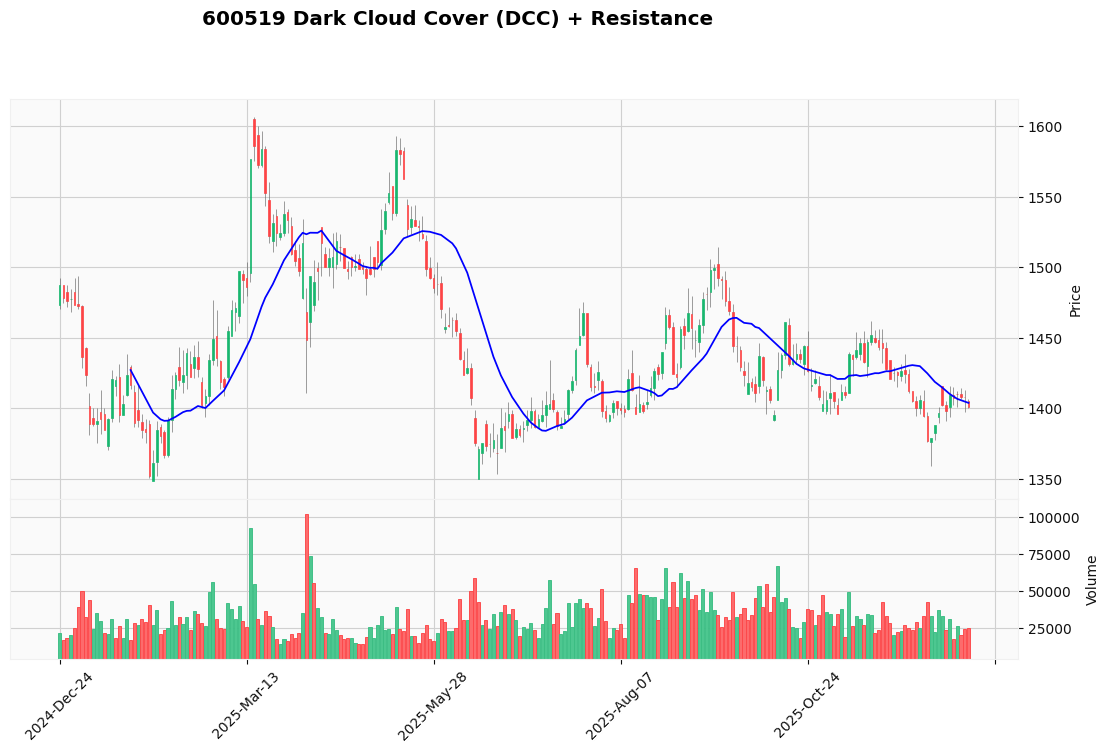

In [18]:
# ========= 1. AkShare 取数 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 原 DCC 逻辑（无改动） =========
ma_len            = 20
vol_ma_len        = 20
gap_strict        = True
gap_tolerance_pct = 0.05
require_midpoint  = True
use_confirm       = False
confirm_shift     = 1
use_vol_filter    = False
use_trend_filter  = True

df["MA"]      = df["Close"].rolling(ma_len).mean()
df["VOL_MA"]  = df["Volume"].rolling(vol_ma_len).mean()

o1,h1,l1,c1 = [df[c].shift(1) for c in ["Open","High","Low","Close"]]
o2,h2,l2,c2 = df["Open"], df["High"], df["Low"], df["Close"]

bull1 = c1 > o1
bear2 = c2 < o2

if gap_strict:
    gap_ok = o2 > h1
else:
    gap_ok = o2 >= (h1 * (1 - gap_tolerance_pct))

into_body = c2 < c1
deep_into = c2 < ((o1 + c1) / 2) if require_midpoint else c2 < c1

trend_ok = (df["Close"] > df["MA"]) if use_trend_filter else pd.Series(True, index=df.index)
vol_ok   = (df["Volume"] > df["VOL_MA"]) if use_vol_filter else pd.Series(True, index=df.index)

dcc_basic = bull1 & bear2 & gap_ok & deep_into & trend_ok & vol_ok

if use_confirm:
    confirm_ok = df["Close"].shift(-confirm_shift) < df["Close"]
    dcc = dcc_basic & confirm_ok
else:
    dcc = dcc_basic

df["Bear_DCC"] = dcc

# 阻力位
dcc_resist = np.maximum(h1, h2)
df["DCC_Resist"] = np.where(df["Bear_DCC"], dcc_resist, np.nan)
df["DCC_Resist_plot"] = df["DCC_Resist"].ffill()

# 3. 可视化（过滤掉全 nan 的图层）
apds = [mpf.make_addplot(df["MA"], color='blue')]

rng = (df["High"] - df["Low"]).replace(0, 1e-6)
dcc_marks = np.where(df["Bear_DCC"], df["High"] + rng * 0.15, np.nan)

# 只把「至少有一个有效值」的图层加进去
if not np.all(np.isnan(dcc_marks)):
    apds += [mpf.make_addplot(dcc_marks, type="scatter", marker="v", markersize=80, color='red')]

# 阻力线同样处理
if not np.all(np.isnan(df["DCC_Resist_plot"])):
    apds += [mpf.make_addplot(df["DCC_Resist_plot"], color='red', linestyle='--')]

# 真正画图
mpf.plot(df, type="candle", volume=True, addplot=apds,
         title=f"{symbol_code} Dark Cloud Cover (DCC) + Resistance",
         style="yahoo", figsize=(14, 8))


# 刺透形态

刺透形态出现次数：10
               Open     High      Low    Close
Date                                          
2025-09-29  1415.42  1446.03  1411.04  1436.90
2025-11-06  1406.04  1417.49  1406.03  1411.17
2025-11-28  1422.54  1431.54  1419.04  1426.54
2025-12-05  1400.02  1409.13  1395.54  1406.05
2025-12-17  1401.04  1415.98  1393.72  1409.14


E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21050 (\N{CJK UNIFIED IDEOGRAPH-523A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from fon

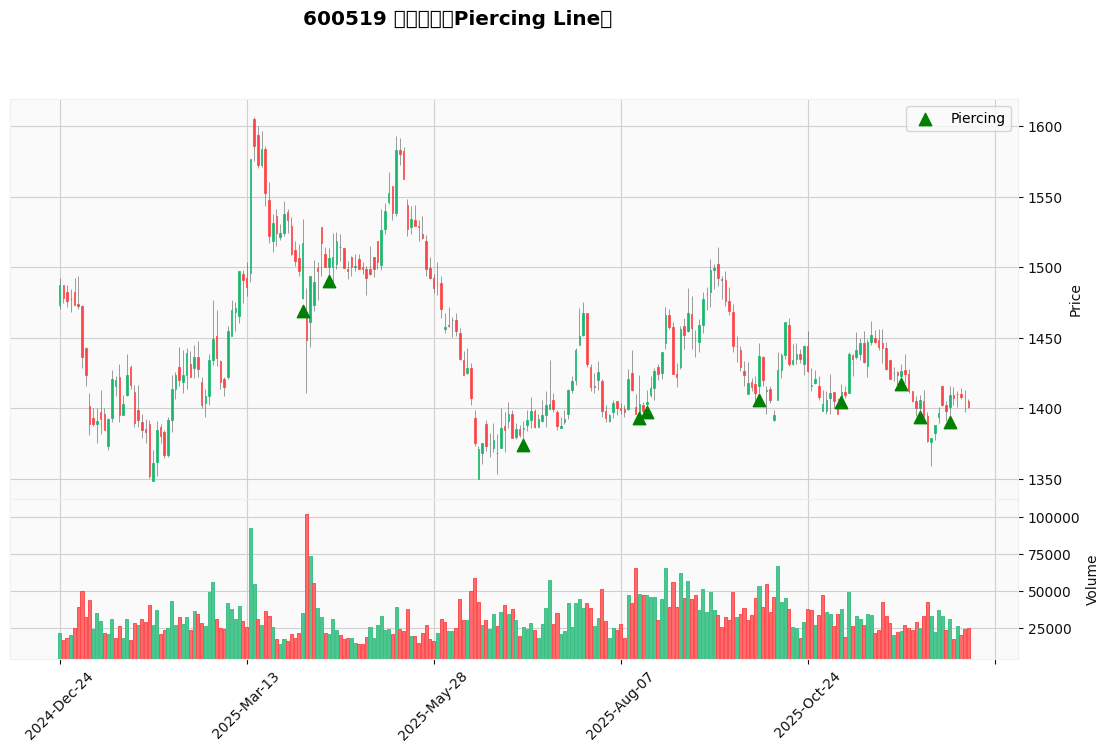

In [19]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

# 整理成英文列 + Date 索引
df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)


# ========= 2. 严格版刺透形态（保持你原来的定义） =========
def piercing_line_strict(data: pd.DataFrame) -> pd.Series:
    """
    严格刺透形态：
    1. 前阴（Close1 < Open1）
    2. 今阳（Close2 > Open2）
    3. 今开 < 前低（跳空低开）
    4. 今收 > 前实体 50%
    """
    prev = data.shift(1)

    cond1 = prev['Close'] < prev['Open']           # 前阴
    cond2 = data['Close'] > data['Open']           # 今阳
    cond3 = data['Open'] < prev['Low']             # 今开 < 前低
    mid_prev = (prev['Open'] + prev['Close']) / 2  # 前实体中点
    cond4 = data['Close'] > mid_prev               # 今收 > 前实体 50%

    return cond1 & cond2 & cond3 & cond4


# ========= 3. 实战增强版刺透形态 =========
def piercing_line(
        data: pd.DataFrame,
        ma_len: int = 20,
        use_trend_filter: bool = True,
        allow_soft_gap: bool = True,
        gap_tolerance_pct: float = 0.01,
        pierce_ratio: float = 0.5,
) -> pd.Series:
    """
    实战增强版刺透形态：
    - 在严格定义基础上加入：
      1) 趋势过滤：要求处于下跌趋势（Close < MA）
      2) 宽松缺口：允许今开略高于前低（可调 gap_tolerance_pct）
      3) 可调穿透比例 pierce_ratio（>0.5 更保守）
    """
    data = data.copy()
    prev = data.shift(1)

    # 基础条件：前阴 / 今阳
    cond1 = prev['Close'] < prev['Open']
    cond2 = data['Close'] > data['Open']

    # 缺口条件
    if allow_soft_gap:
        # 允许今开略高于前低（如 1% 容差）
        cond3 = data['Open'] <= prev['Low'] * (1 + gap_tolerance_pct)
    else:
        cond3 = data['Open'] < prev['Low']

    # 穿透比例（默认 50%）
    mid_prev = prev['Open'] + (prev['Close'] - prev['Open']) * pierce_ratio
    cond4 = data['Close'] > mid_prev

    # 趋势过滤：下跌趋势中才认定为底部反转
    if use_trend_filter:
        ma = data['Close'].rolling(ma_len).mean()
        downtrend = data['Close'] < ma
    else:
        downtrend = pd.Series(True, index=data.index)

    return cond1 & cond2 & cond3 & cond4 & downtrend


# 选择用哪个：严格版 or 增强版
signal = piercing_line(
    df,
    ma_len=20,
    use_trend_filter=True,
    allow_soft_gap=True,
    gap_tolerance_pct=0.01,
    pierce_ratio=0.5
)
df['Piercing'] = signal

# ========= 4. 结果检查 =========
n_sig = signal.sum()
print(f'刺透形态出现次数：{n_sig}')
if n_sig:
    print(df[['Open', 'High', 'Low', 'Close']].loc[signal].tail())
else:
    print('当前参数下无刺透形态，可放宽条件（allow_soft_gap=True / pierce_ratio<0.5）再试')


# ========= 5. 可视化 =========
apds = []

# 绿色箭头标注
if n_sig:   # 至少 1 个信号才添加图层，避免全 nan 报错
    rng = (df['High'] - df['Low']).replace(0, 1e-6)
    mark = np.where(signal, df['Low'] - rng * 0.15, np.nan)
    apds.append(
        mpf.make_addplot(
            mark,
            type='scatter',
            marker='^',
            markersize=80,
            color='green',
            label='Piercing'
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=apds,
    title=f'{symbol_code} 刺透形态（Piercing Line）',
    style='yahoo',
    figsize=(14, 8)
)


# 启明星

启明星出现次数：1
              Open     High      Low    Close
Date                                         
2025-12-11  1382.7  1388.03  1377.59  1388.03


E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21551 (\N{CJK UNIFIED IDEOGRAPH-542F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from fon

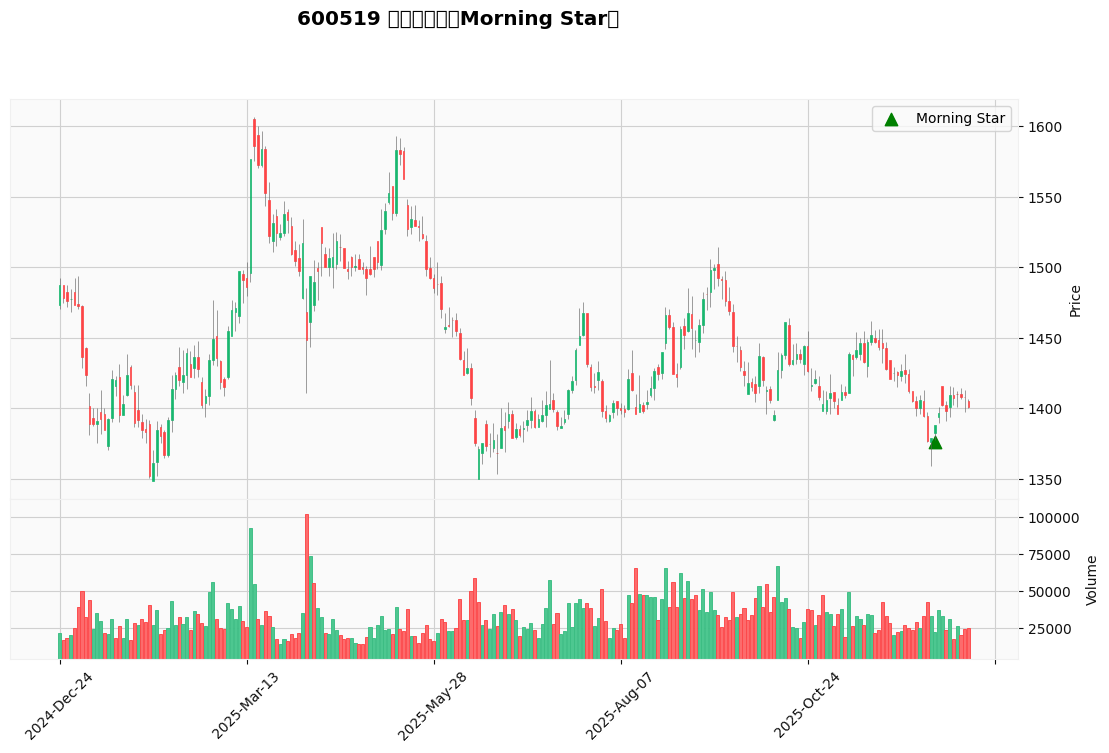

In [20]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 启明星形态识别（三K线） =========
def morning_star(df: pd.DataFrame,
                 ma_len: int = 20,
                 body_small_ratio: float = 0.3,
                 pierce_ratio: float = 0.5) -> pd.Series:
    """
    启明星形态（三K）识别：
    1) 下跌趋势：第一根收盘 < MA
    2) K1：长阴（实体大）
    3) K2：小实体星线（阴阳皆可），价位低于K1实体
    4) K3：长阳，收盘深刺进K1实体 >= pierce_ratio（默认 50%）
    注：A股缺口不明显，因此不强制要求实体完全跳空，只要求K2低位 & 小实体
    """
    prev2 = df.shift(2)   # K1
    prev1 = df.shift(1)   # K2
    curr  = df            # K3

    # 1. 趋势：以K1收盘对MA判断“下跌趋势”
    ma = df['Close'].rolling(ma_len).mean()
    downtrend = prev2['Close'] < ma.shift(2)

    # 实体与全日波动
    body1 = (prev2['Close'] - prev2['Open']).abs()
    range1 = (prev2['High'] - prev2['Low']).replace(0, np.nan)
    body2 = (prev1['Close'] - prev1['Open']).abs()
    range2 = (prev1['High'] - prev1['Low']).replace(0, np.nan)
    body3 = (curr['Close'] - curr['Open']).abs()
    range3 = (curr['High'] - curr['Low']).replace(0, np.nan)

    # 2. K1 长阴
    cond1 = (prev2['Close'] < prev2['Open']) & (body1 / range1 > 0.5)

    # 3. K2 小实体星线（阴阳皆可，小实体且处在K1下方）
    cond2_small = (body2 / range2 <= body_small_ratio)
    cond2_pos   = prev1['High'] < prev2['High']  # 大致在K1下方
    cond2 = cond2_small & cond2_pos

    # 4. K3 长阳，深刺K1实体
    cond3_bull = curr['Close'] > curr['Open']
    mid1 = prev2['Open'] + (prev2['Close'] - prev2['Open']) * pierce_ratio
    cond3_pierce = curr['Close'] > mid1
    cond3_long = (body3 / range3 > 0.5)
    cond3 = cond3_bull & cond3_pierce & cond3_long

    return downtrend & cond1 & cond2 & cond3


signal = morning_star(df, ma_len=20, body_small_ratio=0.3, pierce_ratio=0.5)
df['Morning_Star'] = signal

n_sig = signal.sum()
print(f'启明星出现次数：{n_sig}')
if n_sig:
    print(df[['Open','High','Low','Close']].loc[signal].tail())
else:
    print('当前参数下无启明星，可放宽 body_small_ratio 或 pierce_ratio 再试')

apds = []
if n_sig:
    mark = np.where(signal,
                    df['Low'] - (df['High'] - df['Low']) * 0.15,
                    np.nan)
    apds.append(
        mpf.make_addplot(mark, type='scatter', marker='^',
                         markersize=80, color='green',
                         label='Morning Star')
    )

mpf.plot(df, type='candle', volume=True, addplot=apds,
         title=f'{symbol_code} 启明星形态（Morning Star）',
         style='yahoo', figsize=(14, 8))


# 黄昏星

C:\Users\Lyj15\AppData\Local\Temp\ipykernel_22344\923588302.py:76: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Evening_Doji_Star"] = (signal & df["Doji"].shift(1).fillna(False))


黄昏星出现次数：0
当前参数下无黄昏星形态，可放宽条件再试


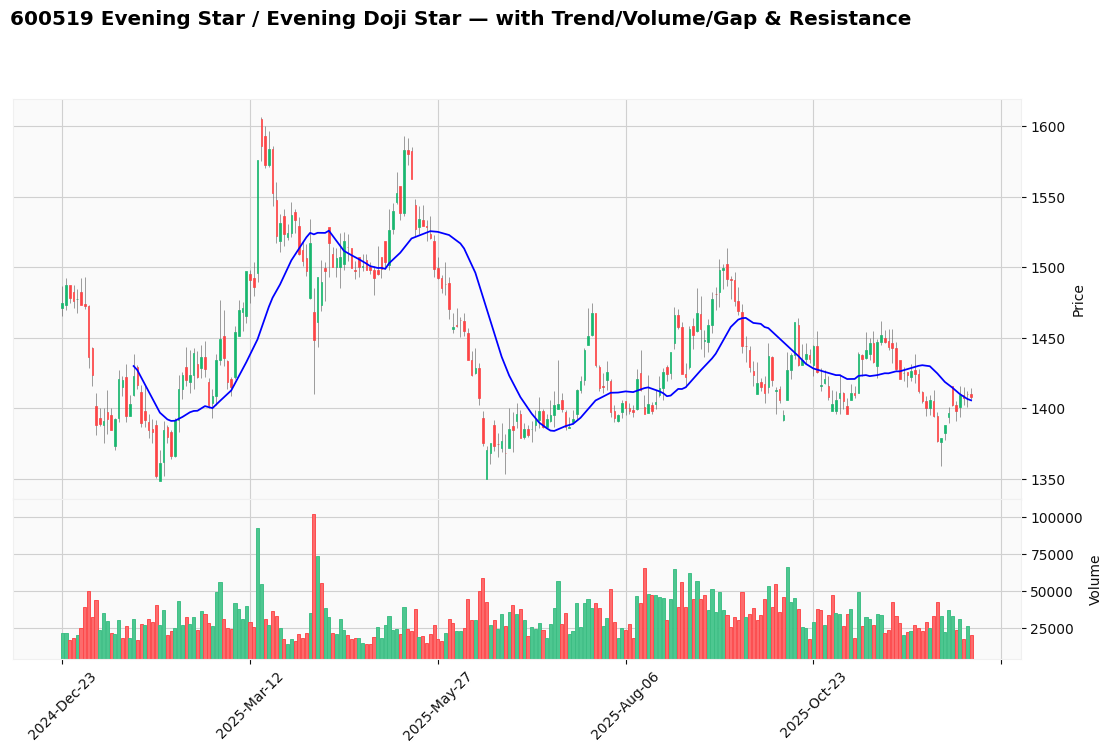

In [22]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 黄昏星识别（直接沿用你原函数逻辑） =========
# 为了简洁，这里只保留「黄昏星」核心逻辑，参数同你原文
ma_len = 20
vol_ma_len = 20
star_small_pct = 0.20
gap12_required = True
gap23_required = False
gap_tolerance_pct = 0.03
penetrate_req = 0.50
use_trend_filter = True
use_volume_filter = False
use_confirm = False
confirm_shift = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"] = (df["Close"] - df["Open"]).abs()
df["Doji"] = df["Body"] <= df["Range"] * 0.1
df["Star"] = df["Body"] <= df["Range"] * star_small_pct
df["MA"] = df["Close"].rolling(ma_len).mean()
df["VOL_MA"] = df["Volume"].rolling(vol_ma_len).mean()

def evening_star(data: pd.DataFrame) -> pd.Series:
    o1,h1,l1,c1 = [data[c].shift(2) for c in ["Open","High","Low","Close"]]
    o2,h2,l2,c2 = [data[c].shift(1) for c in ["Open","High","Low","Close"]]
    o3,h3,l3,c3 = data["Open"], data["High"], data["Low"], data["Close"]

    long_white_1 = (c1 > o1) & (c1 - o1 > (h1 - l1) * 0.5)
    is_star_2 = (c2 - o2).abs() <= (h2 - l2) * star_small_pct
    mid1 = (o1 + c1) / 2.0
    penetration_level = o1 + (c1 - o1) * (1 - penetrate_req)
    deep_bear_3 = (c3 < o3) & (c3 <= penetration_level)

    e1_low, e1_high = np.minimum(o1, c1), np.maximum(o1, c1)
    e2_low, e2_high = np.minimum(o2, c2), np.maximum(o2, c2)
    e3_low, e3_high = np.minimum(o3, c3), np.maximum(o3, c3)

    gap12 = e2_low > e1_high if gap12_required else e2_low >= (e1_high * (1 - gap_tolerance_pct))
    gap23 = e3_high < e2_low if gap23_required else e3_high <= (e2_low * (1 + gap_tolerance_pct))

    trend_ok = (data["Close"].shift(1) > data["MA"].shift(1)) if use_trend_filter else pd.Series(True, index=data.index)
    vol_ok = (data["Volume"] > data["VOL_MA"]) if use_volume_filter else pd.Series(True, index=data.index)

    basic = long_white_1 & is_star_2 & deep_bear_3 & gap12 & gap23 & trend_ok & vol_ok

    if use_confirm:
        confirm_ok = data["Close"].shift(-confirm_shift) < data["Close"]
        return basic & confirm_ok
    else:
        return basic

signal = evening_star(df)
df["Evening_Star"] = signal
df["Evening_Doji_Star"] = (signal & df["Doji"].shift(1).fillna(False))

# 阻力位
h1, h2, h3 = df["High"].shift(2), df["High"].shift(1), df["High"]
res_level = np.maximum.reduce([h1, h2, h3])
df["ES_Resist"] = np.where(df["Evening_Star"], res_level, np.nan)
df["ES_Resist_plot"] = df["ES_Resist"].ffill()

# ========= 3. 结果检查 =========
n_sig = signal.sum()
print(f'黄昏星出现次数：{n_sig}')
if n_sig:
    print(df[['Open', 'High', 'Low', 'Close']].loc[signal].tail())
else:
    print('当前参数下无黄昏星形态，可放宽条件再试')

# ========= 4. 可视化 =========
apds = [mpf.make_addplot(df["MA"], color='blue')]

rng = (df["High"] - df["Low"]).replace(0, 1e-6)
es_marks = np.where(df["Evening_Star"], df["High"] + rng * 0.15, np.nan)
eds_marks = np.where(df["Evening_Doji_Star"], df["High"] + rng * 0.28, np.nan)

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
if not np.all(np.isnan(es_marks)):
    apds.append(mpf.make_addplot(es_marks, type="scatter", marker="v", markersize=90, color="tab:red"))
if not np.all(np.isnan(eds_marks)):
    apds.append(mpf.make_addplot(eds_marks, type="scatter", marker="v", markersize=90, color="tab:orange"))
if not np.all(np.isnan(df["ES_Resist_plot"])):
    apds.append(mpf.make_addplot(df["ES_Resist_plot"], color="tab:red", linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=apds,
         title=f'{symbol_code} Evening Star / Evening Doji Star — with Trend/Volume/Gap & Resistance',
         style="yahoo", figsize=(14, 8))

# 十字启明星和十字黄昏星

十字黄昏星：0 次
十字启明星：0 次
弃婴顶部：0 次
弃婴底部：0 次


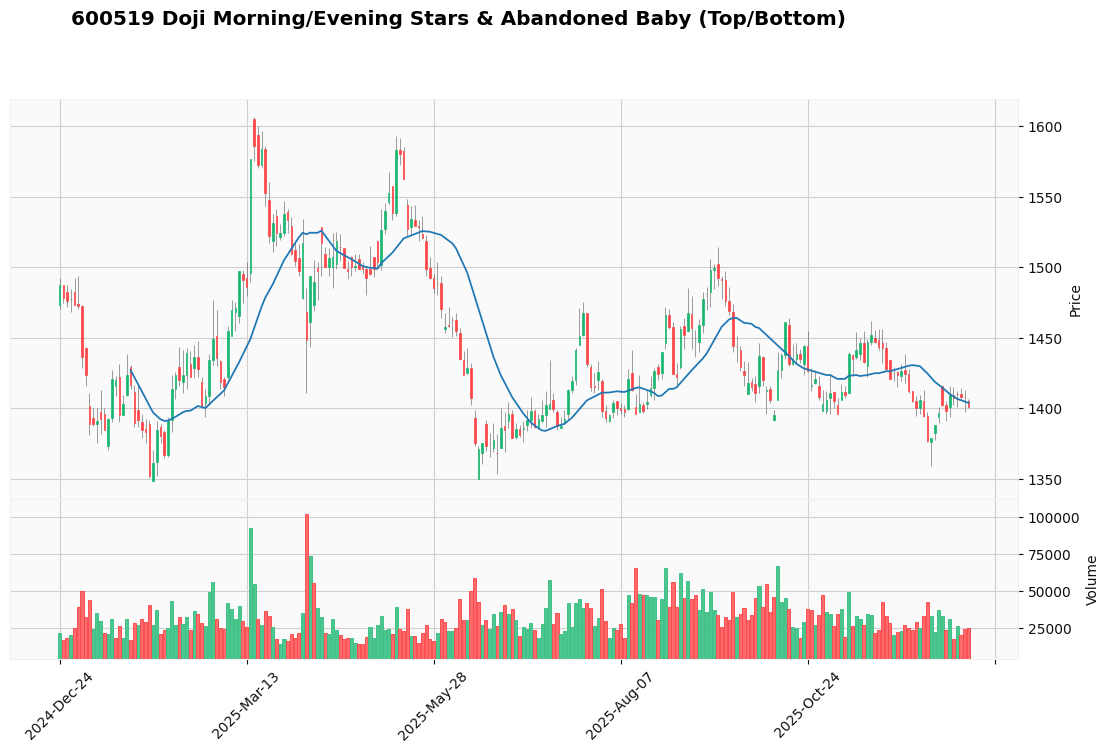

In [22]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 十字星形态识别（直接沿用你原函数逻辑） =========
ma_len = 20
vol_ma_len = 20
doji_thresh = 0.10
penetrate_req = 0.50
gap_tolerance_pct = 0.00
use_trend_filter = True
use_volume_filter = False
use_confirm = False
confirm_shift = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["Doji"]  = df["Body"] <= df["Range"] * doji_thresh
df["MA"]    = df["Close"].rolling(ma_len).mean()
df["VOL_MA"]= df["Volume"].rolling(vol_ma_len).mean()

def shift_cols(s):
    return [df[c].shift(s) for c in ["Open","High","Low","Close","Body","Range","Doji","Volume"]]

o1,h1,l1,c1,b1,r1,d1,v1 = shift_cols(2)
o2,h2,l2,c2,b2,r2,d2,v2 = shift_cols(1)
o3,h3,l3,c3,b3,r3,d3,v3 = shift_cols(0)

e1_low, e1_high = np.minimum(o1,c1), np.maximum(o1,c1)
e2_low, e2_high = np.minimum(o2,c2), np.maximum(o2,c2)
e3_low, e3_high = np.minimum(o3,c3), np.maximum(o3,c3)

uptrend_before   = df["Close"].shift(1) > df["MA"].shift(1)
downtrend_before = df["Close"].shift(1) < df["MA"].shift(1)
trend_up_ok   = uptrend_before if use_trend_filter else pd.Series(True, index=df.index)
trend_down_ok = downtrend_before if use_trend_filter else pd.Series(True, index=df.index)
vol_ok = (df["Volume"] > df["VOL_MA"]) if use_volume_filter else pd.Series(True, index=df.index)

# 十字黄昏星
pen_level_evening = o1 + (c1 - o1) * (1 - penetrate_req)
deep_bear3 = (c3 < o3) & (c3 <= pen_level_evening)
long_white1 = (c1 > o1) & (b1 > 0.5 * r1)
doji2 = d2.astype(bool)
gap12_star = e2_low > e1_high * (1 - gap_tolerance_pct)
evening_doji_basic = long_white1 & doji2 & deep_bear3 & trend_up_ok & vol_ok & gap12_star

confirm_evening = (df["Close"].shift(-confirm_shift) < df["Close"]) if use_confirm else pd.Series(True, index=df.index)
df["Doji_Evening_Star"] = evening_doji_basic & confirm_evening

# 十字启明星
pen_level_morning = c1 + (o1 - c1) * penetrate_req
deep_bull3 = (c3 > o3) & (c3 >= pen_level_morning)
long_black1 = (c1 < o1) & (b1 > 0.5 * r1)
gap12_star_dn = h2 < l1 * (1 + gap_tolerance_pct)
morning_doji_basic = long_black1 & doji2 & deep_bull3 & trend_down_ok & vol_ok & gap12_star_dn

confirm_morning = (df["Close"].shift(-confirm_shift) > df["Close"]) if use_confirm else pd.Series(True, index=df.index)
df["Doji_Morning_Star"] = morning_doji_basic & confirm_morning

# 弃婴顶部 & 底部
ab_top = (trend_up_ok & doji2 & (l2 > h1) & (h3 < l2) & (c3 < o3) & vol_ok)
ab_bot = (trend_down_ok & doji2 & (h2 < l1) & (l3 > h2) & (c3 > o3) & vol_ok)
df["Abandoned_Baby_Top"] = ab_top
df["Abandoned_Baby_Bot"] = ab_bot

# 阻力/支撑
df["Doji_Evening_Res"] = np.where(df["Doji_Evening_Star"], np.maximum.reduce([h1, h2, h3]), np.nan)
df["Doji_Morning_Sup"] = np.where(df["Doji_Morning_Star"], np.minimum.reduce([l1, l2, l3]), np.nan)
df["AB_Top_Res"] = np.where(df["Abandoned_Baby_Top"], np.maximum.reduce([h1, h2, h3]), np.nan)
df["AB_Bot_Sup"] = np.where(df["Abandoned_Baby_Bot"], np.minimum.reduce([l1, l2, l3]), np.nan)

# ========= 3. 结果检查 =========
n_evening = df["Doji_Evening_Star"].sum()
n_morning = df["Doji_Morning_Star"].sum()
n_abtop = df["Abandoned_Baby_Top"].sum()
n_abbot = df["Abandoned_Baby_Bot"].sum()
print(f'十字黄昏星：{n_evening} 次')
print(f'十字启明星：{n_morning} 次')
print(f'弃婴顶部：{n_abtop} 次')
print(f'弃婴底部：{n_abbot} 次')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]

rng = (df["High"] - df["Low"]).replace(0, 1e-6)
es_marks = np.where(df["Doji_Evening_Star"], df["High"] + rng * 0.18, np.nan)
ms_marks = np.where(df["Doji_Morning_Star"], df["Low"] - rng * 0.18, np.nan)
abtop_mk = np.where(df["Abandoned_Baby_Top"], df["High"] + rng * 0.30, np.nan)
abbot_mk = np.where(df["Abandoned_Baby_Bot"], df["Low"] - rng * 0.30, np.nan)

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
if not np.all(np.isnan(es_marks)):
    ap.append(mpf.make_addplot(es_marks, type="scatter", marker="v", markersize=90, color="tab:red"))
if not np.all(np.isnan(ms_marks)):
    ap.append(mpf.make_addplot(ms_marks, type="scatter", marker="^", markersize=90, color="tab:green"))
if not np.all(np.isnan(abtop_mk)):
    ap.append(mpf.make_addplot(abtop_mk, type="scatter", marker="v", markersize=120, color="crimson"))
if not np.all(np.isnan(abbot_mk)):
    ap.append(mpf.make_addplot(abbot_mk, type="scatter", marker="^", markersize=120, color="seagreen"))

# 阻力/支撑阶梯线
for col, color in zip(["Doji_Evening_Res", "Doji_Morning_Sup", "AB_Top_Res", "AB_Bot_Sup"],
                      ["tab:red", "tab:green", "maroon", "darkgreen"]):
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(mpf.make_addplot(plot_col, color=color, linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Doji Morning/Evening Stars & Abandoned Baby (Top/Bottom)',
         style="yahoo", figsize=(14, 8))


# 流星形态与倒锤子形态

流星出现次数：6
倒锤子出现次数：4


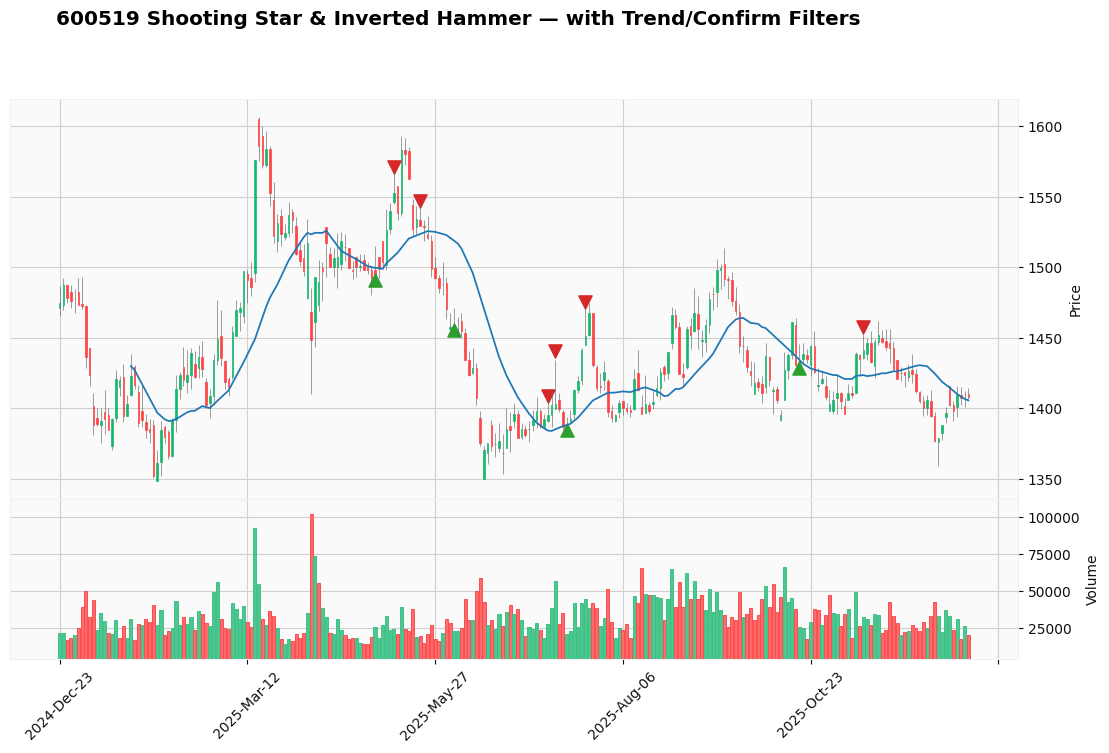

In [23]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 流星 & 倒锤子识别（沿用你原逻辑） =========
ma_len = 20
body_max_pct = 0.30
upper_to_body_min = 2.0
upper_min_pct = 0.50
lower_max_pct = 0.10
use_trend_filter = True
confirm_inverted = True
confirm_shooting = False
confirm_bars = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["US"]    = df["High"] - np.maximum(df["Open"], df["Close"])
df["LS"]    = np.minimum(df["Open"], df["Close"]) - df["Low"]
df["MA"]    = df["Close"].rolling(ma_len).mean()

small_body = df["Body"] <= body_max_pct * df["Range"]
long_upper = (df["US"] >= upper_to_body_min * df["Body"]) & (df["US"] >= upper_min_pct * df["Range"])
tiny_lower = df["LS"] <= lower_max_pct * df["Range"]
shape_ok   = small_body & long_upper & tiny_lower

up_trend   = df["Close"] > df["MA"]
down_trend = df["Close"] < df["MA"]
trend_up_ok   = up_trend if use_trend_filter else pd.Series(True, index=df.index)
trend_down_ok = down_trend if use_trend_filter else pd.Series(True, index=df.index)

# 流星
entity_low = np.minimum(df["Open"], df["Close"])
shooting_basic = shape_ok & trend_up_ok
shooting_confirm_ok = df["Close"].shift(-confirm_bars) < entity_low
df["ShootingStar"] = shooting_basic & (shooting_confirm_ok if confirm_shooting else True)

# 倒锤子
entity_high = np.maximum(df["Open"], df["Close"])
inverted_basic = shape_ok & trend_down_ok
inverted_confirm_ok = df["Close"].shift(-confirm_bars) > entity_high
df["InvertedHammer"] = inverted_basic & (inverted_confirm_ok if confirm_inverted else True)

# ========= 3. 结果检查 =========
n_shoot = df["ShootingStar"].sum()
n_invh = df["InvertedHammer"].sum()
print(f'流星出现次数：{n_shoot}')
print(f'倒锤子出现次数：{n_invh}')
if n_shoot + n_invh == 0:
    print('当前参数下无流星/倒锤子形态，可放宽条件再试')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]
rng = df["Range"].replace(0, 1e-6)
shoot_marks = np.where(df["ShootingStar"], df["High"] + rng * 0.18, np.nan)
invh_marks = np.where(df["InvertedHammer"], df["Low"] - rng * 0.18, np.nan)

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
if not np.all(np.isnan(shoot_marks)):
    ap.append(mpf.make_addplot(shoot_marks, type="scatter", marker="v", markersize=90, color="tab:red"))
if not np.all(np.isnan(invh_marks)):
    ap.append(mpf.make_addplot(invh_marks, type="scatter", marker="^", markersize=90, color="tab:green"))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Shooting Star & Inverted Hammer — with Trend/Confirm Filters',
         style="yahoo", figsize=(14, 8))


# 孕线形态

看涨孕线：2 次
看跌孕线：3 次
十字看涨孕线：1 次
十字看跌孕线：1 次


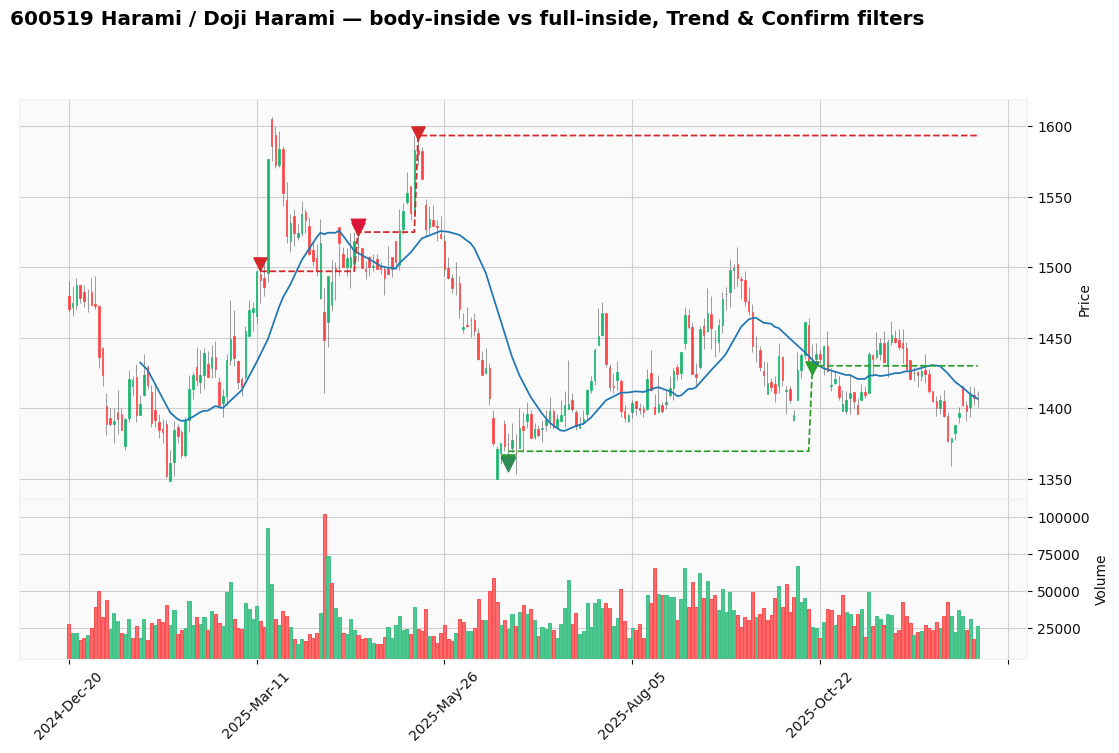

In [25]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 孕线识别（沿用你原逻辑） =========
ma_len = 20
body_max_pct = 0.30
upper_to_body_min = 2.0
upper_min_pct = 0.50
lower_max_pct = 0.10
use_trend_filter = True
confirm_inverted = True
confirm_shooting = False
confirm_bars = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["Bull"]  = (df["Close"] > df["Open"])
df["Bear"]  = (df["Close"] < df["Open"])
df["Doji"]  = (df["Body"] <= df["Range"] * 0.10)
df["MA"]    = df["Close"].rolling(ma_len).mean()

# 移位（母线t-1，子线t）
o1,h1,l1,c1,b1,r1,bull1,bear1,doji1 = [df[c].shift(1) for c in ["Open","High","Low","Close","Body","Range","Bull","Bear","Doji"]]
o2,h2,l2,c2,b2,r2,bull2,bear2,doji2 = [df[c] for c in ["Open","High","Low","Close","Body","Range","Bull","Bear","Doji"]]

m_low, m_high = np.minimum(o1, c1), np.maximum(o1, c1)
c_low, c_high = np.minimum(o2, c2), np.maximum(o2, c2)

mother_long = (b1 >= 0.50 * r1)  # 长母线
child_small = (b2 <= 0.30 * r2) & (b2 <= 0.60 * b1)  # 小实体
inside = (c_low >= m_low) & (c_high <= m_high)  # 实体被包含

downtrend = df["Close"].shift(1) < df["MA"].shift(1) if use_trend_filter else pd.Series(True, index=df.index)
uptrend   = df["Close"].shift(1) > df["MA"].shift(1) if use_trend_filter else pd.Series(True, index=df.index)

bull_harami_basic = mother_long & child_small & inside & downtrend
bear_harami_basic = mother_long & child_small & inside & uptrend

doji_bull_basic = bull_harami_basic & doji2
doji_bear_basic = bear_harami_basic & doji2

entity_high = c_high
entity_low  = c_low
bull_confirm_ok = df["Close"].shift(-1) > entity_high
bear_confirm_ok = df["Close"].shift(-1) < entity_low

df["Bull_Harami"]      = bull_harami_basic & (bull_confirm_ok if True else True)
df["Bear_Harami"]      = bear_harami_basic & (bear_confirm_ok if True else True)
df["Doji_Bull_Harami"] = doji_bull_basic   & (bull_confirm_ok if True else True)
df["Doji_Bear_Harami"] = doji_bear_basic   & (bear_confirm_ok if True else True)

df["Harami_Support"]   = np.where(df["Bull_Harami"] | df["Doji_Bull_Harami"], l1, np.nan)
df["Harami_Resistance"]= np.where(df["Bear_Harami"] | df["Doji_Bear_Harami"], h1, np.nan)
df["Harami_Sup_plot"]  = pd.Series(df["Harami_Support"]).ffill()
df["Harami_Res_plot"]  = pd.Series(df["Harami_Resistance"]).ffill()

# ========= 3. 结果检查 =========
n_bull = df["Bull_Harami"].sum()
n_bear = df["Bear_Harami"].sum()
n_dbull= df["Doji_Bull_Harami"].sum()
n_dbear= df["Doji_Bear_Harami"].sum()
print(f'看涨孕线：{n_bull} 次')
print(f'看跌孕线：{n_bear} 次')
print(f'十字看涨孕线：{n_dbull} 次')
print(f'十字看跌孕线：{n_dbear} 次')
if n_bull + n_bear + n_dbull + n_dbear == 0:
    print('当前参数下无孕线形态，可放宽条件再试')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]
rng = df["Range"].replace(0, 1e-6)

bull_marks  = np.where(df["Bull_Harami"],      df["Low"]  - rng * 0.18, np.nan)
dbull_marks = np.where(df["Doji_Bull_Harami"], df["Low"]  - rng * 0.30, np.nan)
bear_marks  = np.where(df["Bear_Harami"],      df["High"] + rng * 0.18, np.nan)
dbear_marks = np.where(df["Doji_Bear_Harami"], df["High"] + rng * 0.30, np.nan)

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
for marks, color, size in [(bull_marks, 'tab:green', 90), (dbull_marks, 'seagreen', 110),
                           (bear_marks, 'tab:red', 90), (dbear_marks, 'crimson', 110)]:
    if not np.all(np.isnan(marks)):
        ap.append(mpf.make_addplot(marks, type="scatter", marker="^" if 'bull' in color else "v",
                                   markersize=size, color=color))

# 支撑/阻力阶梯线
for col, color in [('Harami_Sup_plot', 'tab:green'), ('Harami_Res_plot', 'tab:red')]:
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(mpf.make_addplot(plot_col, color=color, linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Harami / Doji Harami — body-inside vs full-inside, Trend & Confirm filters',
         style="yahoo", figsize=(14, 8))


# 平头顶部形态和平头底部形态

平头顶部：3 次
平头底部：4 次


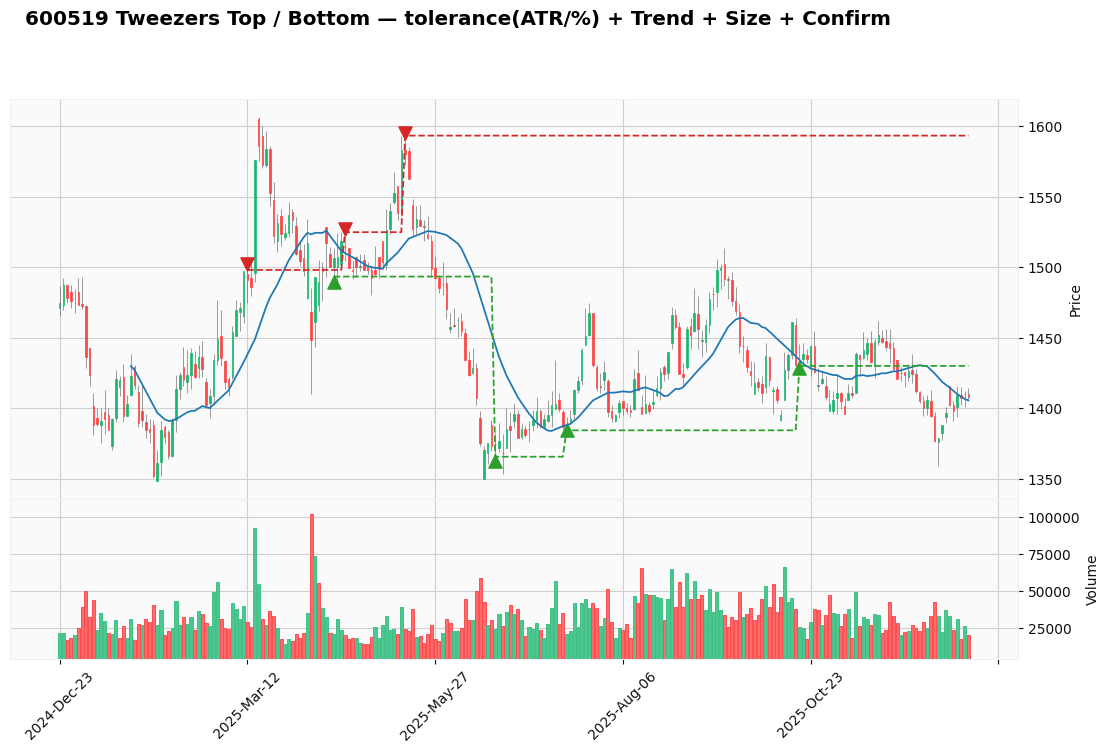

In [24]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 平头顶/底识别（沿用你原逻辑） =========
ma_len = 20
use_trend_filter = True
tol_pct = 0.0015
use_atr_tolerance = True
atr_len = 14
atr_mult = 0.2
require_long1 = True
long_body_pct = 0.50
require_small2 = True
small_body_pct = 0.30
confirm_top = True
confirm_bottom = True
confirm_shift = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["MA"]    = df["Close"].rolling(ma_len).mean()

# ATR
tr = np.maximum.reduce([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift(1)).abs(),
    (df["Low"]  - df["Close"].shift(1)).abs()
])
df["ATR"] = pd.Series(tr, index=df.index).ewm(alpha=1/atr_len, adjust=False).mean()

# 位移
o1,h1,l1,c1,b1,r1 = [df[c].shift(1) for c in ["Open","High","Low","Close","Body","Range"]]
o2,h2,l2,c2,b2,r2 = [df[c] for c in ["Open","High","Low","Close","Body","Range"]]

e1_low, e1_high = np.minimum(o1, c1), np.maximum(o1, c1)
e2_low, e2_high = np.minimum(o2, c2), np.maximum(o2, c2)

up_trend   = df["Close"].shift(1) > df["MA"].shift(1)
down_trend = df["Close"].shift(1) < df["MA"].shift(1)
trend_up_ok   = up_trend if use_trend_filter else pd.Series(True, index=df.index)
trend_down_ok = down_trend if use_trend_filter else pd.Series(True, index=df.index)

long1  = (b1 >= 0.5 * r1) if require_long1  else pd.Series(True, index=df.index)
small2 = (b2 <= 0.3 * r2) if require_small2 else pd.Series(True, index=df.index)

tol_top  = df["ATR"] * atr_mult if use_atr_tolerance else h2 * tol_pct
tol_bot  = df["ATR"] * atr_mult if use_atr_tolerance else l2 * tol_pct

same_high = (h2 - h1).abs() <= tol_top
same_low  = (l2 - l1).abs() <= tol_bot

tweezer_top_basic = same_high & trend_up_ok & long1 & small2
top_confirm_ok = df["Close"].shift(-1) < e2_low
df["Tweezers_Top"] = tweezer_top_basic & (top_confirm_ok if confirm_top else True)

tweezer_bot_basic = same_low & trend_down_ok & long1 & small2
bot_confirm_ok = df["Close"].shift(-1) > e2_high
df["Tweezers_Bottom"] = tweezer_bot_basic & (bot_confirm_ok if confirm_bottom else True)

df["TZ_Res"] = np.where(df["Tweezers_Top"], np.maximum(h1, h2), np.nan)
df["TZ_Sup"] = np.where(df["Tweezers_Bottom"], np.minimum(l1, l2), np.nan)
df["TZ_Res_plot"] = pd.Series(df["TZ_Res"]).ffill()
df["TZ_Sup_plot"] = pd.Series(df["TZ_Sup"]).ffill()

# ========= 3. 结果检查 =========
n_top = df["Tweezers_Top"].sum()
n_bot = df["Tweezers_Bottom"].sum()
print(f'平头顶部：{n_top} 次')
print(f'平头底部：{n_bot} 次')
if n_top + n_bot == 0:
    print('当前参数下无平头形态，可放宽条件再试')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]
rng = df["Range"].replace(0, 1e-6)
tt_marks = np.where(df["Tweezers_Top"], df["High"] + rng * 0.18, np.nan)
tb_marks = np.where(df["Tweezers_Bottom"], df["Low"] - rng * 0.18, np.nan)

if not np.all(np.isnan(tt_marks)):
    ap.append(mpf.make_addplot(tt_marks, type="scatter", marker="v", markersize=90, color="tab:red"))
if not np.all(np.isnan(tb_marks)):
    ap.append(mpf.make_addplot(tb_marks, type="scatter", marker="^", markersize=90, color="tab:green"))

for col, color in [('TZ_Res_plot', 'tab:red'), ('TZ_Sup_plot', 'tab:green')]:
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(mpf.make_addplot(plot_col, color=color, linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Tweezers Top / Bottom — tolerance(ATR/%) + Trend + Size + Confirm',
         style="yahoo", figsize=(14, 8))

# 捉腰带线

看涨捉腰带线：5 次
看跌捉腰带线：4 次


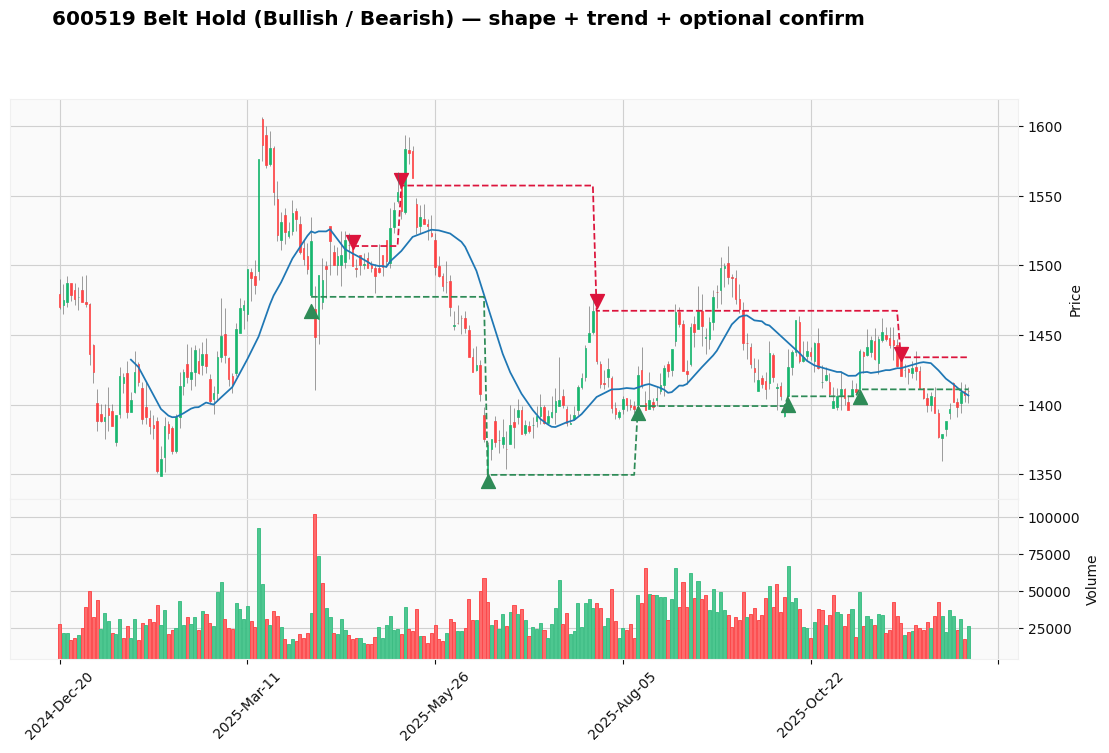

In [27]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 捉腰带线识别（沿用你原逻辑） =========
ma_len = 20
use_trend_filter = True
body_min_pct = 0.60
lower_shadow_max = 0.03
upper_shadow_max = 0.03
confirm_bull = False
confirm_bear = False
confirm_shift = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["MA"]    = df["Close"].rolling(ma_len).mean()

upper_shadow = df["High"] - np.maximum(df["Open"], df["Close"])
lower_shadow = np.minimum(df["Open"], df["Close"]) - df["Low"]

# 看涨捉腰带线
bullish_long_body = (df["Close"] > df["Open"]) & (df["Body"] >= body_min_pct * df["Range"])
bullish_small_lower = (lower_shadow <= lower_shadow_max * df["Range"])
bull_basic = bullish_long_body & bullish_small_lower

trend_down = df["Close"].shift(1) < df["MA"].shift(1) if use_trend_filter else pd.Series(True, index=df.index)
bull_confirm_ok = df["Close"].shift(-confirm_shift) > df["Close"]
df["Bull_BeltHold"] = bull_basic & trend_down & (bull_confirm_ok if confirm_bull else True)
df["BH_Support"] = np.where(df["Bull_BeltHold"], df["Low"], np.nan)

# 看跌捉腰带线
bearish_long_body = (df["Close"] < df["Open"]) & (df["Body"] >= body_min_pct * df["Range"])
bearish_small_upper = (upper_shadow <= upper_shadow_max * df["Range"])
bear_basic = bearish_long_body & bearish_small_upper

trend_up = df["Close"].shift(1) > df["MA"].shift(1) if use_trend_filter else pd.Series(True, index=df.index)
bear_confirm_ok = df["Close"].shift(-confirm_shift) < df["Close"]
df["Bear_BeltHold"] = bear_basic & trend_up & (bear_confirm_ok if confirm_bear else True)
df["BH_Resistance"] = np.where(df["Bear_BeltHold"], df["High"], np.nan)

# ========= 3. 结果检查 =========
n_bull = df["Bull_BeltHold"].sum()
n_bear = df["Bear_BeltHold"].sum()
print(f'看涨捉腰带线：{n_bull} 次')
print(f'看跌捉腰带线：{n_bear} 次')
if n_bull + n_bear == 0:
    print('当前参数下无捉腰带线形态，可放宽条件再试')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]
rng = df["Range"].replace(0, 1e-6)
bull_marks = np.where(df["Bull_BeltHold"], df["Low"] - rng * 0.18, np.nan)
bear_marks = np.where(df["Bear_BeltHold"], df["High"] + rng * 0.18, np.nan)

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
for marks, color, marker in [(bull_marks, 'seagreen', '^'), (bear_marks, 'crimson', 'v')]:
    if not np.all(np.isnan(marks)):
        ap.append(mpf.make_addplot(marks, type="scatter", marker=marker, markersize=100, color=color))

# 支撑/阻力阶梯线
for col, color in [('BH_Support', 'seagreen'), ('BH_Resistance', 'crimson')]:
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(mpf.make_addplot(plot_col, color=color, linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Belt Hold (Bullish / Bearish) — shape + trend + optional confirm',
         style="yahoo", figsize=(14, 8))


# 向上跳空两只乌鸦

向上跳空两只乌鸦：0 次
当前参数下无该形态，可放宽条件再试


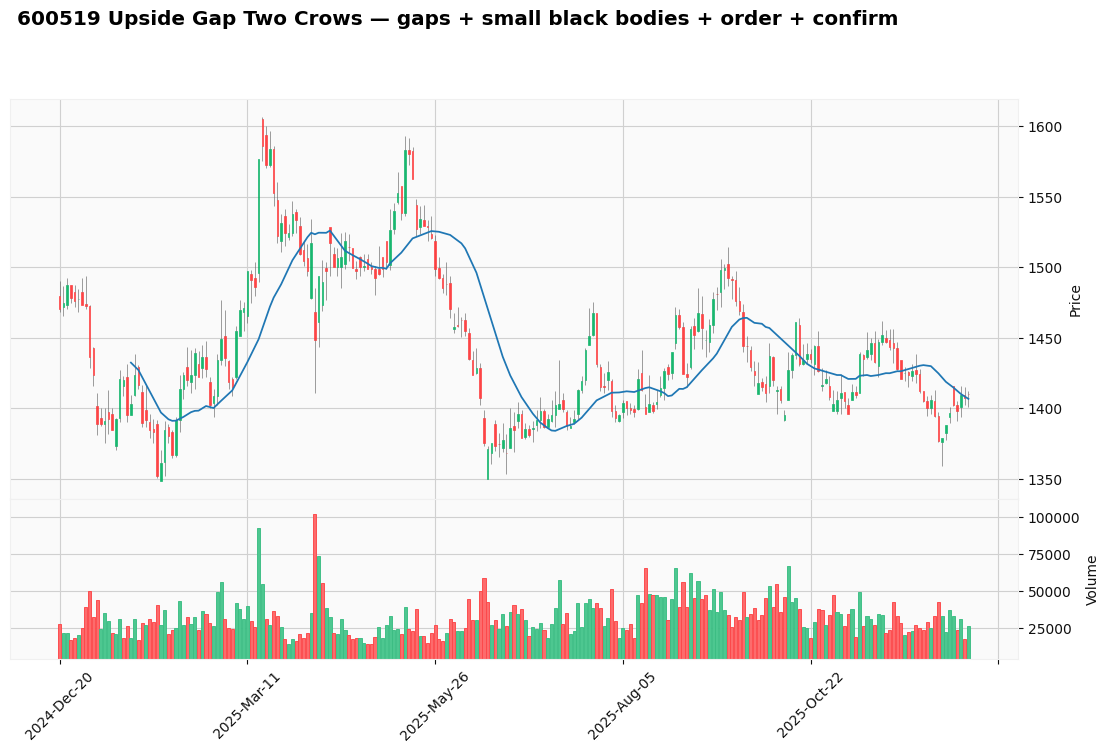

In [28]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 向上跳空两只乌鸦识别（沿用你原逻辑） =========
ma_len = 20
use_trend_filter = True
long_body_pct1 = 0.50
small_body_pct23 = 0.35
gap_tolerance_pct = 0.00
gap_vs_high_not_close = False
require_o3_gt_o2_open = True
require_c3_lt_c2_close = True
require_closes_above_bar1 = True
use_day4_confirmation = False
confirm_shift = 1

df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["MA"]    = df["Close"].rolling(ma_len).mean()

def sh(c, k): return df[c].shift(k)
o1,h1,l1,c1,b1,r1 = sh("Open",2), sh("High",2), sh("Low",2), sh("Close",2), sh("Body",2), sh("Range",2)
o2,h2,l2,c2,b2,r2 = sh("Open",1), sh("High",1), sh("Low",1), sh("Close",1), sh("Body",1), sh("Range",1)
o3,h3,l3,c3,b3,r3 = df["Open"], df["High"], df["Low"], df["Close"], df["Body"], df["Range"]

uptrend_before = df["Close"].shift(3) > df["MA"].shift(3) if use_trend_filter else pd.Series(True, index=df.index)

long_white1 = (c1 > o1) & (b1 >= long_body_pct1 * r1)
small_black2 = (c2 < o2) & (b2 <= small_body_pct23 * r2)
small_black3 = (c3 < o3) & (b3 <= small_body_pct23 * r3)

if gap_vs_high_not_close:
    gap_up_bar2 = l2 > h1 * (1 + gap_tolerance_pct)
    gap_up_bar3_open = o3 > h1 * (1 + gap_tolerance_pct)
else:
    gap_up_bar2 = l2 > c1 * (1 + gap_tolerance_pct)
    gap_up_bar3_open = o3 > c1 * (1 + gap_tolerance_pct)

o3_gt_o2 = (o3 > o2 * (1 + gap_tolerance_pct)) if require_o3_gt_o2_open else True
c3_lt_c2 = (c3 < c2 * (1 - gap_tolerance_pct)) if require_c3_lt_c2_close else True
closes_above_bar1 = ((c2 > c1) & (c3 > c1)) if require_closes_above_bar1 else True
day4_confirm = (df["Close"].shift(-confirm_shift) < c3) if use_day4_confirmation else True

ugt2c = (
    uptrend_before &
    long_white1 &
    small_black2 & small_black3 &
    gap_up_bar2 & gap_up_bar3_open &
    o3_gt_o2 & c3_lt_c2 &
    closes_above_bar1 &
    day4_confirm
)

df["UpsideGapTwoCrows"] = ugt2c
df["UG2C_Res"] = np.where(df["UpsideGapTwoCrows"], np.maximum.reduce([h1, h2, h3]), np.nan)
df["UG2C_Res_plot"] = pd.Series(df["UG2C_Res"]).ffill()

# ========= 3. 结果检查 =========
n_sig = df["UpsideGapTwoCrows"].sum()
print(f'向上跳空两只乌鸦：{n_sig} 次')
if n_sig == 0:
    print('当前参数下无该形态，可放宽条件再试')

# ========= 4. 可视化 =========
ap = [mpf.make_addplot(df["MA"], color='tab:blue')]
rng = df["Range"].replace(0, 1e-6)
marks = np.where(df["UpsideGapTwoCrows"], df["High"] + rng * 0.22, np.nan)

if not np.all(np.isnan(marks)):
    ap.append(mpf.make_addplot(marks, type="scatter", marker="v", markersize=120, color="crimson"))

plot_col = pd.Series(df["UG2C_Res_plot"]).ffill()
if not plot_col.isna().all():
    ap.append(mpf.make_addplot(plot_col, color="crimson", linestyle='--'))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Upside Gap Two Crows — gaps + small black bodies + order + confirm',
         style="yahoo", figsize=(14, 8))

# 三只乌鸦

三只乌鸦：1 次


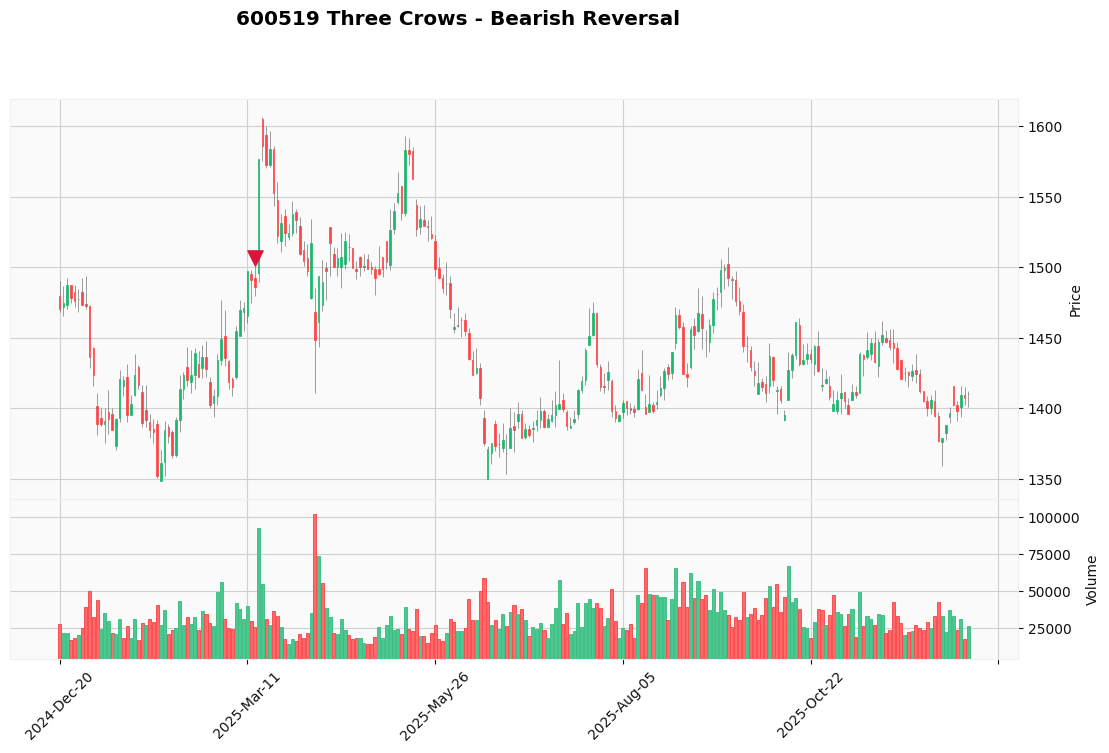

In [29]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 三只乌鸦识别（沿用你原逻辑） =========
gap_tolerance_pct = 0.01
small_black_body_pct = 0.35
long_white_body_pct = 0.50

df['Range'] = df['High'] - df['Low']
df['Body'] = (df['Close'] - df['Open']).abs()

condition1 = (df['Body'].shift(2) >= long_white_body_pct * df['Range'].shift(2)) & (df['Close'].shift(2) > df['Open'].shift(2))
condition2 = (df['Body'].shift(1) <= small_black_body_pct * df['Range'].shift(1)) & (df['Close'].shift(1) < df['Open'].shift(1))
condition3 = (df['Body'] <= small_black_body_pct * df['Range']) & (df['Close'] < df['Open'])

df['ThreeCrows'] = condition1 & condition2 & condition3

# ========= 3. 结果检查 =========
n_sig = df['ThreeCrows'].sum()
print(f'三只乌鸦：{n_sig} 次')
if n_sig == 0:
    print('当前参数下无三只乌鸦形态，可放宽条件再试')

# ========= 4. 可视化 =========
marks = np.where(df['ThreeCrows'], df['High'] + df['Range'] * 0.1, np.nan)

ap = []
if not np.all(np.isnan(marks)):
    ap.append(mpf.make_addplot(marks, type="scatter", marker="v", markersize=120, color="crimson"))

mpf.plot(df, type="candle", volume=True, addplot=ap,
         title=f'{symbol_code} Three Crows - Bearish Reversal',
         style="yahoo", figsize=(14, 8))

# 白色三兵挺进形态

白三兵：20 次
前方受阻：0 次


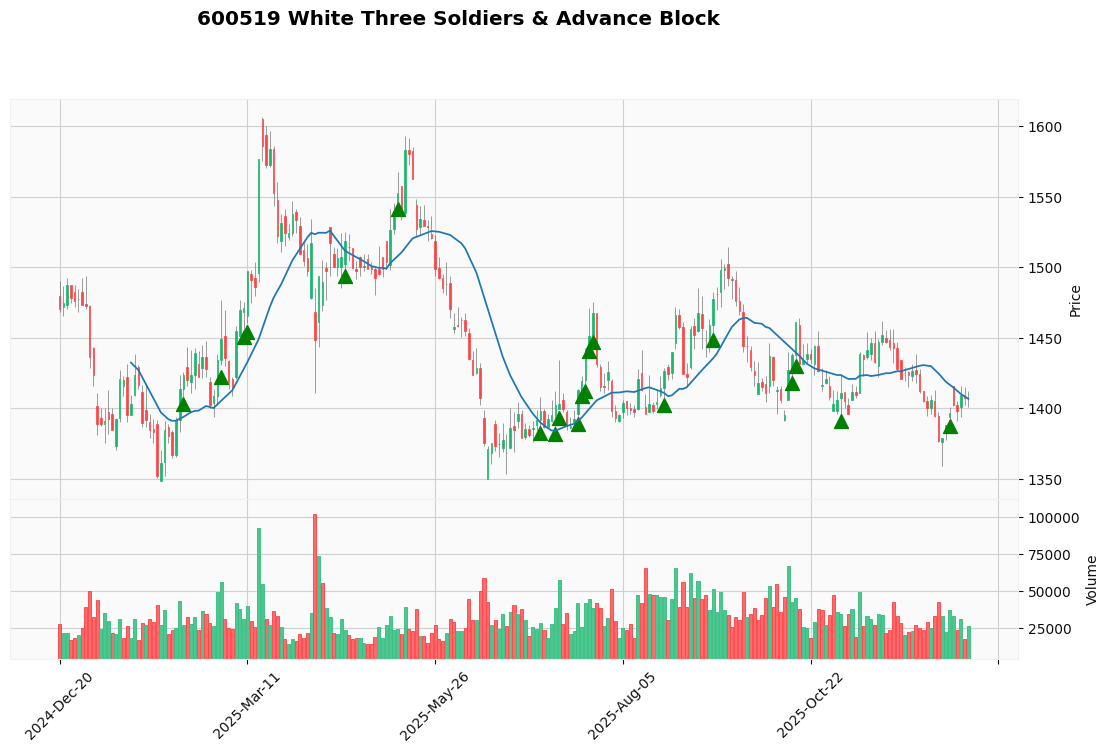

In [30]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),

                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 形态识别（沿用你原逻辑，但返回布尔 Series） =========
ma_len = 20
use_trend_filter = True
body_min_pct = 0.60
lower_shadow_max = 0.03
upper_shadow_max = 0.03
confirm_bull = False
confirm_bear = False
confirm_shift = 1

df['Range'] = df['High'] - df['Low']          # ← 加这一行
df['Body']  = (df['Close'] - df['Open']).abs()
df['MA']    = df['Close'].rolling(ma_len).mean()


# ========= 2. 形态识别（沿用你原逻辑，但返回布尔 Series） =========
def detect_white_three_soldiers(data: pd.DataFrame) -> pd.Series:
    cond = (
        (data['Close'] > data['Open']) &  # 当前白K
        (data['Close'].shift(1) > data['Open'].shift(1)) &  # 前1白K
        (data['Close'].shift(2) > data['Open'].shift(2)) &  # 前2白K
        (data['Close'] > data['Close'].shift(1)) &  # 逐级走高
        (data['Close'].shift(1) > data['Close'].shift(2))
    )
    return cond

def detect_resistance(data: pd.DataFrame) -> pd.Series:
    # 白三兵 + 当前K收盘 < 前根收盘（受阻） + 长上影
    cond = (
        (data['Close'] > data['Open']) &  # 当前白K
        (data['Close'].shift(1) > data['Open'].shift(1)) &  # 前1白K
        (data['Close'].shift(2) > data['Open'].shift(2)) &  # 前2白K
        (data['Close'] < data['Close'].shift(1)) &  # 当前收盘低于前根
        ((data['High'] - data['Close']) > (data['Close'] - data['Open']))  # 长上影
    )
    return cond

# 计算信号
df['White_Three_Soldiers'] = detect_white_three_soldiers(df)
df['Resistance_Signal'] = detect_resistance(df)

# ========= 3. 结果检查 =========
n_wts = df['White_Three_Soldiers'].sum()
n_res = df['Resistance_Signal'].sum()
print(f'白三兵：{n_wts} 次')
print(f'前方受阻：{n_res} 次')
if n_wts + n_res == 0:
    print('当前参数下无形态，可放宽条件再试')

# ========= 4. 可视化 =========
# 标记位置：白三兵在低点↑，受阻在高点↓
rng = df['Range'].replace(0, 1e-6)
wts_marks = np.where(df['White_Three_Soldiers'], df['Low'] - rng * 0.18, np.nan)
res_marks = np.where(df['Resistance_Signal'], df['High'] + rng * 0.18, np.nan)

ap = [mpf.make_addplot(df['MA'], color='tab:blue')]

# 只把「至少有一个有效值」的图层加进去，避免全 nan 报错
if not np.all(np.isnan(wts_marks)):
    ap.append(mpf.make_addplot(wts_marks, type='scatter', marker='^', markersize=100, color='green'))
if not np.all(np.isnan(res_marks)):
    ap.append(mpf.make_addplot(res_marks, type='scatter', marker='v', markersize=100, color='red'))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} White Three Soldiers & Advance Block',
         style='yahoo', figsize=(14, 8))

# 三山形态和三川形态

In [14]:
import matplotlib.pyplot as plt

三山顶：63 次
三尊顶：63 次
倒三尊底：55 次


C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 39030 (\N{CJK UNIFIED IDEOGRAPH-9876}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 23562 (\N{CJK UNIFIED IDEOGRAPH-5C0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 20498 (\N{CJK UNIFIED IDEOGRAPH-5012}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\3908421761.py:101: UserWarning: Glyph 24213 (\

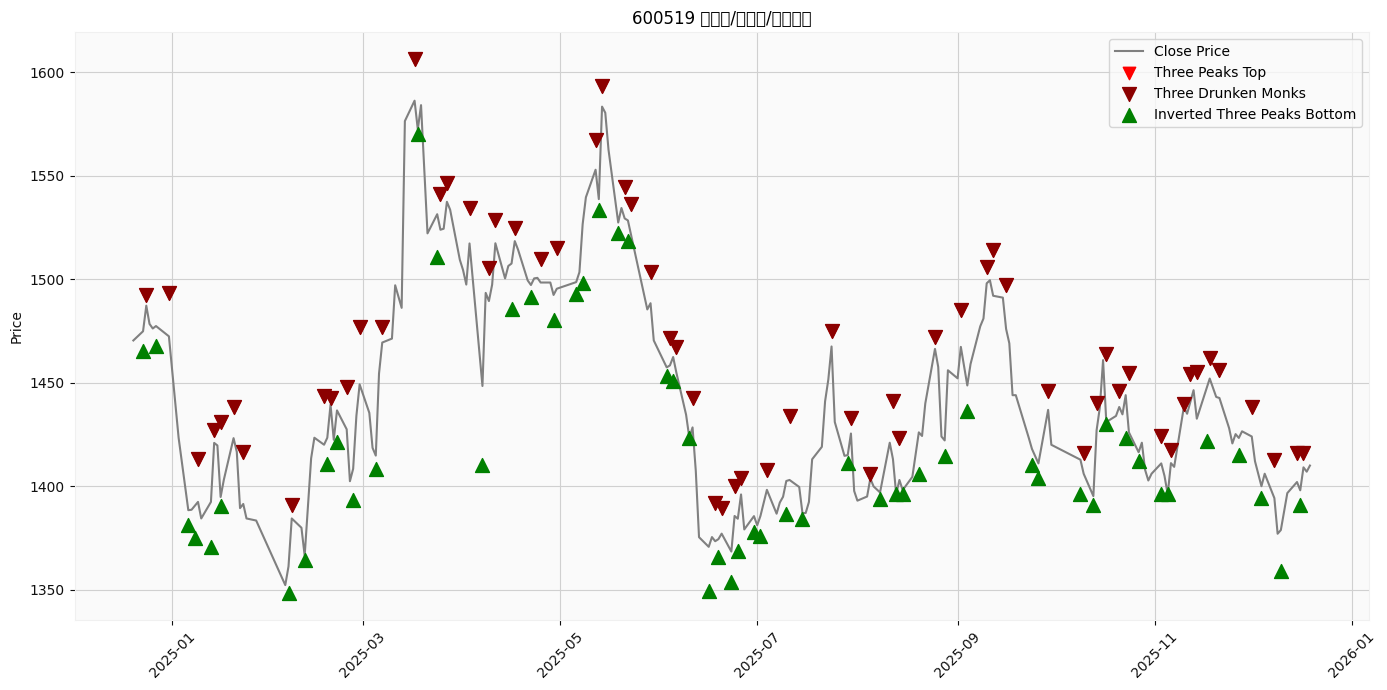

E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39030 (\N{CJK UNIFIED IDEOGRAPH-9876}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23562 (\N{CJK UNIFIED IDEOGRAPH-5C0A}) missing from fon

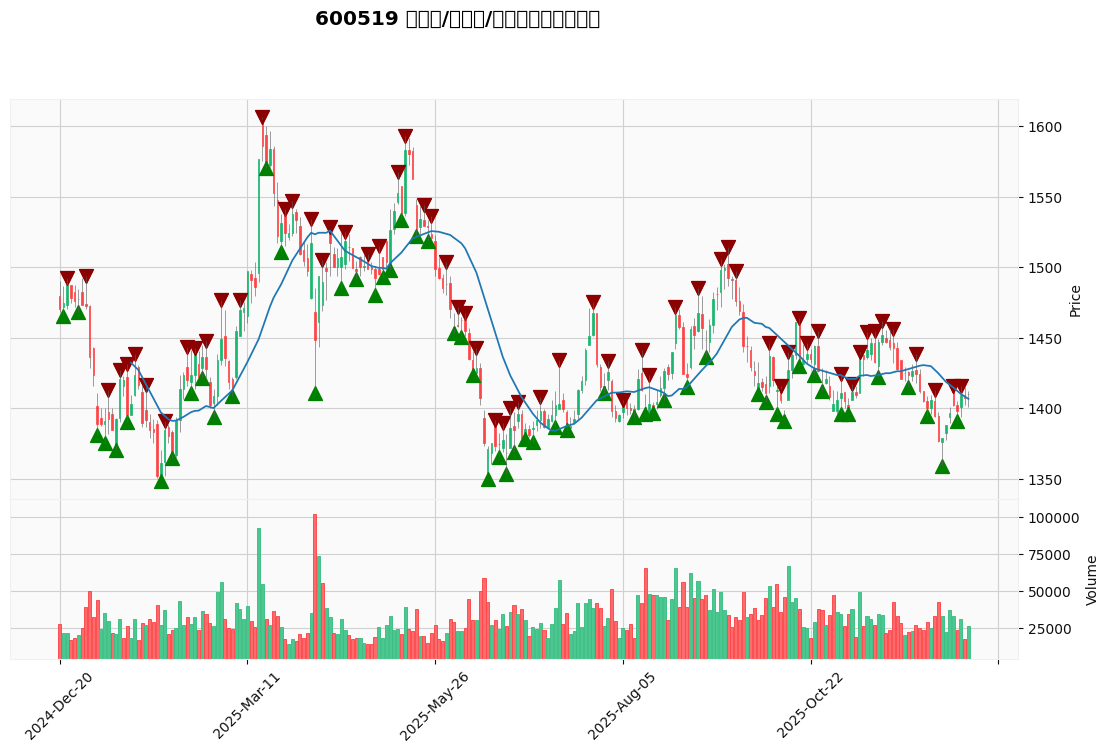

In [32]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 形态识别（沿用你原逻辑，但返回布尔 Series） =========
ma_len = 20
use_trend_filter = True
body_min_pct = 0.60
lower_shadow_max = 0.03
upper_shadow_max = 0.03
confirm_bull = False
confirm_bear = False
confirm_shift = 1

df['Range'] = df['High'] - df['Low']   # ← 已有
df['Body']  = (df['Close'] - df['Open']).abs()
df['MA']    = df['Close'].rolling(ma_len).mean()   # ← 加这一行


# ========= 2. 形态识别（返回日期+价格列表） =========
def three_peaks_top(data: pd.DataFrame) -> list:
    """简单三山顶：连续三K，中间高峰最高"""
    peaks = []
    for i in range(1, len(data)-1):
        if (data['High'].iloc[i] > data['High'].iloc[i-1] and
            data['High'].iloc[i] > data['High'].iloc[i+1]):
            peaks.append((data.index[i], data['High'].iloc[i]))
    return peaks

def three_drunk_monk_top(data: pd.DataFrame) -> list:
    """三尊顶：中间高峰+右侧次高，可视为三山顶的严格版"""
    peaks = []
    for i in range(1, len(data)-1):
        if (data['High'].iloc[i] > data['High'].iloc[i-1] and
            data['High'].iloc[i] > data['High'].iloc[i+1] and
            data['High'].iloc[i+1] < data['High'].iloc[i]):   # 右侧回落
            peaks.append((data.index[i], data['High'].iloc[i]))
    return peaks

def inverted_three_peaks_bottom(data: pd.DataFrame) -> list:
    """倒三尊底：连续三K，中间低谷最低"""
    bottoms = []
    for i in range(1, len(data)-1):
        if (data['Low'].iloc[i] < data['Low'].iloc[i-1] and
            data['Low'].iloc[i] < data['Low'].iloc[i+1]):
            bottoms.append((data.index[i], data['Low'].iloc[i]))
    return bottoms

# ========= 3. 结果检查 =========
peaks = three_peaks_top(df)
monks = three_drunk_monk_top(df)
bottoms = inverted_three_peaks_bottom(df)

n_peaks = len(peaks)
n_monks = len(monks)
n_bottoms = len(bottoms)
print(f'三山顶：{n_peaks} 次')
print(f'三尊顶：{n_monks} 次')
print(f'倒三尊底：{n_bottoms} 次')
if n_peaks + n_monks + n_bottoms == 0:
    print('当前参数下无形态，可放宽条件再试')

# ========= 4. 可视化（matplotlib 折线版） =========
def plot_peaks_mpl(df, peaks=None, monks=None, bottoms=None):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df.index, df['Close'], label='Close Price', color='grey')

    if peaks:
        pdates, pvals = zip(*peaks)
        ax.scatter(pdates, pvals, color='red', label='Three Peaks Top', zorder=5, s=80, marker='v')
    if monks:
        pdates, pvals = zip(*monks)
        ax.scatter(pdates, pvals, color='darkred', label='Three Drunken Monks', zorder=5, s=100, marker='v')
    if bottoms:
        pdates, pvals = zip(*bottoms)
        ax.scatter(pdates, pvals, color='green', label='Inverted Three Peaks Bottom', zorder=5, s=100, marker='^')

    ax.set_title(f'{symbol_code} 三山顶/三尊顶/倒三尊底')
    ax.set_ylabel('Price')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 一键画图（折线）
plot_peaks_mpl(df, peaks=peaks, monks=monks, bottoms=bottoms)

# ========= 5. 可选：mplfinance 蜡烛图版本 =========
# 生成标记列（Bool → 价格）
df['PeakMark']  = np.nan
df['MonkMark']  = np.nan
df['BottomMark']= np.nan
for date, val in peaks:
    df.loc[date, 'PeakMark']  = val
for date, val in monks:
    df.loc[date, 'MonkMark']  = val
for date, val in bottoms:
    df.loc[date, 'BottomMark']= val

ap = [mpf.make_addplot(df['MA'], color='tab:blue')]
if not df['PeakMark'].isna().all():
    ap.append(mpf.make_addplot(df['PeakMark'], type='scatter', marker='v', markersize=80, color='red'))
if not df['MonkMark'].isna().all():
    ap.append(mpf.make_addplot(df['MonkMark'], type='scatter', marker='v', markersize=100, color='darkred'))
if not df['BottomMark'].isna().all():
    ap.append(mpf.make_addplot(df['BottomMark'], type='scatter', marker='^', markersize=100, color='green'))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} 三山顶/三尊顶/倒三尊底（蜡烛图）',
         style='yahoo', figsize=(14, 8))

# 反击线形态（约会线形态）

反击线共 32 次


C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:69: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:69: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:69: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:69: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:69: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-pack

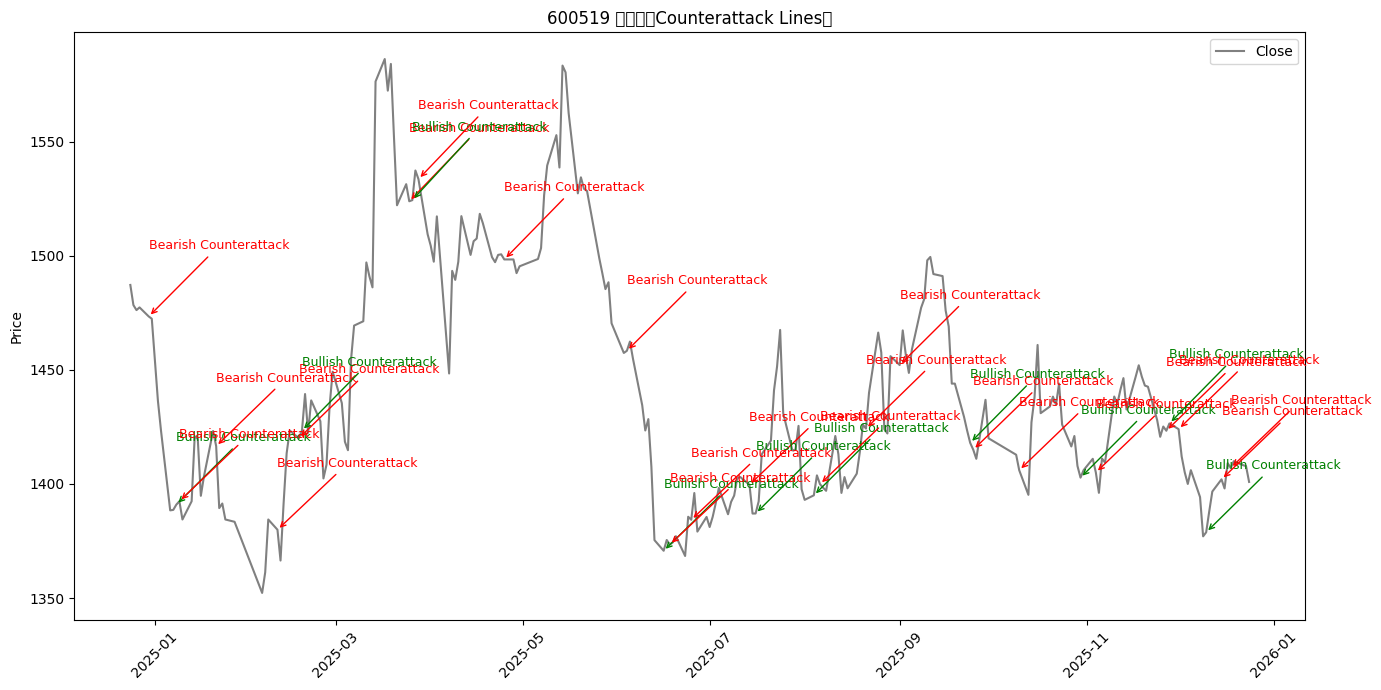

C:\Users\Lyj15\AppData\Local\Temp\ipykernel_19452\2571313196.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'red' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[date, 'SignalColor'] = 'green' if 'Bullish' in name else 'red'


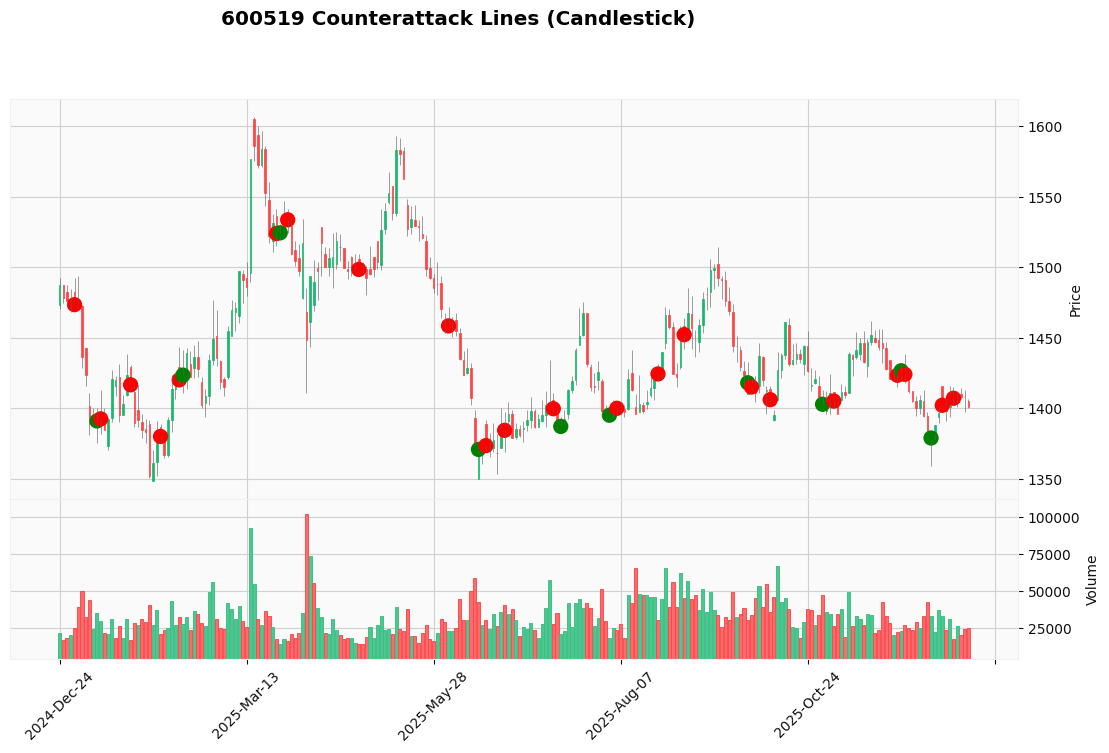

In [15]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 反击线识别（返回列表） =========
def check_reversal_line(data: pd.DataFrame, tol_pct: float = 0.005) -> list:
    """
    tol_pct: 收盘价相等的容差（百分比）
    """
    signals = []
    for i in range(1, len(data)):
        prev, curr = data.iloc[i-1], data.iloc[i]
        # 看涨反击线：前黑 + 本白，且两收盘几乎相等
        if (curr['Close'] > curr['Open'] and
            prev['Close'] < prev['Open'] and
            abs(curr['Close'] - prev['Close']) / prev['Close'] <= tol_pct and
            curr['Open'] < prev['Close']):
            signals.append(('Bullish Counterattack', data.index[i], curr['Close']))

        # 看跌反击线：前白 + 本黑，且两收盘几乎相等
        if (curr['Close'] < curr['Open'] and
            prev['Close'] > prev['Open'] and
            abs(curr['Close'] - prev['Close']) / prev['Close'] <= tol_pct and
            curr['Open'] > prev['Close']):
            signals.append(('Bearish Counterattack', data.index[i], curr['Close']))
    return signals

signals = check_reversal_line(df)

# ========= 3. 结果检查 =========
n_sig = len(signals)
print(f'反击线共 {n_sig} 次')
if n_sig == 0:
    print('当前参数下无反击线形态，可放宽 tol_pct 再试')

# ========= 4. 可视化（matplotlib 折线版） =========
def plot_reversal_mpl(data, signals):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(data.index, data['Close'], label='Close', color='grey')

    for name, date, price in signals:
        color = 'green' if 'Bullish' in name else 'red'
        ax.annotate(name, xy=(date, price), xytext=(date, price * 1.02),
                    arrowprops=dict(arrowstyle='->', color=color),
                    fontsize=9, color=color)
    ax.set_title(f'{symbol_code} 反击线（Counterattack Lines）')
    ax.set_ylabel('Price')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_reversal_mpl(df, signals)

# ========= 5. 可选：mplfinance 蜡烛图版本 =========
# 生成标记列（与 df 等长）
df['SignalMark'] = np.nan
df['SignalColor'] = np.nan
for name, date, price in signals:
    df.loc[date, 'SignalMark'] = price
    df.loc[date, 'SignalColor'] = 'green' if 'Bullish' in name else 'red'

# 把 NaN 换成透明色，mplfinance 才能识别
df['SignalColor'] = df['SignalColor'].fillna('none')

ap = []
if not df['SignalMark'].isna().all():
    ap.append(mpf.make_addplot(df['SignalMark'], type='scatter', marker='o',
                               markersize=100, color=df['SignalColor'].tolist()))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} Counterattack Lines (Candlestick)',
         style='yahoo', figsize=(14, 8))

# 圆形顶部形态和平底锅底部形态（圆形底部形态）

平底锅/圆形顶共 0 次
当前参数下无形态，可调宽 w 或放宽坡度阈值再试


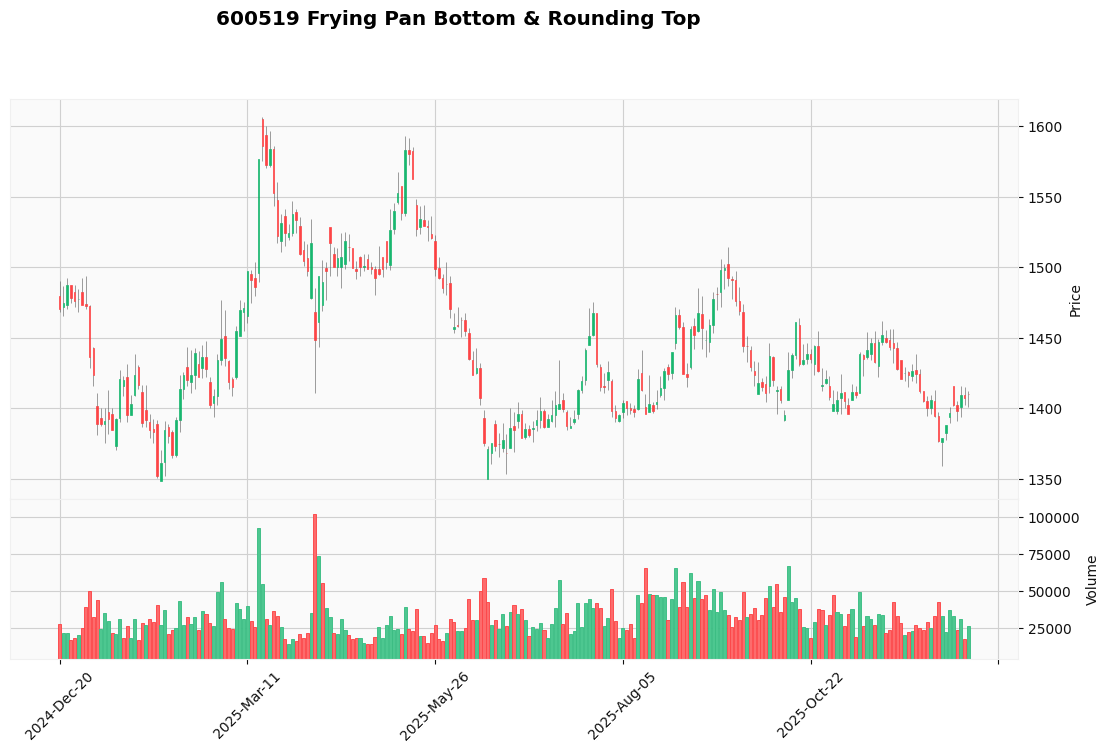

In [34]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 形态识别（平底锅底部 & 圆形顶部） =========
def frying_pan_bottom(data: pd.DataFrame, w: int = 10) -> list:
    """
    简化版平底锅底：连续 w 根 K 线，收盘呈“圆弧”上升，且最低价逐步抬高
    """
    signals = []
    for i in range(w, len(data)):
        seg = data.iloc[i - w:i]
        # 1. 收盘近似圆弧上升（线性回归斜率 > 0）
        slope = np.polyfit(range(w), seg['Close'], 1)[0]
        # 2. 最低价逐步抬高（单调增）
        lows_inc = all(seg['Low'].iloc[j] < seg['Low'].iloc[j + 1] for j in range(w - 1))
        if slope > 0 and lows_inc:
            signals.append(('Frying Pan Bottom', data.index[i], data['Close'].iloc[i]))
    return signals

def rounding_top(data: pd.DataFrame, w: int = 10) -> list:
    """
    简化版圆形顶部：连续 w 根 K 线，收盘呈“圆弧”下降，且最高价逐步降低
    """
    signals = []
    for i in range(w, len(data)):
        seg = data.iloc[i - w:i]
        # 1. 收盘近似圆弧下降（斜率 < 0）
        slope = np.polyfit(range(w), seg['Close'], 1)[0]
        # 2. 最高价逐步降低（单调降）
        highs_dec = all(seg['High'].iloc[j] > seg['High'].iloc[j + 1] for j in range(w - 1))
        if slope < 0 and highs_dec:
            signals.append(('Rounding Top', data.index[i], data['Close'].iloc[i]))
    return signals

signals = frying_pan_bottom(df) + rounding_top(df)

# ========= 3. 结果检查 =========
n_sig = len(signals)
print(f'平底锅/圆形顶共 {n_sig} 次')
if n_sig == 0:
    print('当前参数下无形态，可调宽 w 或放宽坡度阈值再试')

# ========= 4. 可视化 =========
# 生成与 df 等长的标记 & 颜色列
df['PatternMark'] = np.nan
df['PatternColor'] = np.nan
for name, date, price in signals:
    df.loc[date, 'PatternMark'] = price
    df.loc[date, 'PatternColor'] = 'green' if 'Bottom' in name else 'red'

# NaN → 透明
df['PatternColor'] = df['PatternColor'].fillna('none')

ap = []
if not df['PatternMark'].isna().all():
    ap.append(mpf.make_addplot(df['PatternMark'], type='scatter', marker='o',
                               markersize=100, color=df['PatternColor'].tolist()))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} Frying Pan Bottom & Rounding Top',
         style='yahoo', figsize=(14, 8))


# 塔形顶部形态和塔形底部形态

塔形顶/底共 0 次
当前参数下无塔形形态，可调宽 w 或放宽 body_pct 再试


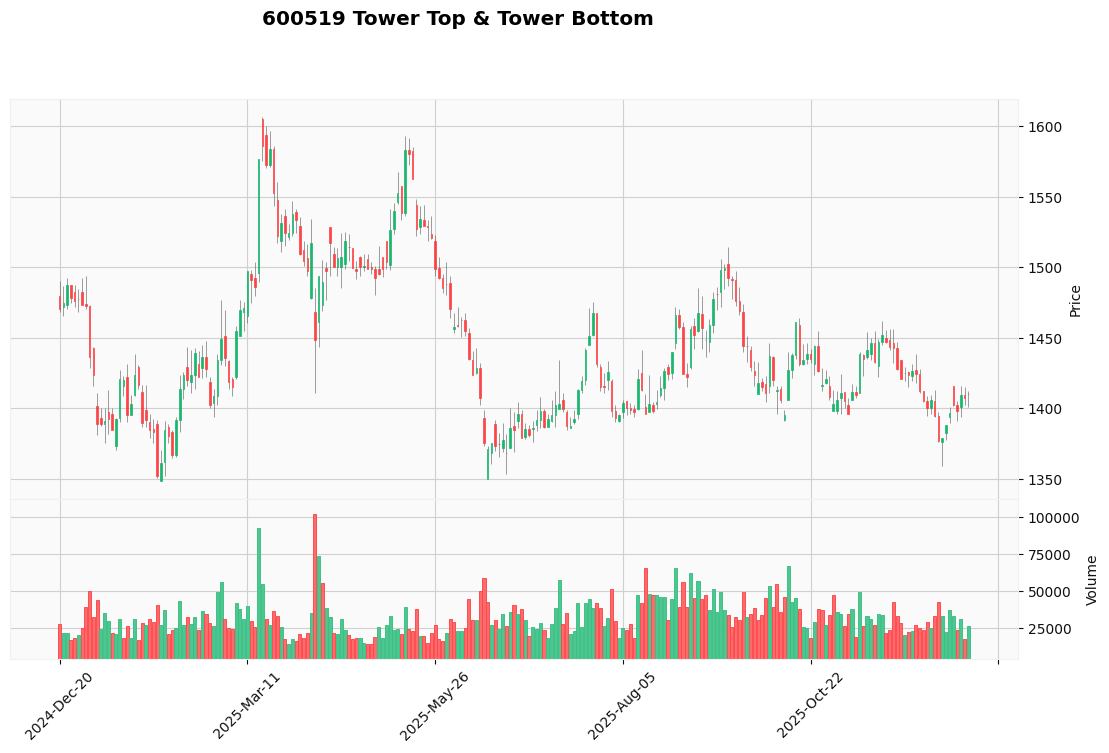

In [35]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 塔形形态识别 =========
# 补算缺失列（AkShare 数据里原来没有）
df['Range'] = df['High'] - df['Low']
df['Body']  = (df['Close'] - df['Open']).abs()

def tower_patterns(data: pd.DataFrame, w: int = 5, body_pct: float = 0.60) -> list:
    ...

# ========= 2. 塔形形态识别 =========
def tower_patterns(data: pd.DataFrame, w: int = 5, body_pct: float = 0.60) -> list:
    """
    简化版塔形：
    - 塔形顶：连续 w 根大阳线（实体≥body_pct）后，出现 w 根小实体/阴线
    - 塔形底：连续 w 根大阴线后，出现 w 根小实体/阳线
    返回：(形态名称, 日期, 价格)
    """
    signals = []
    for i in range(2 * w, len(data)):
        up_seg   = data.iloc[i - 2 * w:i - w]   # 前段
        down_seg = data.iloc[i - w:i]           # 后段

        # 塔形顶：前段大阳线，后段小实体
        up_big   = (up_seg['Close'] > up_seg['Open']).all() and (up_seg['Body'] >= body_pct * up_seg['Range']).all()
        down_small = (down_seg['Body'] <= 0.35 * down_seg['Range']).all()

        if up_big and down_small:
            signals.append(('Tower Top', data.index[i], data['Close'].iloc[i]))

        # 塔形底：前段大阴线，后段小实体
        down_big = (down_seg['Close'] < down_seg['Open']).all() and (down_seg['Body'] >= body_pct * down_seg['Range']).all()
        up_small = (up_seg['Body'] <= 0.35 * up_seg['Range']).all()

        if down_big and up_small:
            signals.append(('Tower Bottom', data.index[i], data['Close'].iloc[i]))
    return signals

signals = tower_patterns(df)

# ========= 3. 结果检查 =========
n_sig = len(signals)
print(f'塔形顶/底共 {n_sig} 次')
if n_sig == 0:
    print('当前参数下无塔形形态，可调宽 w 或放宽 body_pct 再试')

# ========= 4. 可视化 =========
# 生成与 df 等长的标记 & 颜色列
df['TowerMark'] = np.nan
df['TowerColor'] = np.nan
for name, date, price in signals:
    df.loc[date, 'TowerMark'] = price
    df.loc[date, 'TowerColor'] = 'red' if 'Top' in name else 'green'

# NaN → 透明
df['TowerColor'] = df['TowerColor'].fillna('none')

ap = []
if not df['TowerMark'].isna().all():
    ap.append(mpf.make_addplot(df['TowerMark'], type='scatter', marker='o',
                               markersize=100, color=df['TowerColor'].tolist()))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} Tower Top & Tower Bottom',
         style='yahoo', figsize=(14, 8))

# 窗口

向上跳空：1 次
向下跳空：4 次


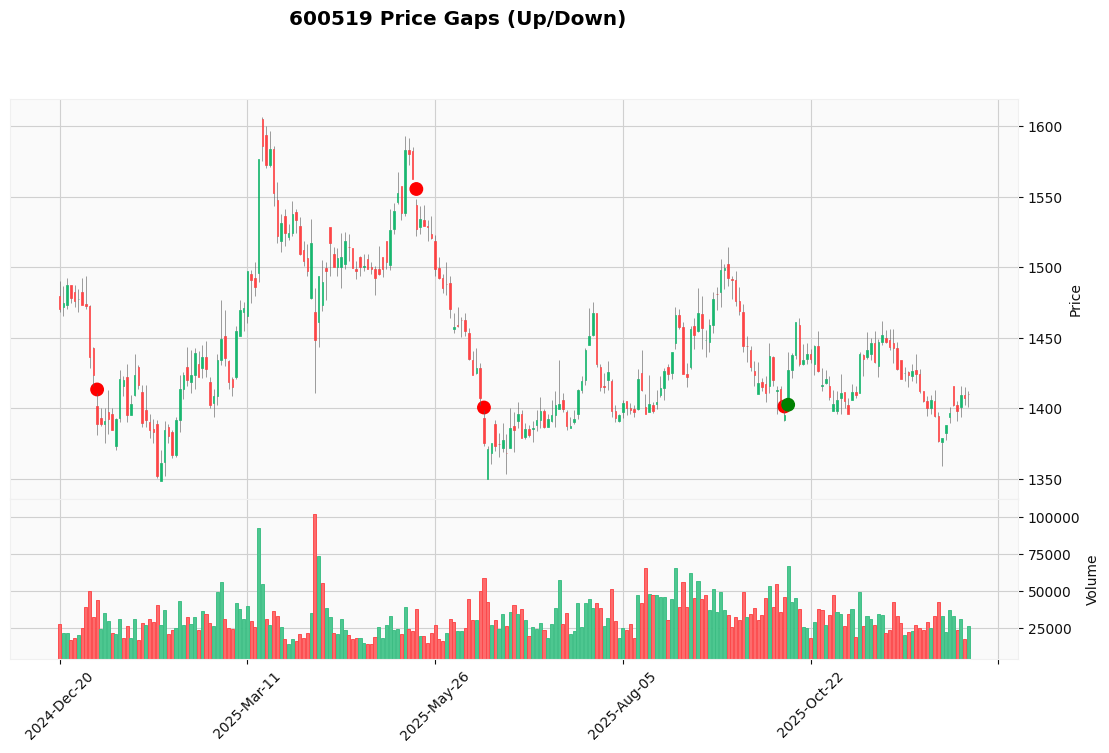

In [36]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 缺口识别 =========
def detect_gaps(data: pd.DataFrame, min_gap_pct: float = 0.005) -> pd.DataFrame:
    """
    返回与 data 等长的 DataFrame，包含：
    UpGap    : 向上缺口幅度（NaN 表示无）
    DownGap  : 向下缺口幅度（NaN 表示无）
    GapColor : 用于绘图的颜色（green/red/none）
    GapY     : 用于绘图的 Y 坐标（缺口中段）
    """
    df_gap = data.copy()
    df_gap['UpGap']   = np.nan
    df_gap['DownGap'] = np.nan
    df_gap['GapColor']= 'none'
    df_gap['GapY']    = np.nan

    for i in range(1, len(data)):
        prev, curr = data.iloc[i-1], data.iloc[i]
        up_gap   = curr['Low'] - prev['High']
        down_gap = prev['Low'] - curr['High']

        if up_gap > 0 and up_gap / prev['High'] >= min_gap_pct:
            df_gap.loc[data.index[i], 'UpGap']   = up_gap
            df_gap.loc[data.index[i], 'GapColor'] = 'green'
            df_gap.loc[data.index[i], 'GapY']     = (prev['High'] + curr['Low']) / 2

        if down_gap > 0 and down_gap / prev['High'] >= min_gap_pct:
            df_gap.loc[data.index[i], 'DownGap'] = down_gap
            df_gap.loc[data.index[i], 'GapColor'] = 'red'
            df_gap.loc[data.index[i], 'GapY']     = (prev['Low'] + curr['High']) / 2

    return df_gap

df_gap = detect_gaps(df, min_gap_pct=0.002)  # 0.2% 容差

# ========= 3. 结果检查 =========
n_up  = df_gap['UpGap'].notna().sum()
n_down = df_gap['DownGap'].notna().sum()
print(f'向上跳空：{n_up} 次')
print(f'向下跳空：{n_down} 次')
if n_up + n_down == 0:
    print('当前参数下无缺口，可调小 min_gap_pct 再试')

# ========= 4. 可视化 =========
# 与 df 等长的颜色 & Y 值（NaN→透明）
ap = []
if not df_gap['GapY'].isna().all():
    # 用 scatter 画缺口位置（绿色=向上，红色=向下）
    ap.append(mpf.make_addplot(df_gap['GapY'], type='scatter',
                               marker='o', markersize=80,
                               color=df_gap['GapColor'].tolist()))

mpf.plot(df, type='candle', volume=True, addplot=ap,
         title=f'{symbol_code} Price Gaps (Up/Down)',
         style='yahoo', figsize=(14, 8))

# 向上跳空和向下跳空并列阴阳线形态

识别到的窗口：
类型: 向下窗口, 位置: 10, 前一根蜡烛线: 1415.45 - 当前蜡烛线: 1411.10, 缺口大小: 4.35
类型: 向下窗口, 位置: 40, 前一根蜡烛线: 1422.44 - 当前蜡烛线: 1421.83, 缺口大小: 0.61
类型: 向下窗口, 位置: 95, 前一根蜡烛线: 1562.57 - 当前蜡烛线: 1548.44, 缺口大小: 14.13
类型: 向下窗口, 位置: 113, 前一根蜡烛线: 1402.54 - 当前蜡烛线: 1398.41, 缺口大小: 4.13
类型: 向下窗口, 位置: 114, 前一根蜡烛线: 1373.50 - 当前蜡烛线: 1373.48, 缺口大小: 0.02
类型: 向上窗口, 位置: 141, 前一根蜡烛线: 1442.64 - 当前蜡烛线: 1444.99, 缺口大小: 2.35
类型: 向下窗口, 位置: 156, 前一根蜡烛线: 1412.04 - 当前蜡烛线: 1409.72, 缺口大小: 2.32
类型: 向上窗口, 位置: 164, 前一根蜡烛线: 1440.04 - 当前蜡烛线: 1442.04, 缺口大小: 2.00
类型: 向下窗口, 位置: 191, 前一根蜡烛线: 1416.04 - 当前蜡烛线: 1415.42, 缺口大小: 0.62
类型: 向下窗口, 位置: 193, 前一根蜡烛线: 1403.54 - 当前蜡烛线: 1398.89, 缺口大小: 4.65
类型: 向上窗口, 位置: 194, 前一根蜡烛线: 1398.89 - 当前蜡烛线: 1406.03, 缺口大小: 7.14
类型: 向上窗口, 位置: 237, 前一根蜡烛线: 1388.03 - 当前蜡烛线: 1389.61, 缺口大小: 1.58
类型: 向上窗口, 位置: 238, 前一根蜡烛线: 1401.04 - 当前蜡烛线: 1401.61, 缺口大小: 0.57

向上跳空窗口：5 次
向下跳空窗口：8 次


E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\data_deal\Research on Stock Price Trend Forecast Based on LSTM Algorithm\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from fon

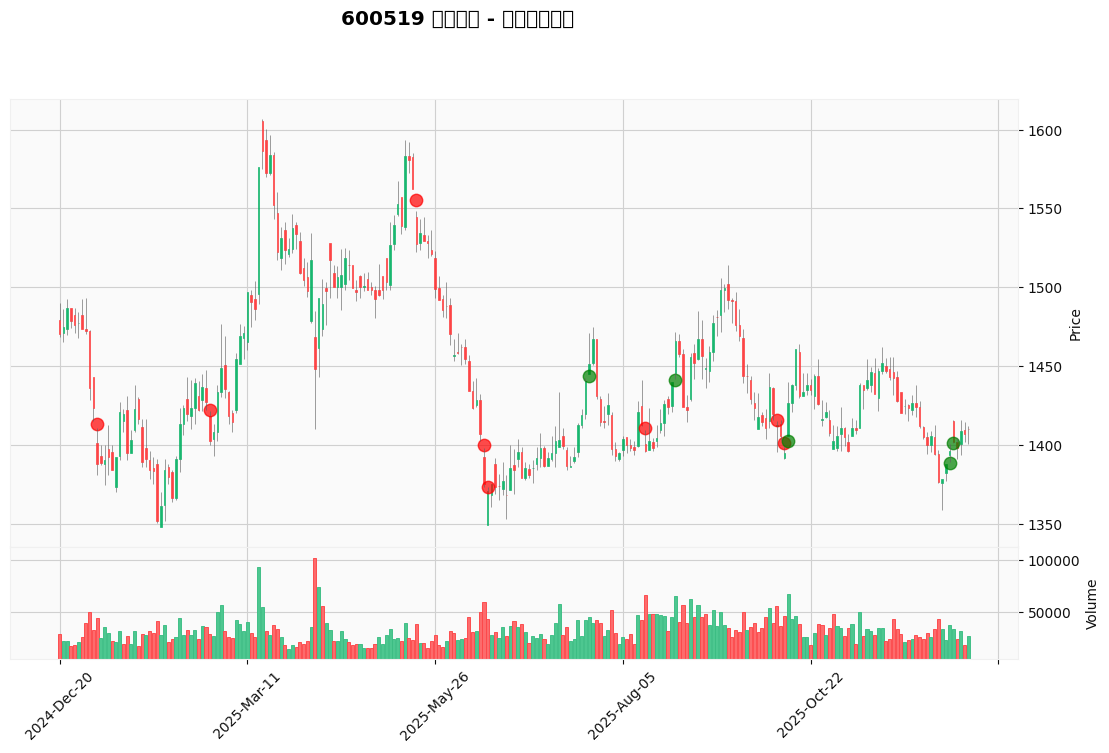

C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lyj15\AppData\Local\Temp\ipykernel_4744\1273338627.py:142: UserWarning: Glyph 36339 (\

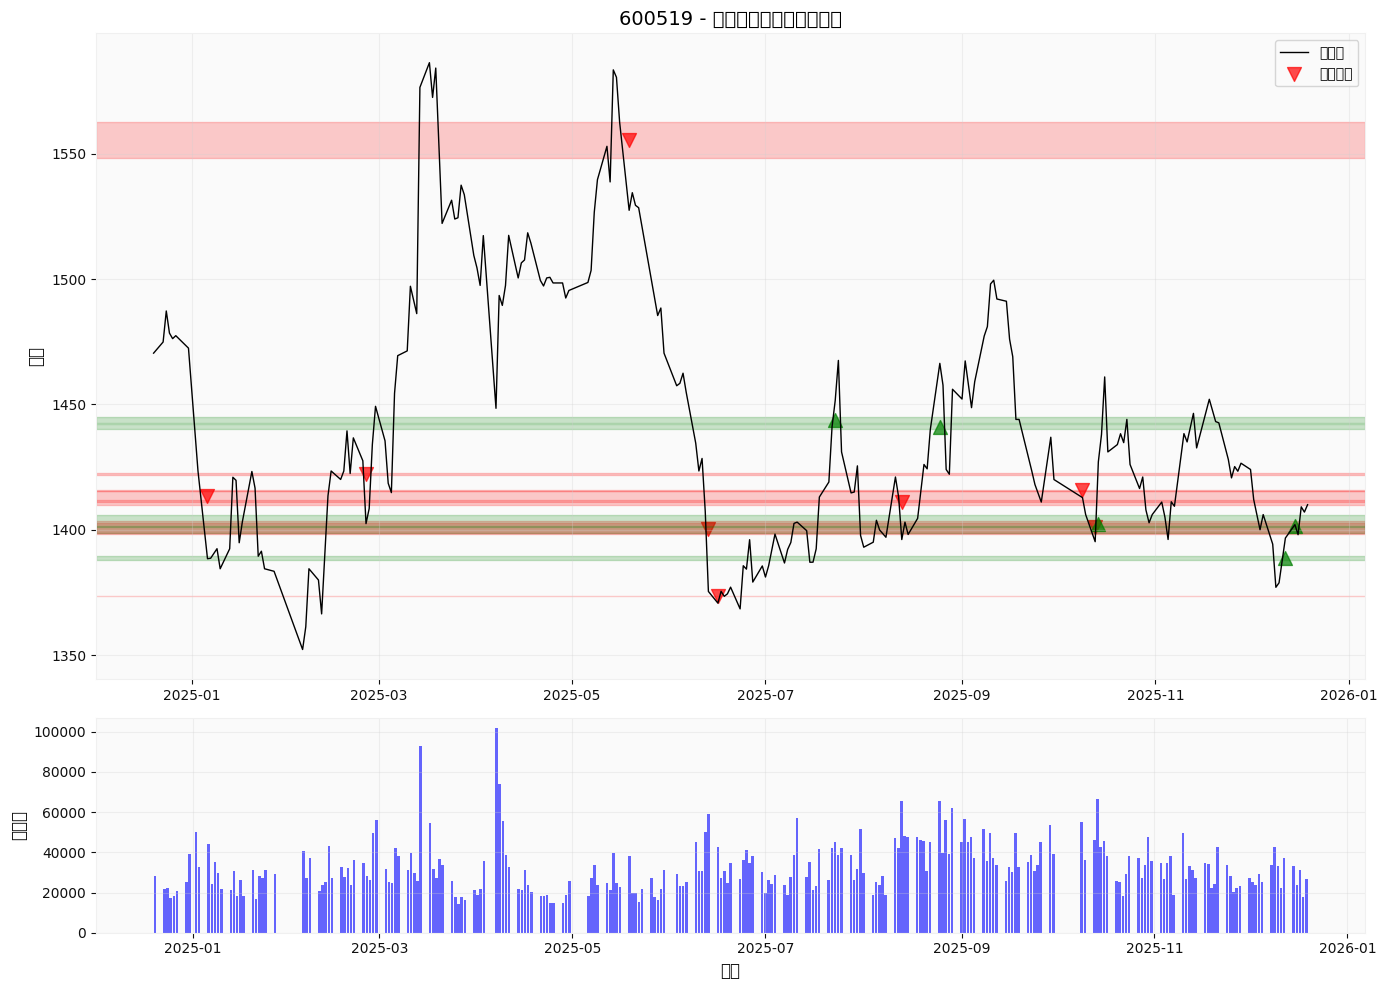


详细的窗口信息：
窗口 1: 2025-01-06 | 类型: ↓向下 | 缺口: 4.35 (0.31%) | 范围: 1415.45 → 1411.10
窗口 2: 2025-02-25 | 类型: ↓向下 | 缺口: 0.61 (0.04%) | 范围: 1422.44 → 1421.83
窗口 3: 2025-05-19 | 类型: ↓向下 | 缺口: 14.13 (0.90%) | 范围: 1562.57 → 1548.44
窗口 4: 2025-06-13 | 类型: ↓向下 | 缺口: 4.13 (0.29%) | 范围: 1402.54 → 1398.41
窗口 5: 2025-06-16 | 类型: ↓向下 | 缺口: 0.02 (0.00%) | 范围: 1373.50 → 1373.48
窗口 6: 2025-07-23 | 类型: ↑向上 | 缺口: 2.35 (0.16%) | 范围: 1442.64 → 1444.99
窗口 7: 2025-08-13 | 类型: ↓向下 | 缺口: 2.32 (0.16%) | 范围: 1412.04 → 1409.72
窗口 8: 2025-08-25 | 类型: ↑向上 | 缺口: 2.00 (0.14%) | 范围: 1440.04 → 1442.04
窗口 9: 2025-10-09 | 类型: ↓向下 | 缺口: 0.62 (0.04%) | 范围: 1416.04 → 1415.42
窗口 10: 2025-10-13 | 类型: ↓向下 | 缺口: 4.65 (0.33%) | 范围: 1403.54 → 1398.89
窗口 11: 2025-10-14 | 类型: ↑向上 | 缺口: 7.14 (0.51%) | 范围: 1398.89 → 1406.03
窗口 12: 2025-12-12 | 类型: ↑向上 | 缺口: 1.58 (0.11%) | 范围: 1388.03 → 1389.61
窗口 13: 2025-12-15 | 类型: ↑向上 | 缺口: 0.57 (0.04%) | 范围: 1401.04 → 1401.61


In [37]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 窗口识别逻辑 =========
def identify_window(df):
    """
    识别跳空窗口
    返回: list of (direction, index, prev_level, curr_level, gap_size)
    """
    windows = []

    for i in range(1, len(df)):
        prev_candle = df.iloc[i - 1]
        curr_candle = df.iloc[i]

        # 向上跳空窗口 (Previous High < Current Low)
        if prev_candle['High'] < curr_candle['Low']:
            gap_size = curr_candle['Low'] - prev_candle['High']
            windows.append(('up', i, prev_candle['High'], curr_candle['Low'], gap_size))

        # 向下跳空窗口 (Previous Low > Current High)
        elif prev_candle['Low'] > curr_candle['High']:
            gap_size = prev_candle['Low'] - curr_candle['High']
            windows.append(('down', i, prev_candle['Low'], curr_candle['High'], gap_size))

    return windows

# 识别窗口
windows = identify_window(df)

# 打印窗口信息
print("识别到的窗口：")
for direction, index, prev_level, curr_level, gap_size in windows:
    print(f"类型: {'向上窗口' if direction == 'up' else '向下窗口'}, "
          f"位置: {index}, "
          f"前一根蜡烛线: {prev_level:.2f} - 当前蜡烛线: {curr_level:.2f}, "
          f"缺口大小: {gap_size:.2f}")

# ========= 3. 结果统计 =========
n_up = len([w for w in windows if w[0] == 'up'])
n_down = len([w for w in windows if w[0] == 'down'])
print(f'\n向上跳空窗口：{n_up} 次')
print(f'向下跳空窗口：{n_down} 次')
if n_up + n_down == 0:
    print('当前数据中未识别到跳空窗口')

# ========= 4. 可视化 - 修复版本 =========
def plot_candlestick_with_windows(df, windows):
    """
    使用 mplfinance 绘制蜡烛图并标记窗口
    """
    # 准备标记数据 - 创建与df等长的Series，只有窗口位置有值
    gap_data = pd.Series(index=df.index, dtype=float)
    gap_colors = pd.Series(index=df.index, dtype=object)

    for direction, index, prev_level, curr_level, gap_size in windows:
        date_index = df.index[index]
        gap_data[date_index] = (prev_level + curr_level) / 2  # 缺口中间位置
        gap_colors[date_index] = 'green' if direction == 'up' else 'red'

    # 创建附加图形
    ap = []
    if not gap_data.isna().all():
        # 为每个窗口单独创建addplot
        for date in gap_data.index:
            if not pd.isna(gap_data[date]):
                single_gap = pd.Series(index=df.index, dtype=float)
                single_gap[date] = gap_data[date]
                color = gap_colors[date]

                ap.append(mpf.make_addplot(single_gap, type='scatter',
                                         marker='o', markersize=80,
                                         color=color, alpha=0.7))

    # 绘制蜡烛图
    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=f'{symbol_code} 价格图表 - 跳空窗口识别',
             style='yahoo', figsize=(14, 8),
             volume_panel=1, panel_ratios=(4, 1))

# 绘制图表
plot_candlestick_with_windows(df, windows)

# ========= 5. 简化版本 - 使用matplotlib直接绘制 =========
def plot_simple_candlestick(df, windows):
    """
    使用matplotlib直接绘制蜡烛图和窗口标记
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # 绘制价格走势
    ax1.plot(df.index, df['Close'], label='收盘价', color='black', linewidth=1)

    # 标记窗口位置
    for direction, index, prev_level, curr_level, gap_size in windows:
        date = df.index[index]
        if direction == 'up':
            ax1.scatter(date, (prev_level + curr_level) / 2,
                       color='green', s=100, marker='^', alpha=0.7,
                       label='向上窗口' if index == windows[0][1] else "")
            # 绘制窗口区域
            ax1.axhspan(prev_level, curr_level, alpha=0.2, color='green')
        else:
            ax1.scatter(date, (prev_level + curr_level) / 2,
                       color='red', s=100, marker='v', alpha=0.7,
                       label='向下窗口' if index == windows[0][1] else "")
            # 绘制窗口区域
            ax1.axhspan(curr_level, prev_level, alpha=0.2, color='red')

    ax1.set_title(f'{symbol_code} - 价格走势与跳空窗口识别', fontsize=14)
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 绘制成交量
    ax2.bar(df.index, df['Volume'], color='blue', alpha=0.6)
    ax2.set_ylabel('成交量', fontsize=12)
    ax2.set_xlabel('日期', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 使用简化版本
plot_simple_candlestick(df, windows)

# ========= 6. 详细窗口信息输出 =========
print("\n详细的窗口信息：")
print("=" * 80)
for i, (direction, index, prev_level, curr_level, gap_size) in enumerate(windows, 1):
    date = df.index[index]
    gap_pct = (gap_size / prev_level) * 100
    print(f"窗口 {i}: {date.strftime('%Y-%m-%d')} | "
          f"类型: {'↑向上' if direction == 'up' else '↓向下'} | "
          f"缺口: {gap_size:.2f} ({gap_pct:.2f}%) | "
          f"范围: {prev_level:.2f} → {curr_level:.2f}")

# 上升三法（上升三蜡烛线法）和下降三法（下降三蜡烛线法）形态

In [23]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 三法形态识别 =========
def identify_ascending_three_methods(df, min_body_ratio=0.6):
    """
    识别上升三法形态
    """
    patterns = []

    for i in range(4, len(df)):  # 需要至少5根K线
        # 获取连续5根K线
        day1 = df.iloc[i-4]  # 第一根长阳线
        day2 = df.iloc[i-3]  # 第二根回调线
        day3 = df.iloc[i-2]  # 第三根回调线
        day4 = df.iloc[i-1]  # 第四根回调线
        day5 = df.iloc[i]    # 第五根突破阳线

        # 计算实体大小
        day1_body = abs(day1['Close'] - day1['Open'])
        day1_range = day1['High'] - day1['Low']
        day5_body = abs(day5['Close'] - day5['Open'])

        # 条件1: 第一根是长阳线（实体占整根K线的比例较大）
        day1_body_ratio = day1_body / day1_range if day1_range > 0 else 0

        # 条件2: 第一根是阳线
        is_day1_bullish = day1['Close'] > day1['Open']

        # 条件3: 中间三根是小实体K线，且都在第一根K线范围内
        day2_in_range = (day2['High'] <= day1['High']) and (day2['Low'] >= day1['Low'])
        day3_in_range = (day3['High'] <= day1['High']) and (day3['Low'] >= day1['Low'])
        day4_in_range = (day4['High'] <= day1['High']) and (day4['Low'] >= day1['Low'])

        # 条件4: 中间三根总体趋势向下或横盘
        middle_trend = (day2['Close'] + day3['Close'] + day4['Close']) / 3 < day1['Close']

        # 条件5: 第五根是长阳线，收盘价超过第一根收盘价
        is_day5_bullish = day5['Close'] > day5['Open']
        is_breakout = day5['Close'] > day1['Close']

        if (is_day1_bullish and
            day1_body_ratio >= min_body_ratio and
            day2_in_range and day3_in_range and day4_in_range and
            middle_trend and
            is_day5_bullish and is_breakout):

            patterns.append({
                'type': '上升三法',
                'end_index': i,
                'end_date': df.index[i],
                'confidence': min(day1_body_ratio, day5_body/day1_body)
            })

    return patterns

def identify_descending_three_methods(df, min_body_ratio=0.6):
    """
    识别下降三法形态
    """
    patterns = []

    for i in range(4, len(df)):  # 需要至少5根K线
        # 获取连续5根K线
        day1 = df.iloc[i-4]  # 第一根长阴线
        day2 = df.iloc[i-3]  # 第二根反弹线
        day3 = df.iloc[i-2]  # 第三根反弹线
        day4 = df.iloc[i-1]  # 第四根反弹线
        day5 = df.iloc[i]    # 第五根突破阴线

        # 计算实体大小
        day1_body = abs(day1['Close'] - day1['Open'])
        day1_range = day1['High'] - day1['Low']
        day5_body = abs(day5['Close'] - day5['Open'])

        # 条件1: 第一根是长阴线（实体占整根K线的比例较大）
        day1_body_ratio = day1_body / day1_range if day1_range > 0 else 0

        # 条件2: 第一根是阴线
        is_day1_bearish = day1['Close'] < day1['Open']

        # 条件3: 中间三根是小实体K线，且都在第一根K线范围内
        day2_in_range = (day2['High'] <= day1['High']) and (day2['Low'] >= day1['Low'])
        day3_in_range = (day3['High'] <= day1['High']) and (day3['Low'] >= day1['Low'])
        day4_in_range = (day4['High'] <= day1['High']) and (day4['Low'] >= day1['Low'])

        # 条件4: 中间三根总体趋势向上或横盘
        middle_trend = (day2['Close'] + day3['Close'] + day4['Close']) / 3 > day1['Close']

        # 条件5: 第五根是长阴线，收盘价低于第一根收盘价
        is_day5_bearish = day5['Close'] < day5['Open']
        is_breakdown = day5['Close'] < day1['Close']

        if (is_day1_bearish and
            day1_body_ratio >= min_body_ratio and
            day2_in_range and day3_in_range and day4_in_range and
            middle_trend and
            is_day5_bearish and is_breakdown):

            patterns.append({
                'type': '下降三法',
                'end_index': i,
                'end_date': df.index[i],
                'confidence': min(day1_body_ratio, day5_body/day1_body)
            })

    return patterns

# ========= 3. 识别形态 =========
ascending_patterns = identify_ascending_three_methods(df)
descending_patterns = identify_descending_three_methods(df)

# ========= 4. 打印结果 =========
print("识别到的三法形态：")
print("=" * 60)

print("\n上升三法形态：")
for pattern in ascending_patterns:
    print(f"日期: {pattern['end_date'].strftime('%Y-%m-%d')} | "
          f"置信度: {pattern['confidence']:.2f}")

print("\n下降三法形态：")
for pattern in descending_patterns:
    print(f"日期: {pattern['end_date'].strftime('%Y-%m-%d')} | "
          f"置信度: {pattern['confidence']:.2f}")

print(f"\n总计: 上升三法 {len(ascending_patterns)} 个, 下降三法 {len(descending_patterns)} 个")

# ========= 5. 可视化 =========
def plot_patterns_with_mplfinance(df, patterns, pattern_type):
    """
    使用mplfinance绘制三法形态
    """
    # 准备标记数据
    pattern_dates = []
    pattern_prices = []
    pattern_colors = []

    for pattern in patterns:
        if pattern['type'] == pattern_type:
            date = pattern['end_date']
            price = df.loc[date, 'Close']
            pattern_dates.append(date)
            pattern_prices.append(price)
            pattern_colors.append('green' if pattern_type == '上升三法' else 'red')

    # 创建附加图形
    ap = []
    if pattern_dates:
        pattern_series = pd.Series(pattern_prices, index=pattern_dates)
        ap.append(mpf.make_addplot(pattern_series, type='scatter',
                                 marker='o', markersize=100,
                                 color=pattern_colors, alpha=0.6))

    # 绘制蜡烛图
    title = f'{symbol_code} - {pattern_type}形态识别'
    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=title, style='yahoo', figsize=(14, 8))

# 分别绘制上升三法和下降三法
if ascending_patterns:
    plot_patterns_with_mplfinance(df, ascending_patterns, '上升三法')

if descending_patterns:
    plot_patterns_with_mplfinance(df, descending_patterns, '下降三法')

# ========= 6. 详细分析版本 =========
def plot_detailed_analysis(df, patterns):
    """
    详细分析图表，标记完整的5根K线模式
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # 绘制价格走势
    ax1.plot(df.index, df['Close'], label='收盘价', color='black', linewidth=1, alpha=0.7)

    # 标记三法形态
    for pattern in patterns:
        end_idx = pattern['end_index']
        if end_idx >= 4:  # 确保有完整的5根K线
            start_idx = end_idx - 4
            pattern_dates = df.index[start_idx:end_idx+1]
            pattern_data = df.iloc[start_idx:end_idx+1]

            # 标记形态区域
            color = 'lightgreen' if pattern['type'] == '上升三法' else 'lightcoral'
            ax1.axvspan(pattern_dates[0], pattern_dates[-1],
                       alpha=0.2, color=color, label=pattern['type'])

            # 标记关键点
            marker = '^' if pattern['type'] == '上升三法' else 'v'
            marker_color = 'green' if pattern['type'] == '上升三法' else 'red'
            ax1.scatter(pattern_dates[-1], pattern_data['Close'].iloc[-1],
                       color=marker_color, marker=marker, s=100, zorder=5)

    ax1.set_title(f'{symbol_code} - 三法形态识别详细分析', fontsize=16)
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 绘制成交量
    ax2.bar(df.index, df['Volume'], color='blue', alpha=0.6)
    ax2.set_ylabel('成交量', fontsize=12)
    ax2.set_xlabel('日期', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 绘制详细分析图
all_patterns = ascending_patterns + descending_patterns
if all_patterns:
    plot_detailed_analysis(df, all_patterns)
else:
    print("未识别到三法形态，可以尝试调整参数或选择其他股票")

识别到的三法形态：

上升三法形态：

下降三法形态：

总计: 上升三法 0 个, 下降三法 0 个
未识别到三法形态，可以尝试调整参数或选择其他股票


# 分手线形态

识别到的分手线形态：

看涨分手线形态 (25 个):
日期: 2024-12-27 | 开盘价: 1477.34 | 强度: 0.000 | 价格差异: 0.34%
日期: 2025-01-08 | 开盘价: 1388.44 | 强度: 0.002 | 价格差异: 0.33%
日期: 2025-02-21 | 开盘价: 1428.44 | 强度: 0.006 | 价格差异: 0.21%
日期: 2025-03-06 | 开盘价: 1422.44 | 强度: 0.004 | 价格差异: 0.14%
日期: 2025-03-14 | 开盘价: 1496.10 | 强度: 0.004 | 价格差异: 0.25%
日期: 2025-04-08 | 开盘价: 1461.44 | 强度: 0.014 | 价格差异: 0.48%
日期: 2025-04-24 | 开盘价: 1500.44 | 强度: 0.000 | 价格差异: 0.46%
日期: 2025-06-26 | 开盘价: 1391.04 | 强度: 0.002 | 价格差异: 0.25%
日期: 2025-07-02 | 开盘价: 1385.54 | 强度: 0.000 | 价格差异: 0.04%
日期: 2025-07-30 | 开盘价: 1420.04 | 强度: 0.000 | 价格差异: 0.31%
日期: 2025-08-04 | 开盘价: 1391.04 | 强度: 0.003 | 价格差异: 0.49%
日期: 2025-08-11 | 开盘价: 1399.54 | 强度: 0.001 | 价格差异: 0.03%
日期: 2025-08-14 | 开盘价: 1396.98 | 强度: 0.004 | 价格差异: 0.29%
日期: 2025-08-18 | 开盘价: 1403.03 | 强度: 0.001 | 价格差异: 0.07%
日期: 2025-08-22 | 开盘价: 1424.92 | 强度: 0.004 | 价格差异: 0.32%
日期: 2025-08-29 | 开盘价: 1429.04 | 强度: 0.001 | 价格差异: 0.35%
日期: 2025-09-02 | 开盘价: 1454.70 | 强度: 0.004 | 价格差异: 0.24%
日期: 2025-09-29 | 开盘价

ValueError: x and y must be the same size

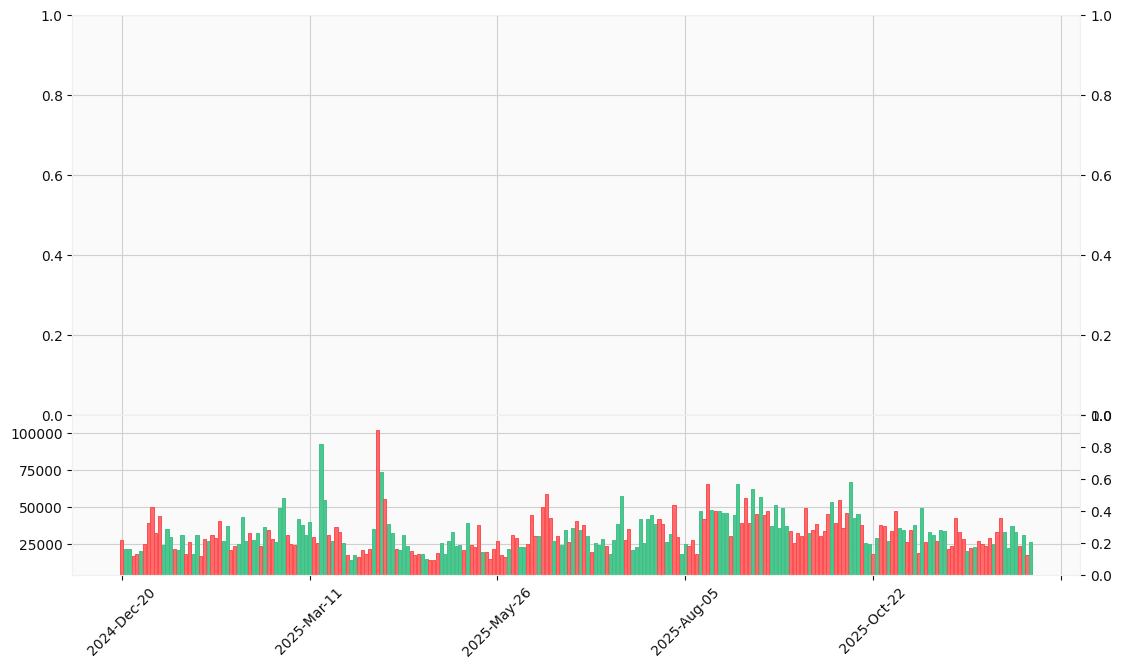

In [39]:
# ========= 1. AkShare 取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理成英文列 + Date 索引
df = (df_raw
      .rename(columns={'日期': 'Date',
                       '开盘': 'Open',
                       '最高': 'High',
                       '最低': 'Low',
                       '收盘': 'Close',
                       '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# ========= 2. 分手线形态识别 =========
def identify_separation_line(df, price_tolerance=0.01):
    """
    识别分手线形态
    price_tolerance: 价格容忍度，考虑到实际交易中完全相等的开盘价很少见
    """
    patterns = []

    for i in range(1, len(df)):
        first = df.iloc[i-1]  # 前一根蜡烛线
        second = df.iloc[i]   # 当前蜡烛线

        # 计算价格差异百分比
        open_diff_pct = abs(first['Open'] - second['Open']) / first['Open']

        # 看涨分手线：前一根是阴线，后一根是阳线，开盘价基本相同
        if (first['Close'] < first['Open']) and \
           (second['Close'] > second['Open']) and \
           (open_diff_pct <= price_tolerance):

            # 计算形态强度
            strength = min(
                (first['Open'] - first['Close']) / first['Open'],  # 第一根阴线实体强度
                (second['Close'] - second['Open']) / second['Open']  # 第二根阳线实体强度
            )

            patterns.append({
                'type': '看涨分手线',
                'index': i,
                'date': df.index[i],
                'first_open': first['Open'],
                'first_close': first['Close'],
                'second_open': second['Open'],
                'second_close': second['Close'],
                'strength': strength,
                'price_diff_pct': open_diff_pct
            })

        # 看跌分手线：前一根是阳线，后一根是阴线，开盘价基本相同
        elif (first['Close'] > first['Open']) and \
             (second['Close'] < second['Open']) and \
             (open_diff_pct <= price_tolerance):

            # 计算形态强度
            strength = min(
                (first['Close'] - first['Open']) / first['Open'],  # 第一根阳线实体强度
                (second['Open'] - second['Close']) / second['Open']  # 第二根阴线实体强度
            )

            patterns.append({
                'type': '看跌分手线',
                'index': i,
                'date': df.index[i],
                'first_open': first['Open'],
                'first_close': first['Close'],
                'second_open': second['Open'],
                'second_close': second['Close'],
                'strength': strength,
                'price_diff_pct': open_diff_pct
            })

    return patterns

# ========= 3. 识别形态 =========
separation_patterns = identify_separation_line(df, price_tolerance=0.005)  # 0.5%的价格容忍度

# ========= 4. 打印结果 =========
print("识别到的分手线形态：")
print("=" * 80)

bullish_patterns = [p for p in separation_patterns if p['type'] == '看涨分手线']
bearish_patterns = [p for p in separation_patterns if p['type'] == '看跌分手线']

print(f"\n看涨分手线形态 ({len(bullish_patterns)} 个):")
for pattern in bullish_patterns:
    print(f"日期: {pattern['date'].strftime('%Y-%m-%d')} | "
          f"开盘价: {pattern['second_open']:.2f} | "
          f"强度: {pattern['strength']:.3f} | "
          f"价格差异: {pattern['price_diff_pct']*100:.2f}%")

print(f"\n看跌分手线形态 ({len(bearish_patterns)} 个):")
for pattern in bearish_patterns:
    print(f"日期: {pattern['date'].strftime('%Y-%m-%d')} | "
          f"开盘价: {pattern['second_open']:.2f} | "
          f"强度: {pattern['strength']:.3f} | "
          f"价格差异: {pattern['price_diff_pct']*100:.2f}%")

print(f"\n总计: 看涨分手线 {len(bullish_patterns)} 个, 看跌分手线 {len(bearish_patterns)} 个")

# ========= 5. 使用 mplfinance 可视化 =========
def plot_separation_patterns_mplfinance(df, patterns):
    """
    使用 mplfinance 绘制分手线形态
    """
    # 准备标记数据
    pattern_dates = []
    pattern_prices = []
    pattern_colors = []
    pattern_markers = []

    for pattern in patterns:
        date = pattern['date']
        price = pattern['second_close']
        pattern_dates.append(date)
        pattern_prices.append(price)

        if pattern['type'] == '看涨分手线':
            pattern_colors.append('green')
            pattern_markers.append('^')
        else:
            pattern_colors.append('red')
            pattern_markers.append('v')

    # 创建附加图形
    ap = []
    if pattern_dates:
        pattern_series = pd.Series(pattern_prices, index=pattern_dates)
        ap.append(mpf.make_addplot(pattern_series, type='scatter',
                                 marker='o', markersize=100,
                                 color=pattern_colors, alpha=0.7))

    # 绘制蜡烛图
    title = f'{symbol_code} - 分手线形态识别 (总计: {len(patterns)} 个)'
    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=title, style='yahoo', figsize=(14, 8))

# 绘制所有分手线形态
if separation_patterns:
    plot_separation_patterns_mplfinance(df, separation_patterns)

# ========= 6. 详细分析图表 =========
def plot_detailed_separation_analysis(df, patterns):
    """
    绘制详细的分手线形态分析图表
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # 绘制价格走势
    ax1.plot(df.index, df['Close'], label='收盘价', color='black', linewidth=1, alpha=0.7)

    # 标记分手线形态
    for pattern in patterns:
        date = pattern['date']
        prev_date = df.index[pattern['index'] - 1]

        # 标记形态位置
        color = 'green' if pattern['type'] == '看涨分手线' else 'red'
        marker = '^' if pattern['type'] == '看涨分手线' else 'v'

        ax1.scatter(date, pattern['second_close'],
                   color=color, marker=marker, s=150, zorder=5,
                   label=f"{pattern['type']}" if pattern == patterns[0] else "")

        # 连接两根K线的开盘价（显示相同的开盘价）
        ax1.plot([prev_date, date], [pattern['first_open'], pattern['second_open']],
                color=color, linestyle='--', alpha=0.7, linewidth=2)

        # 添加文字说明
        ax1.annotate(pattern['type'],
                    xy=(date, pattern['second_close']),
                    xytext=(10, 20 if pattern['type'] == '看涨分手线' else -30),
                    textcoords='offset points',
                    fontsize=9, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.7))

    ax1.set_title(f'{symbol_code} - 分手线形态详细分析', fontsize=16)
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 绘制成交量
    ax2.bar(df.index, df['Volume'], color='blue', alpha=0.6)
    ax2.set_ylabel('成交量', fontsize=12)
    ax2.set_xlabel('日期', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 绘制详细分析图
if separation_patterns:
    plot_detailed_separation_analysis(df, separation_patterns)
else:
    print("未识别到分手线形态，可以尝试：")
    print("1. 调整价格容忍度参数")
    print("2. 选择其他股票")
    print("3. 扩大数据时间范围")

# ========= 7. 形态统计信息 =========
if separation_patterns:
    print("\n" + "=" * 50)
    print("形态统计信息:")
    print("=" * 50)

    avg_strength_bullish = np.mean([p['strength'] for p in bullish_patterns]) if bullish_patterns else 0
    avg_strength_bearish = np.mean([p['strength'] for p in bearish_patterns]) if bearish_patterns else 0

    print(f"看涨分手线平均强度: {avg_strength_bullish:.3f}")
    print(f"看跌分手线平均强度: {avg_strength_bearish:.3f}")
    print(f"平均价格差异: {np.mean([p['price_diff_pct'] for p in separation_patterns])*100:.3f}%")

    # 计算形态出现后的表现（简单统计）
    print(f"\n最近一个分手线形态:")
    last_pattern = separation_patterns[-1]
    print(f"  类型: {last_pattern['type']}")
    print(f"  日期: {last_pattern['date'].strftime('%Y-%m-%d')}")
    print(f"  开盘价: {last_pattern['second_open']:.2f}")
    print(f"  形态强度: {last_pattern['strength']:.3f}")

# 北方十字线

In [44]:

# ========= 1. 获取数据 =========
symbol_code = '600519'  # 贵州茅台示例
end_dt = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code,
                            period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'),
                            adjust='qfq')

# 整理数据
df = (df_raw
      .rename(columns={'日期': 'Date', '开盘': 'Open', '最高': 'High', '最低': 'Low', '收盘': 'Close', '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# 添加RSI指标（使用pandas简单实现；或用ta-lib）
def calculate_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

df = calculate_rsi(df)

# ========= 2. 北方十字线识别（优化版） =========
def identify_northern_doji(df,
                           min_body_ratio=0.5,  # 大阳实体比例
                           doji_threshold=0.03,  # 十字实体阈值
                           uptrend_lookback=5,  # 上升趋势期数
                           rsi_overbought=70,  # 超买阈值
                           require_gap=False,  # 是否要求跳空
                           max_doji_freq=0.1):  # 过去N天十字频率阈值（低频增强信号）
    patterns = []
    n = len(df)

    # 预计算过去十字线频率
    df['Body'] = abs(df['Close'] - df['Open'])
    df['Range'] = df['High'] - df['Low']
    df['Body_Ratio'] = df['Body'] / df['Range'].where(df['Range'] > 0, 0)
    df['Is_Doji'] = df['Body_Ratio'] <= doji_threshold

    for i in range(uptrend_lookback, n):
        first = df.iloc[i-1]  # 前一根（大阳）
        second = df.iloc[i]   # 当前（十字）

        # 条件1: 前一根是大阳线
        is_first_long_bullish = (first['Close'] > first['Open']) and (first['Body_Ratio'] >= min_body_ratio)

        # 条件2: 当前是十字线
        is_second_doji = second['Is_Doji']

        # 条件3: 可选跳空（书籍非强制）
        is_above_first = second['Low'] >= first['Close'] if require_gap else True

        # 条件4: 上升趋势（最近收盘 > 前一根，或MA向上）
        recent_closes = df['Close'].iloc[i-uptrend_lookback:i]
        is_uptrend = all(recent_closes.diff() > 0)  # 严格连续上涨；可放松

        # 条件5: 有显著影线（书籍变体如长腿/墓碑）
        upper_shadow = second['High'] - max(second['Open'], second['Close'])
        lower_shadow = min(second['Open'], second['Close']) - second['Low']
        shadow_ratio = max(upper_shadow, lower_shadow) / second['Range'] if second['Range'] > 0 else 0
        has_significant_shadows = shadow_ratio >= 0.3

        # 条件6: 超买状态（书籍强调）
        is_overbought = second['RSI'] > rsi_overbought

        # 条件7: 出现不多（过去uptrend_lookback*2天十字频率低）
        recent_dojis = df['Is_Doji'].iloc[i-uptrend_lookback*2:i].mean()
        is_rare = recent_dojis <= max_doji_freq

        if (is_first_long_bullish and is_second_doji and is_above_first and
            is_uptrend and has_significant_shadows and is_overbought and is_rare):

            # 强度计算（综合实体、RSI、频率）
            strength = (min(first['Body_Ratio'], 1 - second['Body_Ratio']) +
                        (second['RSI'] - 70)/30 + (1 - recent_dojis)) / 3

            patterns.append({
                'type': '北方十字线',
                'index': i,
                'date': df.index[i],
                'first_close': first['Close'],
                'second_close': second['Close'],
                'second_high': second['High'],
                'second_low': second['Low'],
                'strength': strength,
                'rsi': second['RSI'],
                'doji_freq': recent_dojis,
                'gap_size': second['Low'] - first['Close'] if require_gap else 0
            })

    return patterns

# ========= 3. 运行识别 =========
patterns = identify_northern_doji(df,
                                  min_body_ratio=0.5,
                                  doji_threshold=0.03,
                                  uptrend_lookback=3,
                                  rsi_overbought=70,
                                  require_gap=False,  # 书籍非强制
                                  max_doji_freq=0.1)

# ========= 4. 打印结果（表格形式） =========
if patterns:
    print("识别到的北方十字线形态：")
    data = [{
        '日期': p['date'].strftime('%Y-%m-%d'),
        '强度': f"{p['strength']:.3f}",
        'RSI': f"{p['rsi']:.1f}",
        '十字频率': f"{p['doji_freq']:.3f}",
        '缺口大小': f"{p['gap_size']:.2f}"
    } for p in patterns]

    print(pd.DataFrame(data).to_string(index=False))
    print(f"\n总计: {len(patterns)} 个")
else:
    print("未识别到形态。建议：降低rsi_overbought、增加数据范围，或放松is_uptrend。")

# ========= 5. 可视化（mplfinance） =========
def plot_patterns(df, patterns):
    ap = []
    if patterns:
        dates = [p['date'] for p in patterns]
        prices = [p['second_high'] * 1.01 for p in patterns]  # 稍上移标记
        texts = [f"强度:{p['strength']:.2f}\nRSI:{p['rsi']:.0f}" for p in patterns]

        ap.append(mpf.make_addplot(pd.Series(prices, index=dates), type='scatter',
                                   marker='*', markersize=150, color='orange'))
        # 添加文本（mplfinance不支持直接annotate，用循环）

    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=f'{symbol_code} - 北方十字线 (总: {len(patterns)})',
             style='yahoo', figsize=(14, 8))

if patterns:
    plot_patterns(df, patterns)

# ========= 6. 详细分析图（matplotlib） =========
def plot_detailed(df, patterns):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    # 价格图
    ax1.plot(df.index, df['Close'], label='Close', color='black')
    ax1.plot(df.index, df['Close'].rolling(20).mean(), label='MA20', color='blue', alpha=0.5)
    for p in patterns:
        ax1.scatter(p['date'], p['second_high'], color='orange', marker='*', s=200)
        ax1.annotate(f"北方十字\n强度:{p['strength']:.2f}\nRSI:{p['rsi']:.0f}",
                     (p['date'], p['second_high']), xytext=(10, 20),
                     textcoords='offset points', color='orange',
                     bbox=dict(facecolor='white', alpha=0.8))
    ax1.set_title(f'{symbol_code} - 北方十字线分析')
    ax1.legend()
    ax1.grid(True)

    # 成交量
    ax2.bar(df.index, df['Volume'], color='gray', alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    plt.show()

if patterns:
    plot_detailed(df, patterns)

# ========= 7. 后续表现统计（5/10天回报） =========
if patterns:
    print("\n后续表现分析:")
    for p in patterns:
        idx = p['index']
        base = p['second_close']
        for days in [5, 10]:
            if idx + days < len(df):
                ret = (df['Close'].iloc[idx+days] - base) / base * 100
                print(f"{p['date'].strftime('%Y-%m-%d')} 后{days}天回报: {ret:.2f}%")

# ========= 8. 参数敏感性 =========
print("\n参数敏感性:")
for thresh in [0.01, 0.02, 0.03]:
    test = identify_northern_doji(df, doji_threshold=thresh)
    print(f"doji_threshold={thresh}: {len(test)} 个")
for rsi in [60, 70, 80]:
    test = identify_northern_doji(df, rsi_overbought=rsi)
    print(f"rsi_overbought={rsi}: {len(test)} 个")

未识别到形态。建议：降低rsi_overbought、增加数据范围，或放松is_uptrend。

参数敏感性:
doji_threshold=0.01: 0 个
doji_threshold=0.02: 0 个
doji_threshold=0.03: 0 个
rsi_overbought=60: 0 个
rsi_overbought=70: 0 个
rsi_overbought=80: 0 个


# 长腿十字线（黄包车夫）、墓碑十字线与蜻蜓十字线

In [45]:
# ========= 1. 获取并准备数据 =========
symbol_code = '600519'  # 贵州茅台
end_dt = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code, period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'), adjust='qfq')

df = (df_raw
      .rename(columns={'日期': 'Date', '开盘': 'Open', '最高': 'High', '最低': 'Low', '收盘': 'Close', '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# 添加RSI和辅助列
def calculate_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

df = calculate_rsi(df)
df['Body'] = abs(df['Close'] - df['Open'])
df['Range'] = df['High'] - df['Low']
df['Body_Ratio'] = df['Body'] / df['Range'].where(df['Range'] > 0, 0)
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)
df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['Is_Doji'] = df['Body_Ratio'] <= 0.03  # 默认阈值

# ========= 2. 变体识别函数 =========
def identify_doji_variants(df,
                           doji_threshold=0.03,  # 实体阈值
                           shadow_ratio=0.4,  # 长影线比例（书籍长腿/墓碑/蜻蜓）
                           uptrend_lookback=5,  # 趋势期
                           rsi_overbought=70, rsi_oversold=30,  # 超买/卖
                           max_doji_freq=0.1,  # 频率阈值
                           require_trend=True):  # 是否需趋势
    patterns = []
    n = len(df)

    for i in range(uptrend_lookback, n):
        curr = df.iloc[i]
        if not curr['Is_Doji']: continue  # 必须是十字

        # 趋势判断：北方（上涨）或南方（下降）
        recent_closes = df['Close'].iloc[i-uptrend_lookback:i]
        is_uptrend = all(recent_closes.diff() > 0) if require_trend else False
        is_downtrend = all(recent_closes.diff() < 0) if require_trend else False

        # 频率检查
        recent_dojis = df['Is_Doji'].iloc[i-uptrend_lookback*2:i].mean()
        is_rare = recent_dojis <= max_doji_freq

        # 超买/卖
        is_overbought = curr['RSI'] > rsi_overbought
        is_oversold = curr['RSI'] < rsi_oversold

        # 公共强度基础
        strength_base = (1 - curr['Body_Ratio']) * (1 - recent_dojis)

        # 长腿十字线：长上/下影线
        if (curr['Upper_Shadow'] / curr['Range'] >= shadow_ratio and
            curr['Lower_Shadow'] / curr['Range'] >= shadow_ratio):
            if (is_uptrend and is_overbought and is_rare) or not require_trend:
                patterns.append({
                    'type': '长腿十字线 (北方)',
                    'index': i, 'date': df.index[i],
                    'close': curr['Close'], 'high': curr['High'], 'low': curr['Low'],
                    'strength': strength_base * (curr['RSI'] / 100),
                    'rsi': curr['RSI'], 'doji_freq': recent_dojis
                })
            elif (is_downtrend and is_oversold and is_rare) or not require_trend:
                patterns.append({
                    'type': '长腿十字线 (南方)',
                    'index': i, 'date': df.index[i],
                    'close': curr['Close'], 'high': curr['High'], 'low': curr['Low'],
                    'strength': strength_base * (1 - curr['RSI'] / 100),
                    'rsi': curr['RSI'], 'doji_freq': recent_dojis
                })

        # 墓碑十字线：长上影，收于低
        elif (curr['Upper_Shadow'] / curr['Range'] >= shadow_ratio * 1.2 and  # 更长上影
              min(curr['Open'], curr['Close']) - curr['Low'] < curr['Body'] * 2):  # 下影短
            if (is_uptrend and is_overbought and is_rare) or not require_trend:
                patterns.append({
                    'type': '墓碑十字线 (北方)',
                    'index': i, 'date': df.index[i],
                    'close': curr['Close'], 'high': curr['High'], 'low': curr['Low'],
                    'strength': strength_base * (curr['RSI'] / 100) * 1.2,  # 看跌加强
                    'rsi': curr['RSI'], 'doji_freq': recent_dojis
                })

        # 蜻蜓十字线：长下影，收于高
        elif (curr['Lower_Shadow'] / curr['Range'] >= shadow_ratio * 1.2 and
              curr['High'] - max(curr['Open'], curr['Close']) < curr['Body'] * 2):  # 上影短
            if (is_downtrend and is_oversold and is_rare) or not require_trend:
                patterns.append({
                    'type': '蜻蜓十字线 (南方)',
                    'index': i, 'date': df.index[i],
                    'close': curr['Close'], 'high': curr['High'], 'low': curr['Low'],
                    'strength': strength_base * (1 - curr['RSI'] / 100) * 1.1,  # 看涨稍强
                    'rsi': curr['RSI'], 'doji_freq': recent_dojis
                })

    return patterns

# ========= 3. 运行识别 =========
patterns = identify_doji_variants(df,
                                  doji_threshold=0.03,
                                  shadow_ratio=0.4,
                                  uptrend_lookback=3,
                                  rsi_overbought=70, rsi_oversold=30,
                                  max_doji_freq=0.1,
                                  require_trend=True)  # 书籍强调趋势

# ========= 4. 打印结果（表格） =========
if patterns:
    print("识别到的十字线变体：")
    data = [{
        '类型': p['type'],
        '日期': p['date'].strftime('%Y-%m-%d'),
        '强度': f"{p['strength']:.3f}",
        'RSI': f"{p['rsi']:.1f}",
        '十字频率': f"{p['doji_freq']:.3f}"
    } for p in patterns]
    print(pd.DataFrame(data).to_string(index=False))
    print(f"\n总计: {len(patterns)} 个")
else:
    print("未识别到变体。建议：调整shadow_ratio降低、require_trend=False，或扩大数据。")

# ========= 5. 可视化（mplfinance） =========
def plot_variants(df, patterns):
    ap = []
    if patterns:
        for color, marker in zip(['orange', 'red', 'green'], ['*', '^', 'v']):  # 长腿橙星、墓碑红上、蜻蜓绿下
            subset = [p for p in patterns if '长腿' in p['type'] or ('墓碑' in p['type'] and color=='red') or ('蜻蜓' in p['type'] and color=='green')]
            if subset:
                dates = [p['date'] for p in subset]
                prices = [p['high'] * 1.01 if '墓碑' in p['type'] else p['low'] * 0.99 if '蜻蜓' in p['type'] else p['close'] for p in subset]
                ap.append(mpf.make_addplot(pd.Series(prices, index=dates), type='scatter',
                                           marker=marker, markersize=150, color=color))

    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=f'{symbol_code} - 十字线变体 (总: {len(patterns)})',
             style='yahoo', figsize=(14, 8))

if patterns:
    plot_variants(df, patterns)

# ========= 6. 详细分析图（matplotlib） =========
def plot_detailed(df, patterns):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    # 价格图 + MA20
    ax1.plot(df.index, df['Close'], label='Close', color='black')
    ax1.plot(df.index, df['Close'].rolling(20).mean(), label='MA20', color='blue', alpha=0.5)
    colors = {'长腿': 'orange', '墓碑': 'red', '蜻蜓': 'green'}
    for p in patterns:
        typ = p['type'].split()[0]
        ax1.scatter(p['date'], p['high'] if '墓碑' in p['type'] else p['low'] if '蜻蜓' in p['type'] else p['close'],
                    color=colors.get(typ, 'gray'), marker='*', s=200)
        ax1.annotate(f"{p['type']}\n强度:{p['strength']:.2f}\nRSI:{p['rsi']:.0f}",
                     (p['date'], p['close']), xytext=(10, 20),
                     textcoords='offset points', color=colors.get(typ, 'gray'),
                     bbox=dict(facecolor='white', alpha=0.8))
    ax1.set_title(f'{symbol_code} - 十字线变体分析')
    ax1.legend()
    ax1.grid(True)

    # 成交量
    ax2.bar(df.index, df['Volume'], color='gray', alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    plt.show()

if patterns:
    plot_detailed(df, patterns)

# ========= 7. 后续表现统计 =========
if patterns:
    print("\n后续表现分析:")
    for p in patterns:
        idx = p['index']
        base = p['close']
        for days in [5, 10]:
            if idx + days < len(df):
                ret = (df['Close'].iloc[idx+days] - base) / base * 100
                dir = "看跌" if '北方' in p['type'] else "看涨"
                print(f"{p['date'].strftime('%Y-%m-%d')} ({p['type']}, {dir}) 后{days}天回报: {ret:.2f}%")

# ========= 8. 参数敏感性 =========
print("\n参数敏感性:")
for thresh in [0.02, 0.03, 0.05]:
    test = identify_doji_variants(df, doji_threshold=thresh)
    print(f"doji_threshold={thresh}: {len(test)} 个")
for shadow in [0.3, 0.4, 0.5]:
    test = identify_doji_variants(df, shadow_ratio=shadow)
    print(f"shadow_ratio={shadow}: {len(test)} 个")
for rsi_ob in [65, 70, 75]:
    test = identify_doji_variants(df, rsi_overbought=rsi_ob)
    print(f"rsi_overbought={rsi_ob}: {len(test)} 个")


未识别到变体。建议：调整shadow_ratio降低、require_trend=False，或扩大数据。

参数敏感性:
doji_threshold=0.02: 0 个
doji_threshold=0.03: 0 个
doji_threshold=0.05: 0 个
shadow_ratio=0.3: 0 个
shadow_ratio=0.4: 0 个
shadow_ratio=0.5: 0 个
rsi_overbought=65: 0 个
rsi_overbought=70: 0 个
rsi_overbought=75: 0 个


# 三星形态

In [25]:
# ========= 1. 获取并准备数据 =========
symbol_code = '600519'  # 贵州茅台
end_dt = datetime.today()
start_dt = end_dt - timedelta(days=365)
df_raw = ak.stock_zh_a_hist(symbol=symbol_code, period='daily',
                            start_date=start_dt.strftime('%Y%m%d'),
                            end_date=end_dt.strftime('%Y%m%d'), adjust='qfq')

df = (df_raw
      .rename(columns={'日期': 'Date', '开盘': 'Open', '最高': 'High', '最低': 'Low', '收盘': 'Close', '成交量': 'Volume'})
      .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
      .assign(Date=lambda x: pd.to_datetime(x['Date']))
      .set_index('Date')
      .sort_index())

# 添加RSI和辅助列
def calculate_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

df = calculate_rsi(df)
df['Body'] = abs(df['Close'] - df['Open'])
df['Range'] = df['High'] - df['Low']
df['Body_Ratio'] = df['Body'] / df['Range'].where(df['Range'] > 0, 0)
df['Is_Doji'] = df['Body_Ratio'] <= 0.03  # 默认

# ========= 2. 三星识别函数 =========
def identify_three_stars(df,
                         doji_threshold=0.03,
                         lookback=10,  # 新高/低/趋势看回
                         rsi_overbought=70, rsi_oversold=30,
                         max_doji_freq=0.1,
                         require_new_extreme=True):  # 是否需新高/低
    patterns = []
    n = len(df)
    df['Is_Doji'] = df['Body_Ratio'] <= doji_threshold

    for i in range(2, n):  # 从第三根开始
        if not all(df['Is_Doji'].iloc[i-2:i+1]): continue  # 三连续十字

        left, mid, right = df.iloc[i-2:i+1]

        # 头肩状：顶部中高，底部中低
        is_top = mid['High'] > max(left['High'], right['High']) and mid['Low'] > max(left['Low'], right['Low'])
        is_bottom = mid['Low'] < min(left['Low'], right['Low']) and mid['High'] < min(left['High'], right['High'])
        if not (is_top or is_bottom): continue

        # 趋势：顶部需上涨，底部需下降
        recent_closes = df['Close'].iloc[i-lookback:i-2]
        is_uptrend = recent_closes.max() == recent_closes.iloc[-1] if lookback > 0 else False  # 接近新高
        is_downtrend = recent_closes.min() == recent_closes.iloc[-1] if lookback > 0 else False

        # 新高/低（书籍位置）
        is_new_high = mid['High'] >= df['High'].iloc[i-lookback:i-2].max() if require_new_extreme else True
        is_new_low = mid['Low'] <= df['Low'].iloc[i-lookback:i-2].min() if require_new_extreme else True

        # 频率
        recent_dojis = df['Is_Doji'].iloc[i-lookback*2:i].mean()
        is_rare = recent_dojis <= max_doji_freq

        # RSI
        avg_rsi = np.mean([left['RSI'], mid['RSI'], right['RSI']])
        is_overbought = avg_rsi > rsi_overbought
        is_oversold = avg_rsi < rsi_oversold

        if is_top and is_uptrend and is_new_high and is_rare and is_overbought:
            strength = (1 - recent_dojis) * (avg_rsi / 100) * (1 if require_new_extreme else 0.8)
            patterns.append({
                'type': '三星顶部 (北方)',
                'index': i, 'date': right.index[0],  # 以最后一根日期
                'mid_high': mid['High'], 'mid_close': mid['Close'],
                'strength': strength, 'rsi': avg_rsi, 'doji_freq': recent_dojis
            })
        elif is_bottom and is_downtrend and is_new_low and is_rare and is_oversold:
            strength = (1 - recent_dojis) * (1 - avg_rsi / 100) * (1 if require_new_extreme else 0.8)
            patterns.append({
                'type': '三星底部 (南方)',
                'index': i, 'date': right.index[0],
                'mid_low': mid['Low'], 'mid_close': mid['Close'],
                'strength': strength, 'rsi': avg_rsi, 'doji_freq': recent_dojis
            })

    return patterns

# ========= 3. 运行识别 =========
patterns = identify_three_stars(df,
                                doji_threshold=0.03,
                                lookback=10,
                                rsi_overbought=70, rsi_oversold=30,
                                max_doji_freq=0.1,
                                require_new_extreme=True)

# ========= 4. 打印结果（表格） =========
if patterns:
    print("识别到的三星形态：")
    data = [{
        '类型': p['type'],
        '日期': p['date'].strftime('%Y-%m-%d'),
        '强度': f"{p['strength']:.3f}",
        '平均RSI': f"{p['rsi']:.1f}",
        '十字频率': f"{p['doji_freq']:.3f}"
    } for p in patterns]
    print(pd.DataFrame(data).to_string(index=False))
    print(f"\n总计: {len(patterns)} 个")
else:
    print("未识别到三星（罕见）。建议：放松doji_threshold、require_new_extreme=False，或换股/扩大数据。")

# ========= 5. 可视化（mplfinance） =========
def plot_three_stars(df, patterns):
    ap = []
    if patterns:
        dates = [p['date'] for p in patterns]
        prices = [p['mid_high'] * 1.01 if '顶部' in p['type'] else p['mid_low'] * 0.99 for p in patterns]
        colors = ['red' if '顶部' in p['type'] else 'green' for p in patterns]
        ap.append(mpf.make_addplot(pd.Series(prices, index=dates), type='scatter',
                                   marker='*', markersize=200, color=colors))

    mpf.plot(df, type='candle', volume=True, addplot=ap,
             title=f'{symbol_code} - 三星形态 (总: {len(patterns)})',
             style='yahoo', figsize=(14, 8))

if patterns:
    plot_three_stars(df, patterns)

# ========= 6. 详细分析图（matplotlib） =========
def plot_detailed(df, patterns):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    # 价格 + MA20
    ax1.plot(df.index, df['Close'], label='Close', color='black')
    ax1.plot(df.index, df['Close'].rolling(20).mean(), label='MA20', color='blue', alpha=0.5)
    for p in patterns:
        color = 'red' if '顶部' in p['type'] else 'green'
        pos = p['mid_high'] if '顶部' in p['type'] else p['mid_low']
        ax1.scatter(p['date'], pos, color=color, marker='*', s=200)
        ax1.annotate(f"{p['type']}\n强度:{p['strength']:.2f}\nRSI:{p['rsi']:.0f}",
                     (p['date'], p['mid_close']), xytext=(10, 20 if '顶部' in p['type'] else -40),
                     textcoords='offset points', color=color,
                     bbox=dict(facecolor='white', alpha=0.8))
    ax1.set_title(f'{symbol_code} - 三星形态分析')
    ax1.legend()
    ax1.grid(True)

    # 成交量
    ax2.bar(df.index, df['Volume'], color='gray', alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    plt.show()

if patterns:
    plot_detailed(df, patterns)

# ========= 7. 后续表现统计 =========
if patterns:
    print("\n后续表现分析:")
    for p in patterns:
        idx = p['index']
        base = df['Close'].iloc[idx]
        for days in [5, 10]:
            if idx + days < len(df):
                ret = (df['Close'].iloc[idx+days] - base) / base * 100
                dir = "看跌" if '顶部' in p['type'] else "看涨"
                print(f"{p['date'].strftime('%Y-%m-%d')} ({p['type']}, {dir}) 后{days}天回报: {ret:.2f}%")

# ========= 8. 参数敏感性 =========
print("\n参数敏感性:")
for thresh in [0.02, 0.03, 0.05]:
    test = identify_three_stars(df, doji_threshold=thresh)
    print(f"doji_threshold={thresh}: {len(test)} 个")
for lb in [5, 10, 15]:
    test = identify_three_stars(df, lookback=lb)
    print(f"lookback={lb}: {len(test)} 个")
for rsi_ob in [65, 70, 75]:
    test = identify_three_stars(df, rsi_overbought=rsi_ob)
    print(f"rsi_overbought={rsi_ob}: {len(test)} 个")


未识别到三星（罕见）。建议：放松doji_threshold、require_new_extreme=False，或换股/扩大数据。

参数敏感性:
doji_threshold=0.02: 0 个
doji_threshold=0.03: 0 个
doji_threshold=0.05: 0 个
lookback=5: 0 个
lookback=10: 0 个
lookback=15: 0 个
rsi_overbought=65: 0 个
rsi_overbought=70: 0 个
rsi_overbought=75: 0 个


# 破低反涨形态与破高反跌形态

看涨捉腰带线：3 次
看跌捉腰带线：2 次
破低反涨形态：6 次
破高反跌形态：12 次


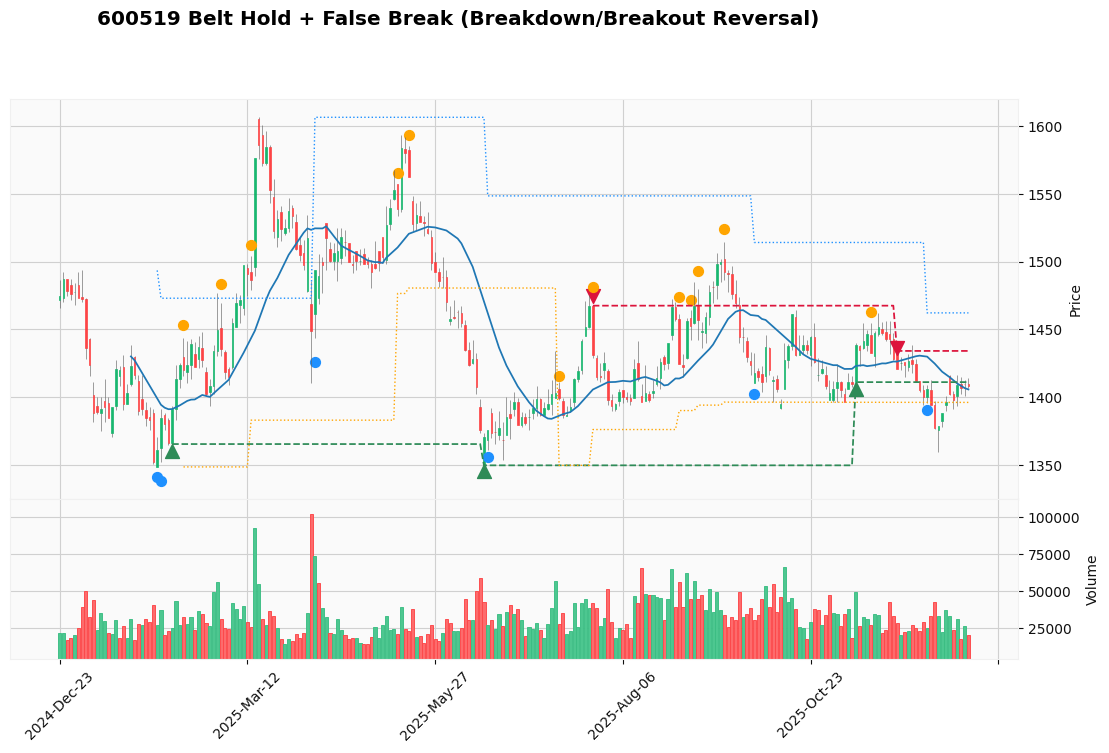

In [27]:
# ========= 1. 获取最近 365 天前复权日线 =========
symbol_code = '600519'          # 贵州茅台示例
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

# 整理成英文列 + Date 索引
df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# ========= 2. 公共指标：Range / Body / MA 等 =========
ma_len = 20
df["Range"] = (df["High"] - df["Low"]).replace(0, 1e-6)
df["Body"]  = (df["Close"] - df["Open"]).abs()
df["MA"]    = df["Close"].rolling(ma_len).mean()

upper_shadow = df["High"] - np.maximum(df["Open"], df["Close"])
lower_shadow = np.minimum(df["Open"], df["Close"]) - df["Low"]

# ========= 3. 捉腰带线识别（优化版） =========
use_trend_filter   = True
body_min_pct       = 0.65   # 实体至少占 65% 全日波动
same_side_shadow_max   = 0.05  # “同侧”影线 ≤ 5% Range
other_side_shadow_max  = 0.20  # 另一侧影线 ≤ 20% Range
confirm_bull = False
confirm_bear = False
confirm_shift = 3          # 若启用确认，可看未来 3 根

# 看涨捉腰带线：长阳 + 下影极短 + 上影不过长
bullish_long_body = (df["Close"] > df["Open"]) & (df["Body"] >= body_min_pct * df["Range"])
bull_small_lower  = (lower_shadow <= same_side_shadow_max * df["Range"])
bull_not_long_upper = (upper_shadow <= other_side_shadow_max * df["Range"])
bull_basic = bullish_long_body & bull_small_lower & bull_not_long_upper

# 趋势过滤（下行背景中出现）
if use_trend_filter:
    trend_lookback = 5
    trend_down = (
            (df["Close"].shift(1) < df["MA"].shift(1)) &
            (df["Close"].shift(1).rolling(trend_lookback).mean() <
             df["MA"].shift(1).rolling(trend_lookback).mean())
    )
else:
    trend_down = pd.Series(True, index=df.index)

# 看涨确认
if confirm_bull:
    future_max_close = df["Close"].shift(-1).rolling(confirm_shift).max()
    bull_confirm_ok  = future_max_close > df["Close"]
else:
    bull_confirm_ok  = True

df["Bull_BeltHold"] = bull_basic & trend_down & bull_confirm_ok
df["BH_Support"]    = np.where(df["Bull_BeltHold"], df["Low"], np.nan)

# 看跌捉腰带线：长阴 + 上影极短 + 下影不过长
bearish_long_body = (df["Close"] < df["Open"]) & (df["Body"] >= body_min_pct * df["Range"])
bear_small_upper    = (upper_shadow <= same_side_shadow_max * df["Range"])
bear_not_long_lower = (lower_shadow <= other_side_shadow_max * df["Range"])
bear_basic = bearish_long_body & bear_small_upper & bear_not_long_lower

# 趋势过滤（上行背景中出现）
if use_trend_filter:
    trend_lookback = 5
    trend_up = (
            (df["Close"].shift(1) > df["MA"].shift(1)) &
            (df["Close"].shift(1).rolling(trend_lookback).mean() >
             df["MA"].shift(1).rolling(trend_lookback).mean())
    )
else:
    trend_up = pd.Series(True, index=df.index)

# 看跌确认
if confirm_bear:
    future_min_close = df["Close"].shift(-1).rolling(confirm_shift).min()
    bear_confirm_ok  = future_min_close < df["Close"]
else:
    bear_confirm_ok  = True

df["Bear_BeltHold"] = bear_basic & trend_up & bear_confirm_ok
df["BH_Resistance"] = np.where(df["Bear_BeltHold"], df["High"], np.nan)

# ========= 4. 破高反跌 / 破低反涨形态（假突破）检测 =========
# 这里用简单的布林带上下轨近似横盘阻力 / 支撑带，你可以替换成更精细的区间检测。

bb_mid   = df["Close"].rolling(20).mean()
bb_std   = df["Close"].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std

# --- 破低反涨（先破支撑再收复） ---
# 条件：当天最低价 < 昨日下轨（视作跌破支撑），但收盘价 > 昨日下轨（收复）
support_breakdown = (df["Low"] < bb_lower.shift(1)) & (df["Close"] > bb_lower.shift(1))

# 可叠加看涨实体作为过滤：白K
bullish_candle = df["Close"] > df["Open"]
df["Breakdown_Rev"] = support_breakdown & bullish_candle

# 止损：最近新低（这里简单用当日 Low，下方可再加 buffer）
df["BD_Stop"] = np.where(df["Breakdown_Rev"], df["Low"], np.nan)

# 价格目标：前一段高点（最近 N 日高点）
lookback_target = 20
recent_high = df["High"].rolling(lookback_target).max().shift(1)
df["BD_Target"] = np.where(df["Breakdown_Rev"], recent_high, np.nan)

# --- 破高反跌（先破阻力再收回） ---
# 条件：当天最高价 > 昨日上轨（视作突破阻力），但收盘价 < 昨日上轨（收回）
resistance_breakout = (df["High"] > bb_upper.shift(1)) & (df["Close"] < bb_upper.shift(1))

# 可叠加看跌实体作为过滤：黑K
bearish_candle = df["Close"] < df["Open"]
df["Breakout_Rev"] = resistance_breakout & bearish_candle

# 止损：最近新高
df["BO_Stop"] = np.where(df["Breakout_Rev"], df["High"], np.nan)

# 价格目标：前一段低点（最近 N 日低点）
recent_low = df["Low"].rolling(lookback_target).min().shift(1)
df["BO_Target"] = np.where(df["Breakout_Rev"], recent_low, np.nan)

# ========= 5. 结果统计 =========
n_bull_bh = int(df["Bull_BeltHold"].sum())
n_bear_bh = int(df["Bear_BeltHold"].sum())
n_bd_rev  = int(df["Breakdown_Rev"].sum())
n_bo_rev  = int(df["Breakout_Rev"].sum())

print(f'看涨捉腰带线：{n_bull_bh} 次')
print(f'看跌捉腰带线：{n_bear_bh} 次')
print(f'破低反涨形态：{n_bd_rev} 次')
print(f'破高反跌形态：{n_bo_rev} 次')
if n_bull_bh + n_bear_bh + n_bd_rev + n_bo_rev == 0:
    print('当前参数下无形态，可放宽条件再试')

# ========= 6. 可视化（捉腰带 + 假突破） =========
ap = []

# 20 日均线
ap.append(mpf.make_addplot(df["MA"], color='tab:blue'))

# 捉腰带标记
rng = df["Range"].replace(0, 1e-6)
bull_marks = np.where(df["Bull_BeltHold"], df["Low"] - rng * 0.18, np.nan)
bear_marks = np.where(df["Bear_BeltHold"], df["High"] + rng * 0.18, np.nan)

for marks, color, marker in [
    (bull_marks, 'seagreen', '^'),
    (bear_marks, 'crimson', 'v')
]:
    if not np.all(np.isnan(marks)):
        ap.append(
            mpf.make_addplot(
                marks,
                type="scatter",
                marker=marker,
                markersize=100,
                color=color
            )
        )

# 破低反涨 / 破高反跌标记（用小点或其他符号）
bd_marks = np.where(df["Breakdown_Rev"], df["Low"] - rng * 0.35, np.nan)
bo_marks = np.where(df["Breakout_Rev"], df["High"] + rng * 0.35, np.nan)

for marks, color, marker in [
    (bd_marks, 'dodgerblue', 'o'),
    (bo_marks, 'orange', 'o')
]:
    if not np.all(np.isnan(marks)):
        ap.append(
            mpf.make_addplot(
                marks,
                type="scatter",
                marker=marker,
                markersize=50,
                color=color
            )
        )

# 捉腰带形成的支撑/阻力阶梯线
for col, color in [('BH_Support', 'seagreen'), ('BH_Resistance', 'crimson')]:
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(mpf.make_addplot(plot_col, color=color, linestyle='--'))

# 破低反涨 / 破高反跌的目标位也画成阶梯线（可选）
# 破低反涨 / 破高反跌的目标位也画成阶梯线（可选）
for col, color in [('BD_Target', 'dodgerblue'), ('BO_Target', 'orange')]:
    if col not in df.columns:
        continue
    plot_col = pd.Series(df[col]).ffill()
    if not plot_col.isna().all():
        ap.append(
            mpf.make_addplot(
                plot_col,
                color=color,
                linestyle=':',
                width=1  # 用 width 代替 linewidth
            )
        )

mpf.plot(
    df,
    type="candle",
    volume=True,
    addplot=ap,
    title=f'{symbol_code} Belt Hold + False Break (Breakdown/Breakout Reversal)',
    style="yahoo",
    figsize=(14, 8)
)


# 极性转换原则

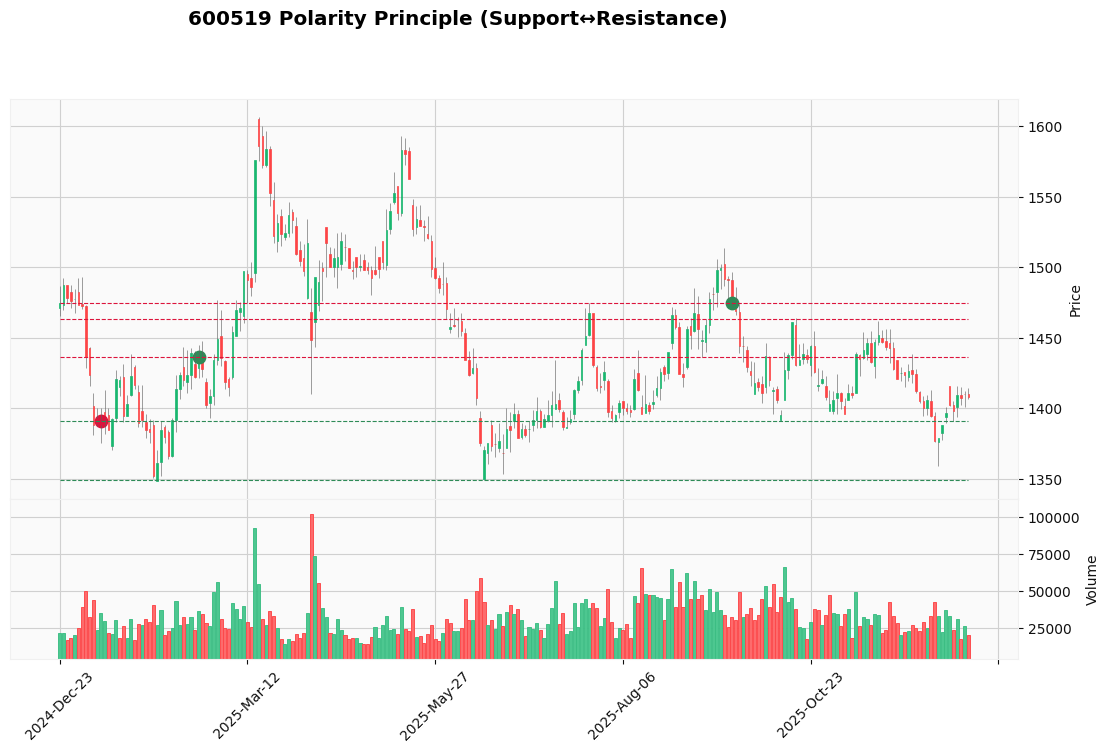

In [28]:
# ========== 1. 拉取数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# ========== 2. 先用“局部极值 + 聚合”找关键支撑/阻力水平 ==========
# 简单做法：在 rolling 窗口内的最低/最高点视为 swing 低/高，然后把价格相近的 swing 低/高聚合为一条水平线。[web:239][web:241][web:250]

lookback_swing = 5   # 前后各 5 根
tol_pct        = 0.003  # 价位聚类容差，例如 0.3%

lows  = df['Low']
highs = df['High']

# 判断某根是不是局部低/高
is_swing_low  = (lows == lows.rolling(lookback_swing*2+1, center=True).min())
is_swing_high = (highs == highs.rolling(lookback_swing*2+1, center=True).max())

swing_low_points  = df[is_swing_low][['Low']]
swing_high_points = df[is_swing_high][['High']]

def cluster_levels(values, tol):
    """把相近价位聚成一条水平线，返回中心价及被测试次数。"""
    levels = []
    counts = []
    values_sorted = sorted(values)
    if not values_sorted:
        return np.array([]), np.array([])
    current_cluster = [values_sorted[0]]
    for v in values_sorted[1:]:
        if abs(v - np.mean(current_cluster)) / np.mean(current_cluster) <= tol:
            current_cluster.append(v)
        else:
            levels.append(np.mean(current_cluster))
            counts.append(len(current_cluster))
            current_cluster = [v]
    levels.append(np.mean(current_cluster))
    counts.append(len(current_cluster))
    return np.array(levels), np.array(counts)

support_levels, support_counts = cluster_levels(swing_low_points['Low'].tolist(), tol_pct)
resist_levels,  resist_counts  = cluster_levels(swing_high_points['High'].tolist(), tol_pct)

# 只保留“至少被测试 N 次”的强水平
min_touch = 2
support_levels = support_levels[support_counts >= min_touch]
resist_levels  = resist_levels[resist_counts  >= min_touch]

# ========== 3. 极性转换检测 ==========
# 定义“有效突破 + 回踩”的基本条件：[web:243][web:247]
close = df['Close']

# 初始化结果列
df['SupToRes'] = np.nan   # 支撑 -> 阻力 转换点价位
df['ResToSup'] = np.nan   # 阻力 -> 支撑 转换点价位

# 参数：要求在突破后一段时间内完成回踩
retest_window = 20        # 突破后在多少根K线内寻找回踩
buffer_pct    = 0.0015    # 突破/回踩容差（0.15%）

# --- 支撑 -> 阻力 ---
for level in support_levels:
    # 1) 找到“首次有效跌破”支撑的索引
    # 条件：前一根收盘在支撑上方，本根收盘在支撑下方
    broke_idx = df[
        (close.shift(1) > level * (1 + buffer_pct)) &
        (close < level * (1 - buffer_pct))
        ].index

    for bidx in broke_idx:
        # 2) 在之后 retest_window 根内，寻找“收盘回到支撑附近（±buffer）”的回踩点
        sub = df.loc[bidx:].iloc[1:retest_window+1]  # 跳过突破当根
        if sub.empty:
            continue
        # 回到支撑附近且价格在 level 附近（反弹）
        retest = sub[
            (sub['Close'] >= level * (1 - buffer_pct)) &
            (sub['Close'] <= level * (1 + buffer_pct))
            ]
        if not retest.empty:
            ridx = retest.index[0]
            df.at[ridx, 'SupToRes'] = level    # 在回踩那根标记一次“支撑→阻力”
            break  # 对于该 level，只记第一次极性转换

# --- 阻力 -> 支撑 ---
for level in resist_levels:
    # 1) 找到“首次有效突破”阻力的索引
    # 条件：前一根收盘在阻力下方，本根收盘在阻力上方
    broke_idx = df[
        (close.shift(1) < level * (1 - buffer_pct)) &
        (close > level * (1 + buffer_pct))
        ].index

    for bidx in broke_idx:
        sub = df.loc[bidx:].iloc[1:retest_window+1]
        if sub.empty:
            continue
        # 回踩到阻力附近（现在当支撑）
        retest = sub[
            (sub['Close'] >= level * (1 - buffer_pct)) &
            (sub['Close'] <= level * (1 + buffer_pct))
            ]
        if not retest.empty:
            ridx = retest.index[0]
            df.at[ridx, 'ResToSup'] = level    # 在回踩那根标记一次“阻力→支撑”
            break

# ========== 4. 可视化：水平线 + 极性转换标记 ==========
ap = []

# 画出所有有效支撑/阻力水平（历史）
for lvl in support_levels:
    ap.append(
        mpf.make_addplot(
            pd.Series(lvl, index=df.index),
            color='seagreen',
            linestyle='--',
            width=0.8
        )
    )

for lvl in resist_levels:
    ap.append(
        mpf.make_addplot(
            pd.Series(lvl, index=df.index),
            color='crimson',
            linestyle='--',
            width=0.8
        )
    )

# 极性转换标记：支撑->阻力 用红色圆点，阻力->支撑 用绿色圆点
sup2res_marks = np.where(~df['SupToRes'].isna(), df['SupToRes'], np.nan)
res2sup_marks = np.where(~df['ResToSup'].isna(), df['ResToSup'], np.nan)

if not np.all(np.isnan(sup2res_marks)):
    ap.append(
        mpf.make_addplot(
            sup2res_marks,
            type='scatter',
            marker='o',
            markersize=80,
            color='crimson'
        )
    )

if not np.all(np.isnan(res2sup_marks)):
    ap.append(
        mpf.make_addplot(
            res2sup_marks,
            type='scatter',
            marker='o',
            markersize=80,
            color='seagreen'
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Polarity Principle (Support↔Resistance)',
    figsize=(14, 8)
)


# 蜡烛图与百分比回撤水平

趋势方向: down, 起点价: 1514.06, 终点价: 1359.22
38.2% 回撤位: 1300.07
50% 回撤位: 1281.80
61.8% 回撤位: 1263.53

命中的回撤+蜡烛信号：
Empty DataFrame
Columns: [Close, FibLevel, FibTag, PolarityHint]
Index: []


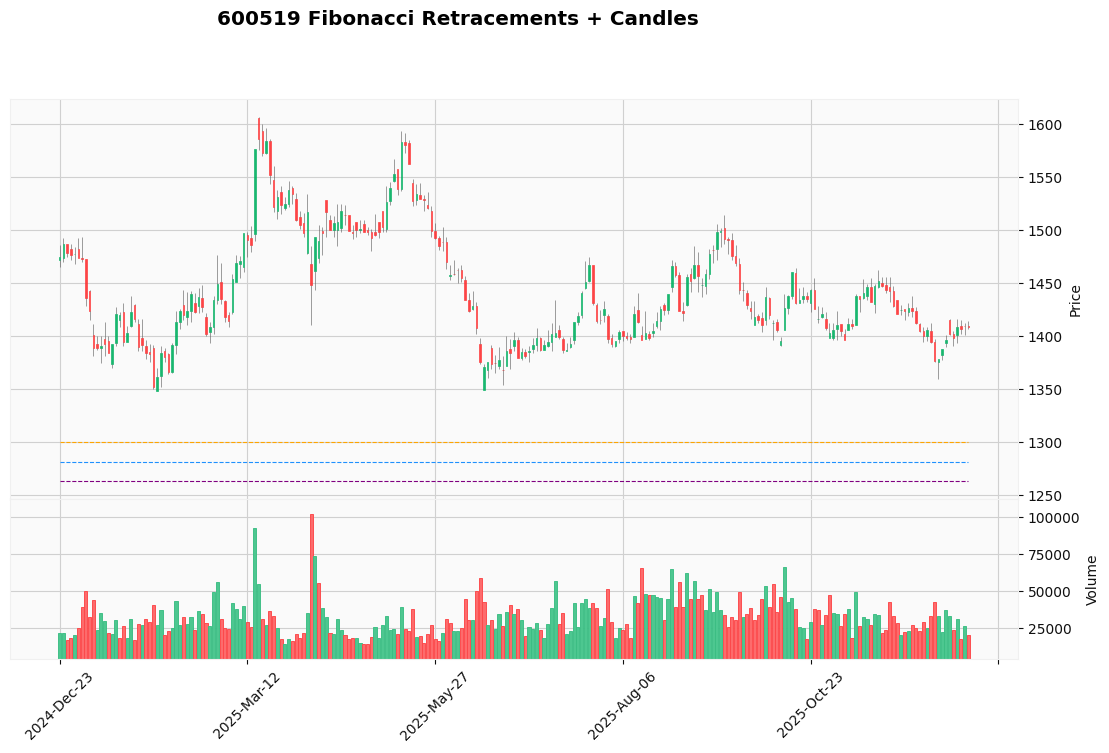

In [29]:
# ========== 1. 拉取数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# ========== 2. 公共字段 ==========
df['Range'] = (df['High'] - df['Low']).replace(0, 1e-6)
df['Body']  = (df['Close'] - df['Open']).abs()
upper_shadow = df["High"] - np.maximum(df["Open"], df["Close"])
lower_shadow = np.minimum(df["Open"], df["Close"]) - df["Low"]

# ========== 3. 简单蜡烛形态：锤子 / 流星 / 刺透 / 看涨吞没 / 看跌吞没 ==========
body_min_pct = 0.5   # 实体占全日波动的最低比例，可按需调

# 锤子线：下影明显长、实体在上半部，整体呈小实体长下影
hammer = (
        (df['Close'] > df['Open']) &  # 阳锤（可放宽）
        (lower_shadow >= 2 * df['Body']) &
        (upper_shadow <= df['Body'])
)

# 流星线：长上影，小实体在下半部
shooting_star = (
        (df['Close'] < df['Open']) &  # 阴流星（可放宽）
        (upper_shadow >= 2 * df['Body']) &
        (lower_shadow <= df['Body'])
)

# 刺透形态：两根K线组合
prev_close = df['Close'].shift(1)
prev_open  = df['Open'].shift(1)

bull_piercing = (
        (prev_close < prev_open) &  # 前一根为阴线
        (df['Open'] < prev_close) & # 第二根低开
        (df['Close'] > (prev_open + prev_close) / 2) &  # 收盘越过前一根实体中点
        (df['Close'] < prev_open)   # 又未完全吞没（典型刺透）
)

# 看涨吞没：前阴后阳，第二根实体包住前一根实体
bull_engulf = (
        (prev_close < prev_open) &
        (df['Close'] > df['Open']) &
        (df['Open'] <= prev_close) &
        (df['Close'] >= prev_open)
)

# 看跌吞没：前阳后阴，第二根实体包住前一根实体
bear_engulf = (
        (prev_close > prev_open) &
        (df['Close'] < df['Open']) &
        (df['Open'] >= prev_close) &
        (df['Close'] <= prev_open)
)

df['Hammer']        = hammer
df['ShootingStar']  = shooting_star
df['BullPiercing']  = bull_piercing
df['BullEngulf']    = bull_engulf
df['BearEngulf']    = bear_engulf

# ========== 4. 选择一段“主趋势波段”，计算斐波回撤 ==========
# 示例：最近 120 根里，找最高点和最低点当作一个大波段。[web:255]
window = 120
sub = df.tail(window)

# 上升波段：用最近 window 内的最低点作为起点、最高点作为终点
low_idx  = sub['Low'].idxmin()
high_idx = sub['High'].idxmax()

if low_idx < high_idx:
    # 上升趋势：从 low_idx → high_idx
    trend_dir = 'up'
    start_price = df.at[low_idx, 'Low']
    end_price   = df.at[high_idx, 'High']
else:
    # 下降趋势：从 high_idx → low_idx
    trend_dir = 'down'
    start_price = df.at[high_idx, 'High']
    end_price   = df.at[low_idx, 'Low']

price_move = end_price - start_price

# 关键回撤位：38.2 / 50 / 61.8
fib_38 = end_price - 0.382 * price_move if trend_dir == 'up' else end_price + 0.382 * price_move
fib_50 = end_price - 0.5   * price_move if trend_dir == 'up' else end_price + 0.5   * price_move
fib_62 = end_price - 0.618 * price_move if trend_dir == 'up' else end_price + 0.618 * price_move

levels = {'38.2%': fib_38, '50%': fib_50, '61.8%': fib_62}

print(f'趋势方向: {trend_dir}, 起点价: {start_price:.2f}, 终点价: {end_price:.2f}')
for name, lvl in levels.items():
    print(f'{name} 回撤位: {lvl:.2f}')

# ========== 5. 在回撤位附近寻找蜡烛反转信号 ==========
tol_pct = 0.004  # 0.4% 容差

df['FibLevel'] = np.nan
df['FibTag']   = ''

for name, lvl in levels.items():
    in_zone = (df['Close'] >= lvl * (1 - tol_pct)) & (df['Close'] <= lvl * (1 + tol_pct))

    if trend_dir == 'up':
        # 回撤下来的支撑候选：在回撤位附近出现看涨信号
        signal = in_zone & (df['Hammer'] | df['BullPiercing'] | df['BullEngulf'])
        df.loc[signal, 'FibLevel'] = lvl
        df.loc[signal, 'FibTag']   = f'{name}_Bull'
    else:
        # 回抽上的阻力候选：在回撤位附近出现看跌信号
        signal = in_zone & (df['ShootingStar'] | df['BearEngulf'])
        df.loc[signal, 'FibLevel'] = lvl
        df.loc[signal, 'FibTag']   = f'{name}_Bear'

# ========== 6. 简单极性转换辅助：看回撤位是否靠近历史支撑/阻力 ==========
# 用 rolling 高低点做一个很粗略的“曾经多次触碰”的价带。[web:247]
lookback_swing = 5
is_swing_low  = (df['Low']  == df['Low'].rolling(lookback_swing*2+1, center=True).min())
is_swing_high = (df['High'] == df['High'].rolling(lookback_swing*2+1, center=True).max())
swing_lows  = df[is_swing_low]['Low']
swing_highs = df[is_swing_high]['High']

def near_past_level(price, series, tol):
    if series.empty:
        return False
    return ((series >= price*(1-tol)) & (series <= price*(1+tol))).any()

df['PolarityHint'] = ''

for i, row in df.iterrows():
    lvl = row['FibLevel']
    if np.isnan(lvl):
        continue
    if near_past_level(lvl, swing_lows, tol_pct):
        df.at[i, 'PolarityHint'] = 'old_support'
    elif near_past_level(lvl, swing_highs, tol_pct):
        df.at[i, 'PolarityHint'] = 'old_resistance'

# ========== 7. 结果输出 ==========
hits = df[~df['FibTag'].eq('')]
print('\n命中的回撤+蜡烛信号：')
print(hits[['Close', 'FibLevel', 'FibTag', 'PolarityHint']].tail(20))

# ========== 8. 可视化 ==========
ap = []

# 画回撤三条水平线
for name, lvl in levels.items():
    ap.append(
        mpf.make_addplot(
            pd.Series(lvl, index=df.index),
            color={'38.2%':'orange','50%':'dodgerblue','61.8%':'purple'}[name],
            linestyle='--',
            width=0.8
        )
    )

# 标记“回撤+蜡烛共振”的点
marks = np.where(~df['FibTag'].eq(''), df['FibLevel'], np.nan)
if not np.all(np.isnan(marks)):
    colors = []
    for tag in df['FibTag']:
        if tag.endswith('Bull'):
            colors.append('seagreen')
        elif tag.endswith('Bear'):
            colors.append('crimson')
        else:
            colors.append('none')
    ap.append(
        mpf.make_addplot(
            marks,
            type='scatter',
            marker='o',
            color=colors,
            markersize=80
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Fibonacci Retracements + Candles',
    figsize=(14, 8)
)


# 简单移动平均线

               SMA_5        SMA_9       SMA_30     SMA_50     SMA_200
Date                                                                 
2025-12-09  1396.504  1407.612222  1420.582667  1422.5548  1449.06100
2025-12-10  1391.244  1402.667778  1419.612667  1421.6624  1448.83800
2025-12-11  1388.846  1398.388889  1419.121000  1421.0622  1448.58095
2025-12-12  1386.974  1395.350000  1418.809000  1420.6952  1448.45220
2025-12-15  1388.530  1394.235556  1418.509000  1420.5152  1448.27915
2025-12-16  1392.728  1393.446667  1418.275667  1419.7380  1448.13180
2025-12-17  1398.788  1394.460000  1418.709667  1419.5202  1448.16530
2025-12-18  1402.590  1394.570000  1418.572000  1419.4046  1448.15825
2025-12-19  1405.252  1396.318889  1418.593000  1419.4838  1448.03825
2025-12-22  1406.496  1399.786667  1417.590333  1419.7442  1447.83340


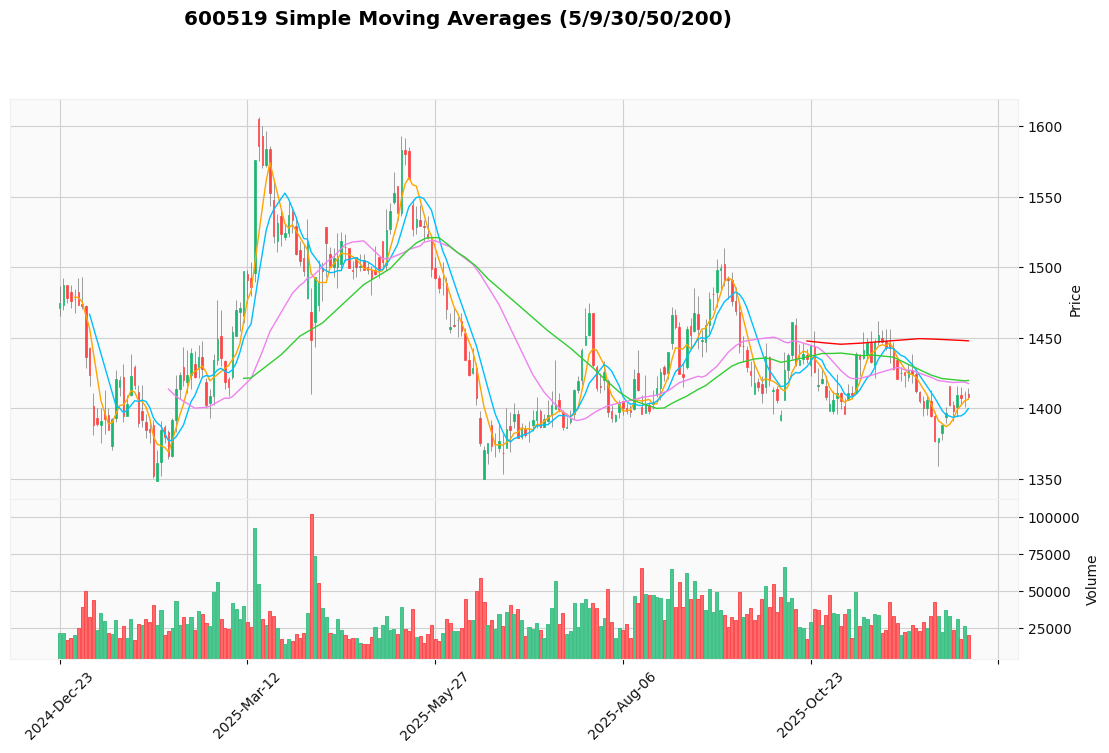

In [30]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

# 整理成英文列 + Date 索引
df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# ========== 2. 计算简单移动平均线（SMA） ==========
# SMA_n = 最近 n 个收盘价的算术平均。[web:216]

ma_periods = [5, 9, 30, 50, 200]

for n in ma_periods:
    df[f'SMA_{n}'] = df['Close'].rolling(n).mean()

# ========== 3. 打印最近几天的均线值方便检查 ==========
print(df[[f'SMA_{n}' for n in ma_periods]].tail(10))

# ========== 4. 使用 mplfinance 画 K 线 + 多条 SMA ==========
ap = []

colors = {
    5:   'orange',
    9:   'deepskyblue',
    30:  'violet',
    50:  'limegreen',
    200: 'red'
}

for n in ma_periods:
    ap.append(
        mpf.make_addplot(
            df[f'SMA_{n}'],
            color=colors[n],
            width=1
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Simple Moving Averages (5/9/30/50/200)',
    figsize=(14, 8)
)


# 同时计算 SMA / WMA / EMA

               SMA_5        WMA_5        EMA_5
Date                                          
2025-12-09  1396.504  1392.374667  1395.147365
2025-12-10  1391.244  1386.486667  1389.711577
2025-12-11  1388.846  1385.415333  1389.151051
2025-12-12  1386.974  1388.030000  1391.664034
2025-12-15  1388.530  1393.052000  1395.122689
2025-12-16  1392.728  1396.222000  1396.095126
2025-12-17  1398.788  1401.692667  1400.443418
2025-12-18  1402.590  1404.443333  1402.642278
2025-12-19  1405.252  1406.913333  1405.094852
2025-12-22  1406.496  1407.916000  1406.149901

黄金交叉次数: 7
死亡交叉次数: 8


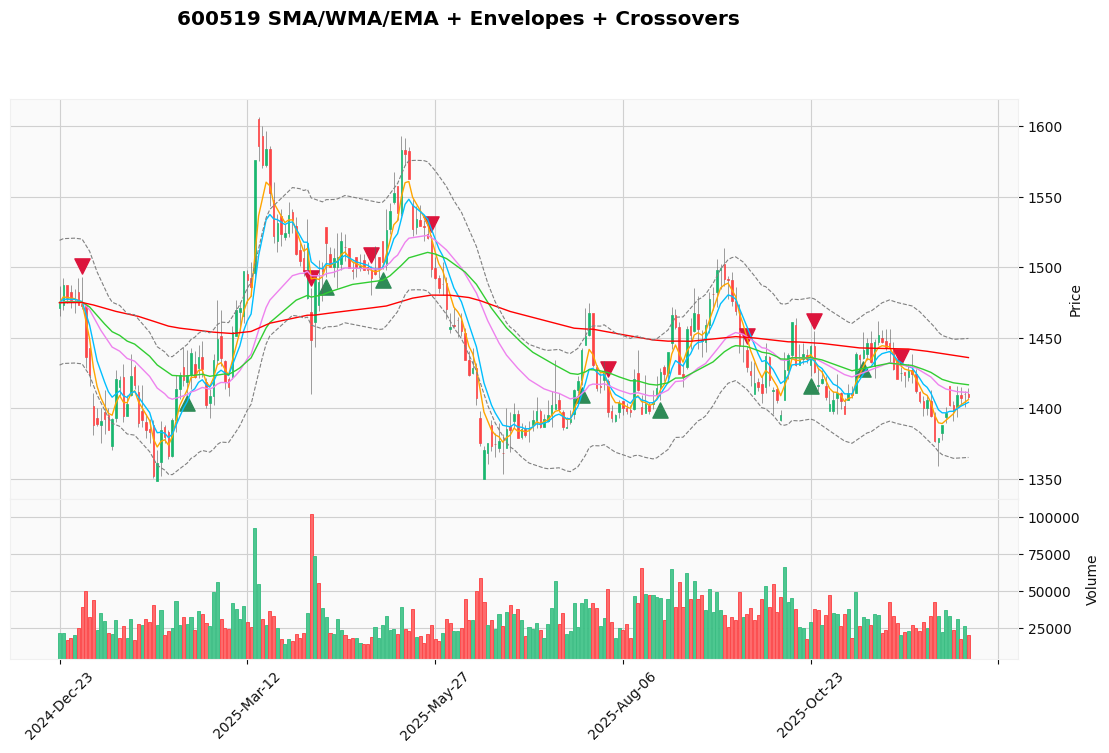

In [31]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

close = df['Close']

# ========== 2. 简单移动平均线（SMA） ==========
def sma(series, n):
    return series.rolling(n).mean()

# ========== 3. 加权移动平均线（WMA：线性权重） ==========
# 例如 5 日 WMA 的权重为 1,2,3,4,5，再除以权重和。[web:241][web:245]
def wma(series, n):
    weights = np.arange(1, n+1)
    return series.rolling(n).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

# ========== 4. 指数加权移动平均线（EMA） ==========
# EMA_t = α*P_t + (1-α)*EMA_{t-1}, α = 2/(n+1) 是常见选择。[web:216]
def ema(series, n):
    return series.ewm(span=n, adjust=False).mean()

# 选几组常用周期：短期 5/9，中期 30/50，长期 200
periods = [5, 9, 30, 50, 200]

for n in periods:
    df[f'SMA_{n}'] = sma(close, n)
    df[f'WMA_{n}'] = wma(close, n)
    df[f'EMA_{n}'] = ema(close, n)

print(df[[f'SMA_{5}', f'WMA_{5}', f'EMA_{5}']].tail(10))

# ========== 5. 均线包络线（Envelope） ==========
# 例如对 20 日 EMA 上下各平移 3%，构成支撑/阻力带。[web:216]
base_n = 20
df[f'EMA_{base_n}'] = ema(close, base_n)
env_pct = 0.03   # ±3%

df['Env_Upper'] = df[f'EMA_{base_n}'] * (1 + env_pct)
df['Env_Lower'] = df[f'EMA_{base_n}'] * (1 - env_pct)

# ========== 6. 双均线黄金/死亡交叉信号 ==========
short_n = 5
long_n  = 30

short_ma = df[f'EMA_{short_n}']
long_ma  = df[f'EMA_{long_n}']

# 黄金交叉：短期从下向上穿越长期
golden_cross = (short_ma.shift(1) < long_ma.shift(1)) & (short_ma > long_ma)
# 死亡交叉：短期从上向下穿越长期
death_cross  = (short_ma.shift(1) > long_ma.shift(1)) & (short_ma < long_ma)

df['GoldenCross'] = golden_cross
df['DeathCross']  = death_cross

print(f"\n黄金交叉次数: {int(golden_cross.sum())}")
print(f"死亡交叉次数: {int(death_cross.sum())}")

# ========== 7. 可视化：K 线 + EMA/包络线 + 交叉点 ==========
ap = []

# 画短/中/长期 EMA
colors_ema = {5: 'orange', 9: 'deepskyblue', 30: 'violet', 50: 'limegreen', 200: 'red'}
for n in periods:
    ap.append(
        mpf.make_addplot(
            df[f'EMA_{n}'],
            color=colors_ema[n],
            width=1
        )
    )

# 画 20 日 EMA 包络线
ap.append(
    mpf.make_addplot(
        df['Env_Upper'],
        color='gray',
        linestyle='--',
        width=0.8
    )
)
ap.append(
    mpf.make_addplot(
        df['Env_Lower'],
        color='gray',
        linestyle='--',
        width=0.8
    )
)

# 黄金交叉（绿色三角）、死亡交叉（红色倒三角）
gold_marks = np.where(df['GoldenCross'], df['Low'] * 0.995, np.nan)
dead_marks = np.where(df['DeathCross'],  df['High'] * 1.005, np.nan)

if not np.all(np.isnan(gold_marks)):
    ap.append(
        mpf.make_addplot(
            gold_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

if not np.all(np.isnan(dead_marks)):
    ap.append(
        mpf.make_addplot(
            dead_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} SMA/WMA/EMA + Envelopes + Crossovers',
    figsize=(14, 8)
)


# 相对力度指数

顶背离点数: 1
底背离点数: 1

顶部信号（最近几条）：
Empty DataFrame
Columns: [Close, RSI]
Index: []

底部信号（最近几条）：
Empty DataFrame
Columns: [Close, RSI]
Index: []


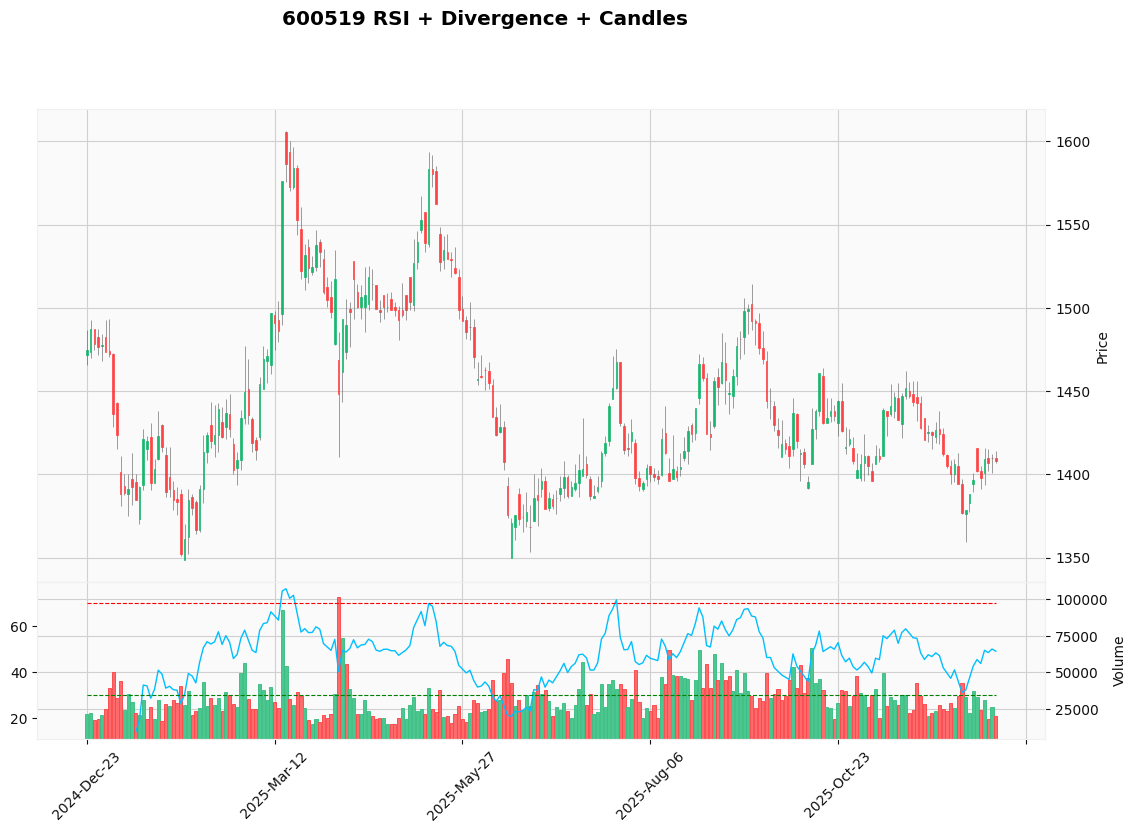

In [32]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

close = df['Close']

# ========== 2. 计算 RSI ==========
# 经典 14 日 RSI 公式。[web:216]
def calc_rsi(series, period=14):
    delta = series.diff()
    gain  = np.where(delta > 0, delta, 0.0)
    loss  = np.where(delta < 0, -delta, 0.0)

    gain_series = pd.Series(gain, index=series.index)
    loss_series = pd.Series(loss, index=series.index)

    # 初始平均涨跌
    avg_gain = gain_series.rolling(period).mean()
    avg_loss = loss_series.rolling(period).mean()

    # 之后使用 Wilder 平滑方法
    for i in range(period, len(series)):
        if i == period:
            # rolling 已经给出初始值
            continue
        avg_gain.iloc[i] = (avg_gain.iloc[i-1]*(period-1) + gain_series.iloc[i]) / period
        avg_loss.iloc[i] = (avg_loss.iloc[i-1]*(period-1) + loss_series.iloc[i]) / period

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - 100 / (1 + rs)
    return rsi

rsi_period = 14
df['RSI'] = calc_rsi(close, rsi_period)

# ========== 3. 超买 / 超卖 区域 ==========
overbought = 70
oversold   = 30
df['RSI_OverBought'] = df['RSI'] > overbought
df['RSI_OverSold']   = df['RSI'] < oversold

# ========== 4. 简单蜡烛形态：乌云盖顶 / 看涨吞没 / 锤子等 ==========
body = (df['Close'] - df['Open']).abs()
upper_shadow = df['High'] - np.maximum(df['Open'], df['Close'])
lower_shadow = np.minimum(df['Open'], df['Close']) - df['Low']
rng = (df['High'] - df['Low']).replace(0, 1e-6)

prev_open  = df['Open'].shift(1)
prev_close = df['Close'].shift(1)

# 乌云盖顶（简化版）：前一根长阳，本根高开后收盘跌破前一根实体中点但未完全吞没
cloud_cover = (
        (prev_close > prev_open) &
        (df['Open'] > prev_close) &
        (df['Close'] < (prev_open + prev_close) / 2) &
        (df['Close'] > prev_open)
)

# 看涨吞没：前阴后阳，第二根实体完全包住前一根实体
bull_engulf = (
        (prev_close < prev_open) &
        (df['Close'] > df['Open']) &
        (df['Open'] <= prev_close) &
        (df['Close'] >= prev_open)
)

# 锤子线：小实体 + 长下影
hammer = (
        (df['Close'] >= df['Open']) &
        (lower_shadow >= 2 * body) &
        (upper_shadow <= body)
)

df['CloudCover'] = cloud_cover
df['BullEngulf'] = bull_engulf
df['Hammer']     = hammer

# ========== 5. 顶背离 / 底背离 检测 ==========
# 简单做法：以 swing 高/低 为节点，对比相邻两个 swing 在价格和 RSI 上的高低。[web:255]

lookback_swing = 5

# swing high / low
is_swing_high = (df['High'] == df['High'].rolling(lookback_swing*2+1, center=True).max())
is_swing_low  = (df['Low']  == df['Low'].rolling(lookback_swing*2+1, center=True).min())

swing_highs = df[is_swing_high][['High', 'RSI']]
swing_lows  = df[is_swing_low][['Low', 'RSI']]

df['RSI_TopDiv']  = False  # 顶背离
df['RSI_BotDiv']  = False  # 底背离

# 顶背离：新高价 + RSI 未创新高或更低
prev_idx = None
for idx, row in swing_highs.iterrows():
    if prev_idx is not None:
        prev_price, prev_rsi = swing_highs.loc[prev_idx, 'High'], swing_highs.loc[prev_idx, 'RSI']
        cur_price,  cur_rsi  = row['High'], row['RSI']
        if (cur_price > prev_price) and (cur_rsi <= prev_rsi):
            df.at[idx, 'RSI_TopDiv'] = True
    prev_idx = idx

# 底背离：新低价 + RSI 未创新低或更高
prev_idx = None
for idx, row in swing_lows.iterrows():
    if prev_idx is not None:
        prev_price, prev_rsi = swing_lows.loc[prev_idx, 'Low'], swing_lows.loc[prev_idx, 'RSI']
        cur_price,  cur_rsi  = row['Low'], row['RSI']
        if (cur_price < prev_price) and (cur_rsi >= prev_rsi):
            df.at[idx, 'RSI_BotDiv'] = True
    prev_idx = idx

print(f"顶背离点数: {int(df['RSI_TopDiv'].sum())}")
print(f"底背离点数: {int(df['RSI_BotDiv'].sum())}")

# ========== 6. RSI + 蜡烛图共振信号 ==========
# 顶部信号：RSI 超买 + 顶背离 + 看跌蜡烛（乌云盖顶）
df['TopSignal'] = df['RSI_OverBought'] & df['RSI_TopDiv'] & df['CloudCover']

# 底部信号：RSI 超卖 + 底背离 + 看涨蜡烛（锤子或看涨吞没）
df['BottomSignal'] = df['RSI_OverSold'] & df['RSI_BotDiv'] & (df['Hammer'] | df['BullEngulf'])

print("\n顶部信号（最近几条）：")
print(df[df['TopSignal']][['Close', 'RSI']].tail())

print("\n底部信号（最近几条）：")
print(df[df['BottomSignal']][['Close', 'RSI']].tail())

# ========== 7. 可视化：K 线 + RSI + 顶/底信号 ==========
# 主图 K 线上打标，副图画 RSI

# 主图 addplot 列表
ap = []

# 顶部信号：红色倒三角
top_marks = np.where(df['TopSignal'], df['High'] * 1.01, np.nan)
if not np.all(np.isnan(top_marks)):
    ap.append(
        mpf.make_addplot(
            top_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )

# 底部信号：绿色三角
bottom_marks = np.where(df['BottomSignal'], df['Low'] * 0.99, np.nan)
if not np.all(np.isnan(bottom_marks)):
    ap.append(
        mpf.make_addplot(
            bottom_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

# RSI 副图
ap.append(
    mpf.make_addplot(
        df['RSI'],
        panel=1,
        color='deepskyblue',
        width=1
    )
)

# 超买/超卖水平线
ap.append(
    mpf.make_addplot(
        pd.Series(overbought, index=df.index),
        panel=1,
        color='red',
        linestyle='--',
        width=0.8
    )
)
ap.append(
    mpf.make_addplot(
        pd.Series(oversold, index=df.index),
        panel=1,
        color='green',
        linestyle='--',
        width=0.8
    )
)

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} RSI + Divergence + Candles',
    figsize=(14, 9),
    panel_ratios=(3, 1)  # 主图:RSI 图 高度比例
)


# 移动平均线摆动指数

顶背离点数: 0
底背离点数: 1

顶部信号（最近几条）：
Empty DataFrame
Columns: [Close, MA_Osc]
Index: []

底部信号（最近几条）：
Empty DataFrame
Columns: [Close, MA_Osc]
Index: []


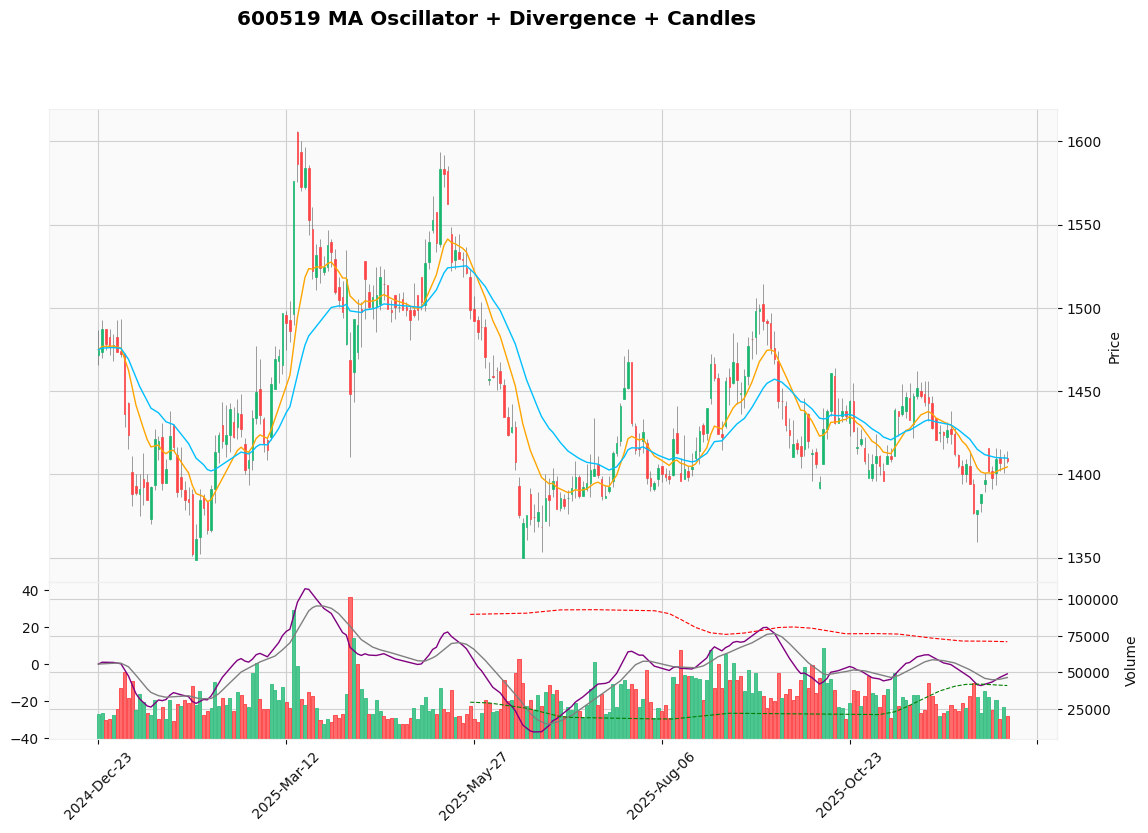

In [33]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

close = df['Close']

# ========== 2. 计算短期 / 长期 EMA 以及“移动平均线摆动指数” ==========
# 典型组合类似 MACD：短期 12、长期 26，也可以用 5 / 30、9 / 30 等。[web:216]
def ema(series, n):
    return series.ewm(span=n, adjust=False).mean()

short_n = 12
long_n  = 26

df[f'EMA_{short_n}'] = ema(close, short_n)
df[f'EMA_{long_n}']  = ema(close, long_n)

# 移动平均线摆动指数 = 短期 MA - 长期 MA
df['MA_Osc'] = df[f'EMA_{short_n}'] - df[f'EMA_{long_n}']

# 平滑一下摆动指数，类似 MACD 的 signal 线（可选）
signal_n = 9
df['MA_Osc_Sig'] = df['MA_Osc'].ewm(span=signal_n, adjust=False).mean()

# ========== 3. 超买 / 超卖区（对摆动指数设阈值） ==========
# 简单做法：用历史标准差的倍数作阈值。[web:255]
osc_mean = df['MA_Osc'].rolling(100).mean()
osc_std  = df['MA_Osc'].rolling(100).std()

k = 1.5  # 超买/超卖阈值倍数
df['Osc_Upper'] = osc_mean + k * osc_std
df['Osc_Lower'] = osc_mean - k * osc_std

df['Osc_OverBought'] = df['MA_Osc'] > df['Osc_Upper']
df['Osc_OverSold']   = df['MA_Osc'] < df['Osc_Lower']

# ========== 4. 简单蜡烛形态：看跌/看涨吞没、锤子、上吊线 ==========
body = (df['Close'] - df['Open']).abs()
upper_shadow = df['High'] - np.maximum(df['Open'], df['Close'])
lower_shadow = np.minimum(df['Open'], df['Close']) - df['Low']
rng = (df['High'] - df['Low']).replace(0, 1e-6)

prev_open  = df['Open'].shift(1)
prev_close = df['Close'].shift(1)

# 看跌吞没
bear_engulf = (
        (prev_close > prev_open) &
        (df['Close'] < df['Open']) &
        (df['Open'] >= prev_close) &
        (df['Close'] <= prev_open)
)

# 看涨吞没
bull_engulf = (
        (prev_close < prev_open) &
        (df['Close'] > df['Open']) &
        (df['Open'] <= prev_close) &
        (df['Close'] >= prev_open)
)

# 锤子线（底部）：小实体 + 长下影
hammer = (
        (df['Close'] >= df['Open']) &
        (lower_shadow >= 2 * body) &
        (upper_shadow <= body)
)

# 上吊线（顶部）：小实体 + 长下影，出现在高位
hanging_man = (
        (df['Close'] <= df['Open']) &
        (lower_shadow >= 2 * body) &
        (upper_shadow <= body)
)

df['BearEngulf'] = bear_engulf
df['BullEngulf'] = bull_engulf
df['Hammer']     = hammer
df['Hanging']    = hanging_man

# ========== 5. 顶/底背离：价格和摆动指数的相互背离 ==========
lookback_swing = 5

is_swing_high = (df['High'] == df['High'].rolling(lookback_swing*2+1, center=True).max())
is_swing_low  = (df['Low']  == df['Low'].rolling(lookback_swing*2+1, center=True).min())

swing_highs = df[is_swing_high][['High', 'MA_Osc']]
swing_lows  = df[is_swing_low][['Low', 'MA_Osc']]

df['Osc_TopDiv'] = False
df['Osc_BotDiv'] = False

# 顶背离：价格创新高，Osc 未创新高或更低
prev_idx = None
for idx, row in swing_highs.iterrows():
    if prev_idx is not None:
        prev_p, prev_o = swing_highs.loc[prev_idx, 'High'], swing_highs.loc[prev_idx, 'MA_Osc']
        cur_p,  cur_o  = row['High'], row['MA_Osc']
        if (cur_p > prev_p) and (cur_o <= prev_o):
            df.at[idx, 'Osc_TopDiv'] = True
    prev_idx = idx

# 底背离：价格创新低，Osc 未创新低或更高
prev_idx = None
for idx, row in swing_lows.iterrows():
    if prev_idx is not None:
        prev_p, prev_o = swing_lows.loc[prev_idx, 'Low'], swing_lows.loc[prev_idx, 'MA_Osc']
        cur_p,  cur_o  = row['Low'], row['MA_Osc']
        if (cur_p < prev_p) and (cur_o >= prev_o):
            df.at[idx, 'Osc_BotDiv'] = True
    prev_idx = idx

print(f"顶背离点数: {int(df['Osc_TopDiv'].sum())}")
print(f"底背离点数: {int(df['Osc_BotDiv'].sum())}")

# ========== 6. 共振信号：摆动指数 + 蜡烛形态 ==========
# 顶部：超买 + 顶背离 + 看跌蜡烛（看跌吞没 或 上吊线）
df['TopSignal'] = (
        df['Osc_OverBought'] &
        df['Osc_TopDiv'] &
        (df['BearEngulf'] | df['Hanging'])
)

# 底部：超卖 + 底背离 + 看涨蜡烛（看涨吞没 或 锤子）
df['BottomSignal'] = (
        df['Osc_OverSold'] &
        df['Osc_BotDiv'] &
        (df['BullEngulf'] | df['Hammer'])
)

print("\n顶部信号（最近几条）：")
print(df[df['TopSignal']][['Close', 'MA_Osc']].tail())

print("\n底部信号（最近几条）：")
print(df[df['BottomSignal']][['Close', 'MA_Osc']].tail())

# ========== 7. 可视化：主图 K 线 + EMA，副图画摆动指数 ==========
ap = []

# 画短/长 EMA
ap.append(
    mpf.make_addplot(df[f'EMA_{short_n}'], color='orange', width=1)
)
ap.append(
    mpf.make_addplot(df[f'EMA_{long_n}'], color='deepskyblue', width=1)
)

# 顶/底信号在主图标记
top_marks = np.where(df['TopSignal'], df['High'] * 1.01, np.nan)
bot_marks = np.where(df['BottomSignal'], df['Low']  * 0.99, np.nan)

if not np.all(np.isnan(top_marks)):
    ap.append(
        mpf.make_addplot(
            top_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )

if not np.all(np.isnan(bot_marks)):
    ap.append(
        mpf.make_addplot(
            bot_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

# 副图：摆动指数 + 阈值
ap.append(
    mpf.make_addplot(
        df['MA_Osc'],
        panel=1,
        color='purple',
        width=1
    )
)
ap.append(
    mpf.make_addplot(
        df['MA_Osc_Sig'],
        panel=1,
        color='gray',
        width=1
    )
)
ap.append(
    mpf.make_addplot(
        df['Osc_Upper'],
        panel=1,
        color='red',
        linestyle='--',
        width=0.8
    )
)
ap.append(
    mpf.make_addplot(
        df['Osc_Lower'],
        panel=1,
        color='green',
        linestyle='--',
        width=0.8
    )
)

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} MA Oscillator + Divergence + Candles',
    figsize=(14, 9),
    panel_ratios=(3, 1)
)


# 随机指数

随机指标金叉次数: 25
随机指标死叉次数: 25

顶部共振信号（最近几条）：
              Close         %K         %D
Date                                     
2025-09-12  1492.04  87.343877  90.421698

底部共振信号（最近几条）：
Empty DataFrame
Columns: [Close, %K, %D]
Index: []


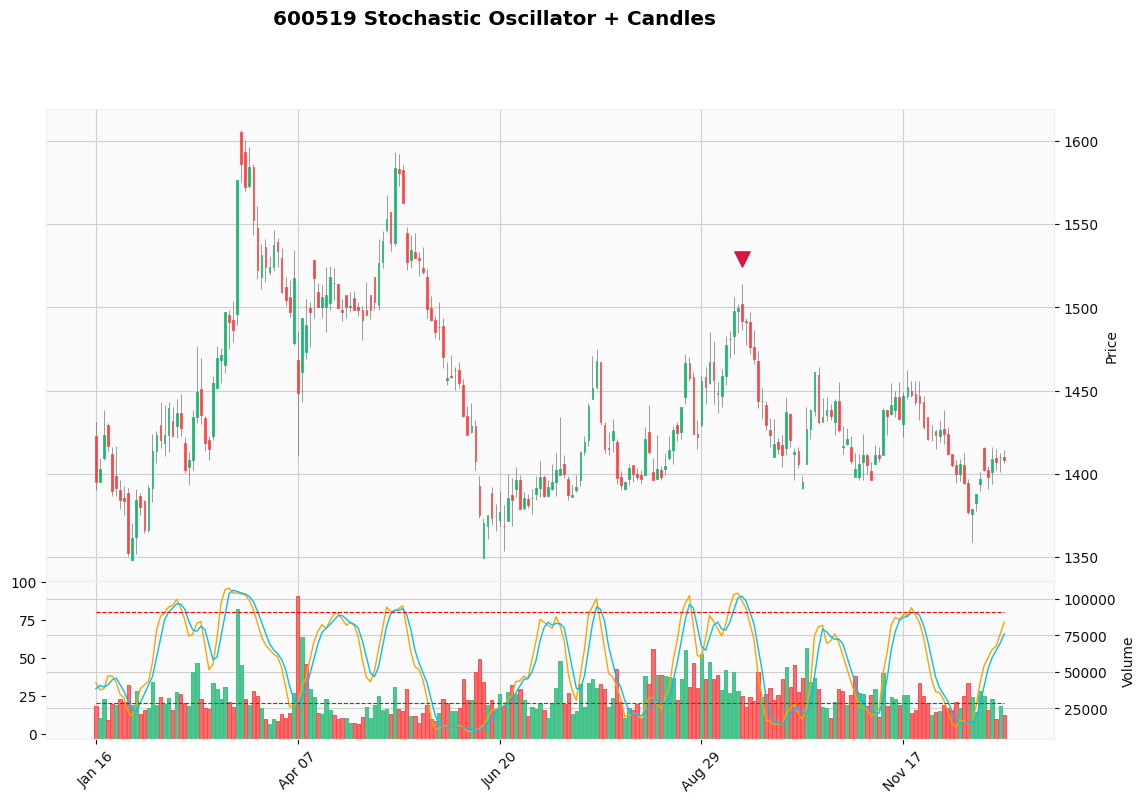

In [34]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

high = df['High']
low  = df['Low']
close = df['Close']

# ========== 2. 计算随机指标：快%K、慢%K、%D ==========
# 快%K = (C - N日最低) / (N日最高 - N日最低) * 100。[web:216]
n_k = 14   # 随机指标窗口（可改成 14/19/21 等）

lowest_low  = low.rolling(n_k).min()
highest_high = high.rolling(n_k).max()

fast_k = (close - lowest_low) / (highest_high - lowest_low) * 100

# 慢%K = 快%K 的 3 期简单移动平均
slow_k = fast_k.rolling(3).mean()

# %D = 慢%K 的再 3 期移动平均
d_line = slow_k.rolling(3).mean()

df['%K_fast'] = fast_k
df['%K']      = slow_k
df['%D']      = d_line

# 丢掉起始 NaN
df = df.dropna()

# ========== 3. 超买 / 超卖与金叉 / 死叉 ==========
overbought = 80
oversold   = 20

df['OverBought'] = df['%D'] >= overbought
df['OverSold']   = df['%D'] <= oversold

# 金叉：慢%K 上穿 %D；死叉：慢%K 下穿 %D。[web:216]
k_prev = df['%K'].shift(1)
d_prev = df['%D'].shift(1)

df['BullCross'] = (k_prev < d_prev) & (df['%K'] > df['%D'])
df['BearCross'] = (k_prev > d_prev) & (df['%K'] < df['%D'])

print(f"随机指标金叉次数: {int(df['BullCross'].sum())}")
print(f"随机指标死叉次数: {int(df['BearCross'].sum())}")

# ========== 4. 简单蜡烛形态：看跌吞没 & 锤子线 ==========
body = (df['Close'] - df['Open']).abs()
upper_shadow = df['High'] - np.maximum(df['Open'], df['Close'])
lower_shadow = np.minimum(df['Open'], df['Close']) - df['Low']

prev_open  = df['Open'].shift(1)
prev_close = df['Close'].shift(1)

# 看跌吞没：前阳后阴，第二根实体包住前一根实体
bear_engulf = (
        (prev_close > prev_open) &
        (df['Close'] < df['Open']) &
        (df['Open'] >= prev_close) &
        (df['Close'] <= prev_open)
)

# 锤子线：小实体 + 下影显著长
hammer = (
        (df['Close'] >= df['Open']) &
        (lower_shadow >= 2 * body) &
        (upper_shadow <= body)
)

df['BearEngulf'] = bear_engulf
df['Hammer']     = hammer

# ========== 5. 随机指标 + 蜡烛共振信号 ==========
# 顶部信号：超买 + 死叉 + 看跌吞没
df['TopSignal'] = df['OverBought'] & df['BearCross'] & df['BearEngulf']

# 底部信号：超卖 + 金叉 + 锤子线
df['BottomSignal'] = df['OverSold'] & df['BullCross'] & df['Hammer']

print("\n顶部共振信号（最近几条）：")
print(df[df['TopSignal']][['Close', '%K', '%D']].tail())

print("\n底部共振信号（最近几条）：")
print(df[df['BottomSignal']][['Close', '%K', '%D']].tail())

# ========== 6. 可视化：主图 K 线 + 随机指标副图 ==========
ap = []

# 主图标记顶部/底部信号
top_marks = np.where(df['TopSignal'], df['High'] * 1.01, np.nan)
bot_marks = np.where(df['BottomSignal'], df['Low'] * 0.99, np.nan)

if not np.all(np.isnan(top_marks)):
    ap.append(
        mpf.make_addplot(
            top_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )

if not np.all(np.isnan(bot_marks)):
    ap.append(
        mpf.make_addplot(
            bot_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

# 副图：%K 与 %D
ap.append(
    mpf.make_addplot(
        df['%K'],
        panel=1,
        color='orange',
        width=1
    )
)
ap.append(
    mpf.make_addplot(
        df['%D'],
        panel=1,
        color='deepskyblue',
        width=1
    )
)

# 超买/超卖水平线
ap.append(
    mpf.make_addplot(
        pd.Series(overbought, index=df.index),
        panel=1,
        color='red',
        linestyle='--',
        width=0.8
    )
)
ap.append(
    mpf.make_addplot(
        pd.Series(oversold, index=df.index),
        panel=1,
        color='green',
        linestyle='--',
        width=0.8
    )
)

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Stochastic Oscillator + Candles',
    figsize=(14, 9),
    panel_ratios=(3, 1)
)


# 移动平均线验证背离指数（MACD）

MACD 金叉次数: 8
MACD 死叉次数: 8

顶部信号（最近几条）：
Empty DataFrame
Columns: [Close, MACD, MACD_Sig]
Index: []

底部信号（最近几条）：
              Close       MACD   MACD_Sig
Date                                     
2025-02-12  1391.44 -17.271288 -18.601202
2025-05-08  1526.63   2.172016   1.603011


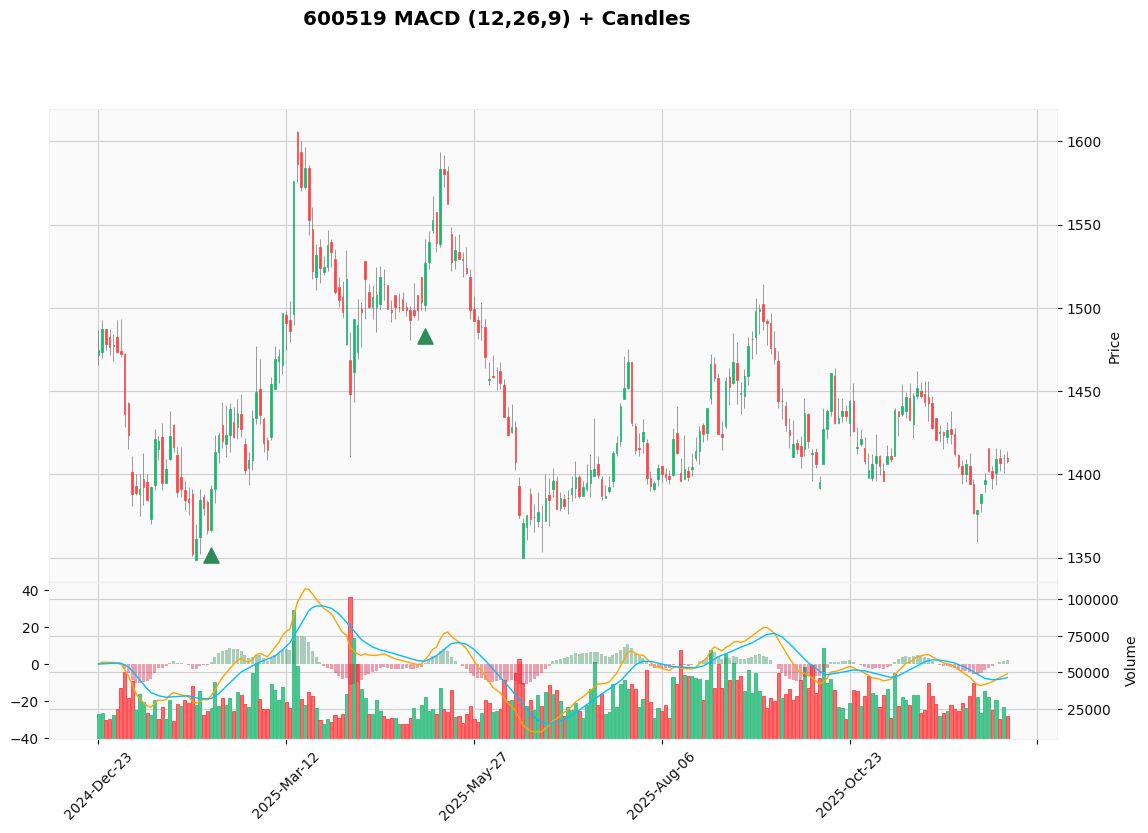

In [35]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

close = df['Close']

# ========== 2. 计算 MACD：12 / 26 / 9 ==========
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

short_n = 12
long_n  = 26
signal_n = 9

df['EMA_12'] = ema(close, short_n)
df['EMA_26'] = ema(close, long_n)

# MACD 主线（DIF）
df['MACD'] = df['EMA_12'] - df['EMA_26']

# 信号线（DEA）
df['MACD_Sig'] = ema(df['MACD'], signal_n)

# 柱状图（可选）
df['MACD_Hist'] = df['MACD'] - df['MACD_Sig']

# ========== 3. MACD 金叉 / 死叉 ==========
macd_prev = df['MACD'].shift(1)
sig_prev  = df['MACD_Sig'].shift(1)

df['MACD_BullCross'] = (macd_prev < sig_prev) & (df['MACD'] > df['MACD_Sig'])
df['MACD_BearCross'] = (macd_prev > sig_prev) & (df['MACD'] < df['MACD_Sig'])

print(f"MACD 金叉次数: {int(df['MACD_BullCross'].sum())}")
print(f"MACD 死叉次数: {int(df['MACD_BearCross'].sum())}")

# ========== 4. 简单蜡烛形态：乌云盖顶 / 看涨吞没 ==========
body = (df['Close'] - df['Open']).abs()
upper_shadow = df['High'] - np.maximum(df['Open'], df['Close'])
lower_shadow = np.minimum(df['Open'], df['Close']) - df['Low']

prev_open  = df['Open'].shift(1)
prev_close = df['Close'].shift(1)

# 乌云盖顶（简化版）：前一根长阳，第二根高开后收盘跌破前一根实体中点但未完全吞没
cloud_cover = (
        (prev_close > prev_open) &
        (prev_close - prev_open > body.rolling(20).mean()) &   # 前一根尽量偏长（可选）
        (df['Open'] > prev_close) &
        (df['Close'] < (prev_open + prev_close) / 2) &
        (df['Close'] > prev_open)
)

# 看涨吞没
bull_engulf = (
        (prev_close < prev_open) &
        (df['Close'] > df['Open']) &
        (df['Open'] <= prev_close) &
        (df['Close'] >= prev_open)
)

df['CloudCover'] = cloud_cover
df['BullEngulf'] = bull_engulf

# ========== 5. MACD + 蜡烛共振信号 ==========
# 顶部：乌云盖顶 + MACD 死叉
df['TopSignal'] = df['CloudCover'] & df['MACD_BearCross']

# 底部：看涨吞没 + MACD 金叉
df['BottomSignal'] = df['BullEngulf'] & df['MACD_BullCross']

print("\n顶部信号（最近几条）：")
print(df[df['TopSignal']][['Close', 'MACD', 'MACD_Sig']].tail())

print("\n底部信号（最近几条）：")
print(df[df['BottomSignal']][['Close', 'MACD', 'MACD_Sig']].tail())

# ========== 6. 可视化：主图 K 线 + MACD 副图 ==========
ap = []

# 主图：标记顶部/底部信号
top_marks = np.where(df['TopSignal'], df['High'] * 1.01, np.nan)
bot_marks = np.where(df['BottomSignal'], df['Low'] * 0.99, np.nan)

if not np.all(np.isnan(top_marks)):
    ap.append(
        mpf.make_addplot(
            top_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )

if not np.all(np.isnan(bot_marks)):
    ap.append(
        mpf.make_addplot(
            bot_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

# 副图：MACD 主线 / 信号线 / 柱状图
ap.append(
    mpf.make_addplot(
        df['MACD'],
        panel=1,
        color='orange',
        width=1
    )
)
ap.append(
    mpf.make_addplot(
        df['MACD_Sig'],
        panel=1,
        color='deepskyblue',
        width=1
    )
)
ap.append(
    mpf.make_addplot(
        df['MACD_Hist'],
        panel=1,
        type='bar',
        color=['seagreen' if v >= 0 else 'crimson' for v in df['MACD_Hist']],
        alpha=0.4
    )
)

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} MACD (12,26,9) + Candles',
    figsize=(14, 9),
    panel_ratios=(3, 1)
)


# 交易量

放量锤子线： 0
放量十字线： 0
放量看涨吞没： 7
放量看跌吞没： 6
放量向上缺口： 2
放量向下缺口： 3


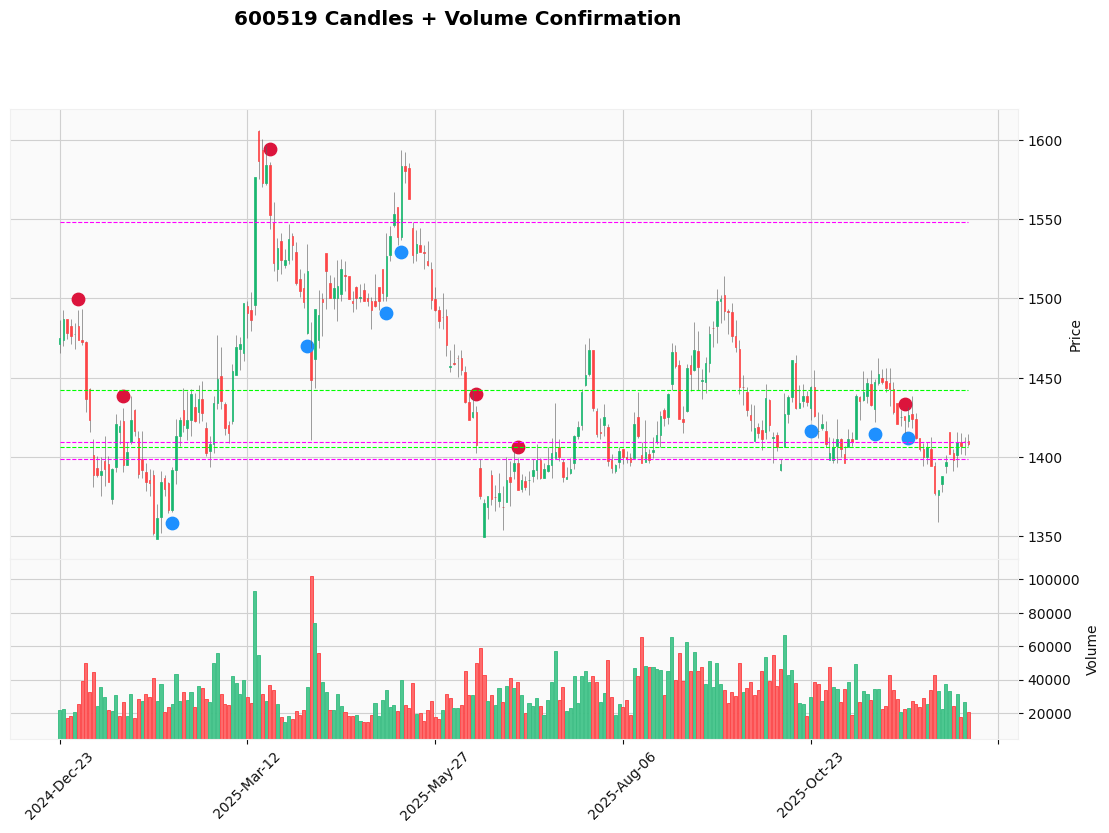

In [36]:
# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# ========== 2. 基础字段 ==========
df['Range'] = (df['High'] - df['Low']).replace(0, 1e-6)
df['Body']  = (df['Close'] - df['Open']).abs()
upper_shadow = df['High'] - np.maximum(df['Open'], df['Close'])
lower_shadow = np.minimum(df['Open'], df['Close']) - df['Low']

prev_open  = df['Open'].shift(1)
prev_close = df['Close'].shift(1)
prev_high  = df['High'].shift(1)
prev_low   = df['Low'].shift(1)

# 相对交易量：与过去 N 日平均比较
vol_n = 20
df['Vol_MA'] = df['Volume'].rolling(vol_n).mean()
df['Vol_Ratio'] = df['Volume'] / df['Vol_MA']   # >1 表示放量

# ========== 3. 蜡烛形态 ==========
# 3.1 锤子线（底部）：小实体 + 长下影
hammer = (
        (df['Close'] >= df['Open']) &
        (lower_shadow >= 2 * df['Body']) &
        (upper_shadow <= df['Body'])
)

# 3.2 十字线：开收接近
doji = (df['Body'] <= 0.1 * df['Range'])

# 3.3 看涨吞没
bull_engulf = (
        (prev_close < prev_open) &
        (df['Close'] > df['Open']) &
        (df['Open'] <= prev_close) &
        (df['Close'] >= prev_open)
)

# 3.4 看跌吞没
bear_engulf = (
        (prev_close > prev_open) &
        (df['Close'] < df['Open']) &
        (df['Open'] >= prev_close) &
        (df['Close'] <= prev_open)
)

# 3.5 向上/向下窗口（缺口）
gap_up = (df['Low'] > prev_high)
gap_down = (df['High'] < prev_low)

df['Hammer']      = hammer
df['Doji']        = doji
df['BullEngulf']  = bull_engulf
df['BearEngulf']  = bear_engulf
df['GapUp']       = gap_up
df['GapDown']     = gap_down

# ========== 4. 放量条件 ==========
# 用 Vol_Ratio > 1.5 作为“异常放大”的简单标准，可按需调整。[web:216]
vol_thr = 1.5
df['Vol_High'] = df['Vol_Ratio'] >= vol_thr

# 针对双K形态，按书中思路分别比较前后两根的量：
# 看涨吞没：前黑量 < 后白量
df['BullEngulf_Vol_OK'] = (
        df['BullEngulf'] &
        (df['Volume'] > df['Volume'].shift(1))
)

# 看跌吞没：前白量 < 后黑量
df['BearEngulf_Vol_OK'] = (
        df['BearEngulf'] &
        (df['Volume'] > df['Volume'].shift(1))
)

# 单根形态放量：形态当天 Vol_Ratio >= 阈值
df['Hammer_Vol_OK'] = df['Hammer'] & df['Vol_High']
df['Doji_Vol_OK']   = df['Doji']   & df['Vol_High']
df['GapUp_Vol_OK']  = df['GapUp']  & df['Vol_High']
df['GapDown_Vol_OK']= df['GapDown']& df['Vol_High']

print("放量锤子线：", int(df['Hammer_Vol_OK'].sum()))
print("放量十字线：", int(df['Doji_Vol_OK'].sum()))
print("放量看涨吞没：", int(df['BullEngulf_Vol_OK'].sum()))
print("放量看跌吞没：", int(df['BearEngulf_Vol_OK'].sum()))
print("放量向上缺口：", int(df['GapUp_Vol_OK'].sum()))
print("放量向下缺口：", int(df['GapDown_Vol_OK'].sum()))

# ========== 5. 可视化 ==========
ap = []

# 放量锤子线：绿色三角
hammer_marks = np.where(df['Hammer_Vol_OK'], df['Low'] * 0.99, np.nan)
if not np.all(np.isnan(hammer_marks)):
    ap.append(
        mpf.make_addplot(
            hammer_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )

# 放量十字线：黄色菱形
doji_marks = np.where(df['Doji_Vol_OK'], df['Close'], np.nan)
if not np.all(np.isnan(doji_marks)):
    ap.append(
        mpf.make_addplot(
            doji_marks,
            type='scatter',
            marker='D',
            color='gold',
            markersize=80
        )
    )

# 放量看涨吞没：蓝色圆点
bull_marks = np.where(df['BullEngulf_Vol_OK'], df['Low'] * 0.995, np.nan)
if not np.all(np.isnan(bull_marks)):
    ap.append(
        mpf.make_addplot(
            bull_marks,
            type='scatter',
            marker='o',
            color='dodgerblue',
            markersize=80
        )
    )

# 放量看跌吞没：红色圆点
bear_marks = np.where(df['BearEngulf_Vol_OK'], df['High'] * 1.005, np.nan)
if not np.all(np.isnan(bear_marks)):
    ap.append(
        mpf.make_addplot(
            bear_marks,
            type='scatter',
            marker='o',
            color='crimson',
            markersize=80
        )
    )

# 放量向上/向下缺口：用虚线画出缺口所在水平
for col, color in [('GapUp_Vol_OK', 'lime'), ('GapDown_Vol_OK', 'magenta')]:
    idx = df.index[df[col]]
    if len(idx) > 0:
        for t in idx:
            level = df.at[t, 'Low'] if col == 'GapUp_Vol_OK' else df.at[t, 'High']
            ap.append(
                mpf.make_addplot(
                    pd.Series(level, index=df.index),
                    color=color,
                    linestyle='--',
                    width=0.8
                )
            )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Candles + Volume Confirmation',
    figsize=(14, 9)
)


 # 箱体区间的突破信号

箱体区间: 2025-11-06 ~ 2025-12-08
箱体底部: 1394.04, 箱体顶部: 1462.11, 高度: 68.07
向下突破日期: 2025-12-09, 下方目标价约为: 1325.97
向下突破目标在 2025-12-12 失效（收盘回到箱体底上方）。


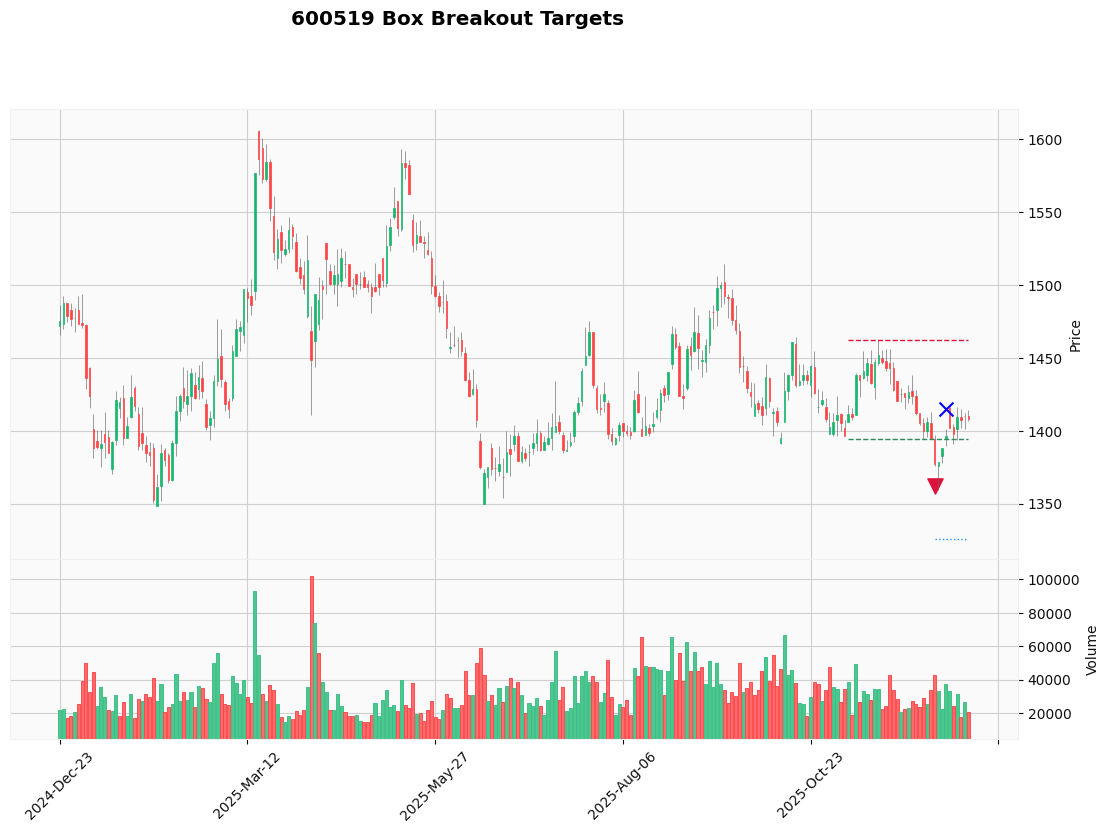

In [37]:
import akshare as ak
import pandas as pd
import numpy as np
import mplfinance as mpf
from datetime import datetime, timedelta

# ========== 1. 获取最近一年的日线数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

high = df['High']
low  = df['Low']
close = df['Close']

# ========== 2. 简单“箱体区间”识别 ==========
# 思路：在 rolling 窗口内，高低点波动幅度小于阈值，就认为是横盘区。然后取该窗口的最高/最低作为箱体顶/底。[web:243][web:255]

window = 30        # 箱体识别窗口长度（天数，可调）
max_span_pct = 0.06  # 价格高低差不超过 6% 视为横盘

rolling_max = high.rolling(window).max()
rolling_min = low.rolling(window).min()
span_pct = (rolling_max - rolling_min) / rolling_min

is_box = span_pct <= max_span_pct

# 取最近一个箱体区间（也可以遍历所有 True 区段）
# 找到连续 True 的最后一段
box_end = None
box_start = None

in_box = False
for i in range(len(is_box)-1, -1, -1):
    if is_box.iloc[i] and not in_box:
        in_box = True
        box_end = is_box.index[i]
    if in_box and not is_box.iloc[i]:
        box_start = is_box.index[i+1]
        break

if box_start is None or box_end is None:
    print("当前参数下未识别到箱体区间，可调整 window / max_span_pct。")
else:
    box_df = df.loc[box_start:box_end]
    box_low  = box_df['Low'].min()
    box_high = box_df['High'].max()
    box_height = box_high - box_low

    print(f"箱体区间: {box_start.date()} ~ {box_end.date()}")
    print(f"箱体底部: {box_low:.2f}, 箱体顶部: {box_high:.2f}, 高度: {box_height:.2f}")

# ========== 3. 检测箱体突破 & 目标价 ==========
df['BoxLow']  = np.nan
df['BoxHigh'] = np.nan
df['Target_Up']   = np.nan
df['Target_Down'] = np.nan
df['BreakUp']   = False
df['BreakDown'] = False

if box_start is not None:
    df.loc[box_start:, 'BoxLow']  = box_low
    df.loc[box_start:, 'BoxHigh'] = box_high

    # 有效向上突破：收盘价首次明显高于箱体顶
    # 有效向下突破：收盘价首次明显低于箱体底
    buf_pct = 0.002  # 突破缓冲，避免虚假触碰

    after_box = df.loc[box_end:]
    up_break_idx = after_box[
        (after_box['Close'] > box_high * (1 + buf_pct))
    ].index

    down_break_idx = after_box[
        (after_box['Close'] < box_low * (1 - buf_pct))
    ].index

    if len(up_break_idx) > 0:
        bidx_up = up_break_idx[0]
        df.at[bidx_up, 'BreakUp'] = True
        # 目标价 = 箱体高度 + 箱体顶（或突破价）
        df['Target_Up'] = np.where(df.index >= bidx_up, box_high + box_height, np.nan)
        print(f"向上突破日期: {bidx_up.date()}, 上方目标价约为: {box_high + box_height:.2f}")

    if len(down_break_idx) > 0:
        bidx_dn = down_break_idx[0]
        df.at[bidx_dn, 'BreakDown'] = True
        df['Target_Down'] = np.where(df.index >= bidx_dn, box_low - box_height, np.nan)
        print(f"向下突破日期: {bidx_dn.date()}, 下方目标价约为: {box_low - box_height:.2f}")

# ========== 4. 失效条件（极性转换 + 收盘回箱体内） ==========
# 按书中思路：向上突破后若收盘跌回箱顶下方，则上方目标失效；向下突破反之。[web:243]

df['Up_Invalid'] = False
df['Dn_Invalid'] = False

if box_start is not None and len(after_box) > 0:
    if len(up_break_idx) > 0:
        bidx_up = up_break_idx[0]
        tmp = df.loc[bidx_up:]
        inv_idx = tmp[tmp['Close'] < box_high].index
        if len(inv_idx) > 0:
            df.at[inv_idx[0], 'Up_Invalid'] = True
            print(f"向上突破目标在 {inv_idx[0].date()} 失效（收盘跌回箱体顶下方）。")

    if len(down_break_idx) > 0:
        bidx_dn = down_break_idx[0]
        tmp = df.loc[bidx_dn:]
        inv_idx = tmp[tmp['Close'] > box_low].index
        if len(inv_idx) > 0:
            df.at[inv_idx[0], 'Dn_Invalid'] = True
            print(f"向下突破目标在 {inv_idx[0].date()} 失效（收盘回到箱体底上方）。")

# ========== 5. 可视化 ==========
ap = []

# 画箱体上下边界
if box_start is not None:
    ap.append(
        mpf.make_addplot(
            df['BoxLow'],
            color='seagreen',
            linestyle='--',
            width=1
        )
    )
    ap.append(
        mpf.make_addplot(
            df['BoxHigh'],
            color='crimson',
            linestyle='--',
            width=1
        )
    )

# 画目标价线
if not df['Target_Up'].isna().all():
    ap.append(
        mpf.make_addplot(
            df['Target_Up'],
            color='orange',
            linestyle=':',
            width=1
        )
    )
if not df['Target_Down'].isna().all():
    ap.append(
        mpf.make_addplot(
            df['Target_Down'],
            color='dodgerblue',
            linestyle=':',
            width=1
        )
    )

# 突破点和失效点标记
up_marks = np.where(df['BreakUp'], df['High'] * 1.01, np.nan)
dn_marks = np.where(df['BreakDown'], df['Low']  * 0.99, np.nan)
up_inv   = np.where(df['Up_Invalid'], df['Low'] * 0.99, np.nan)
dn_inv   = np.where(df['Dn_Invalid'], df['High']* 1.01, np.nan)

if not np.all(np.isnan(up_marks)):
    ap.append(
        mpf.make_addplot(
            up_marks,
            type='scatter',
            marker='^',
            color='seagreen',
            markersize=120
        )
    )
if not np.all(np.isnan(dn_marks)):
    ap.append(
        mpf.make_addplot(
            dn_marks,
            type='scatter',
            marker='v',
            color='crimson',
            markersize=120
        )
    )
if not np.all(np.isnan(up_inv)):
    ap.append(
        mpf.make_addplot(
            up_inv,
            type='scatter',
            marker='x',
            color='red',
            markersize=100
        )
    )
if not np.all(np.isnan(dn_inv)):
    ap.append(
        mpf.make_addplot(
            dn_inv,
            type='scatter',
            marker='x',
            color='blue',
            markersize=100
        )
    )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Box Breakout Targets',
    figsize=(14, 9)
)


# 对等运动、旗形与尖旗形（三角旗形）

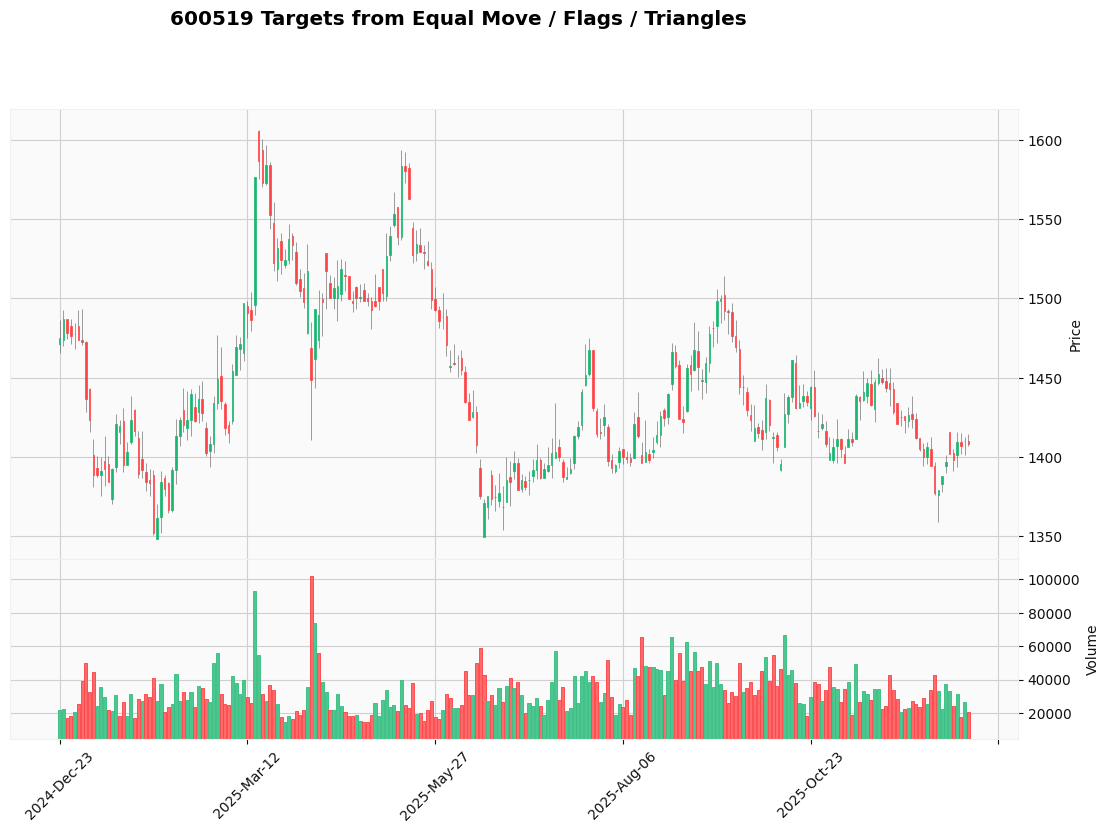

In [38]:
# ========== 1. 拉取数据 ==========
symbol_code = '600519'
end_dt   = datetime.today()
start_dt = end_dt - timedelta(days=365)

df_raw = ak.stock_zh_a_hist(
    symbol=symbol_code,
    period='daily',
    start_date=start_dt.strftime('%Y%m%d'),
    end_date=end_dt.strftime('%Y%m%d'),
    adjust='qfq'
)

df = (
    df_raw
    .rename(columns={
        '日期': 'Date',
        '开盘': 'Open',
        '最高': 'High',
        '最低': 'Low',
        '收盘': 'Close',
        '成交量': 'Volume'
    })
    .loc[:, ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    .assign(Date=lambda x: pd.to_datetime(x['Date']))
    .set_index('Date')
    .sort_index()
)

# 方便引用
high = df['High']
low  = df['Low']
close = df['Close']

# ========== 2. 对等运动目标：AB 高度 + C ==========
def equal_move_target(A_date, B_date, C_date, up=True):
    """
    A_date, B_date, C_date 用 'YYYY-MM-DD' 传入你肉眼圈出来的 A/B/C 三点日期。
    上涨对等运动：高度 = B 高点 - A 低点，目标 = C 低点 + 高度
    下跌对等运动：高度 = A 高点 - B 低点，目标 = C 高点 - 高度
    """
    A = pd.to_datetime(A_date)
    B = pd.to_datetime(B_date)
    C = pd.to_datetime(C_date)

    if up:
        A_low = low.loc[A]
        B_high = high.loc[B]
        C_low = low.loc[C]
        height = B_high - A_low
        target = C_low + height
    else:
        A_high = high.loc[A]
        B_low  = low.loc[B]
        C_high = high.loc[C]
        height = A_high - B_low
        target = C_high - height

    return float(height), float(target)

# 示例：填你自己的三个日期
# hgt, tgt = equal_move_target("2025-01-10", "2025-01-20", "2025-02-05", up=True)
# print("对等运动高度:", hgt, "上方目标:", tgt)

# ========== 3. 看涨/看跌旗形或尖旗形目标 ==========
def flag_target(A_date, B_date, C_date, bullish=True, conservative=True):
    """
    A: 旗杆起点，B: 旗杆终点，C: 旗形/尖旗形底边（看涨）或顶边（看跌）。
    bullish=True 为看涨旗形：高度 = B 高点 - A 低点
        - 保守：目标 = C 底边价 + 高度
        - 传统：目标 = 旗形/尖旗顶边价 + 高度（可自行传入另一个 D）
    bearish=True 则相反：高度 = A 高点 - B 低点
        - 保守：目标 = C 顶边价 - 高度
    """
    A = pd.to_datetime(A_date)
    B = pd.to_datetime(B_date)
    C = pd.to_datetime(C_date)

    if bullish:
        A_low = low.loc[A]
        B_high = high.loc[B]
        C_low  = low.loc[C]   # 旗形底
        height = B_high - A_low
        target = C_low + height
    else:
        A_high = high.loc[A]
        B_low  = low.loc[B]
        C_high = high.loc[C]  # 旗形顶
        height = A_high - B_low
        target = C_high - height

    return float(height), float(target)

# ========== 4. 上升/下降三角形目标 ==========
def triangle_target(horiz_price, tip_date_A, tip_price_B, up_triangle=True):
    """
    上升三角形：
        - 水平边为阻力（horiz_price）
        - 最宽处高度 = 阻力价 - 三角形起始低点
        - 目标 = 水平阻力 + 高度
    下降三角形：
        - 水平边为支撑（horiz_price）
        - 高度 = 起始高点 - 支撑价
        - 目标 = 支撑价 - 高度

    这里 tip_date_A / tip_price_B 只是辅助：你可以用起始最低/最高价直接代替。
    简化处理：上升三角形取某个早期低点 tip_price_B；下降三角形则取某个早期高点。
    """
    if up_triangle:
        base = float(horiz_price)
        low0 = float(tip_price_B)   # 你挑的三角形“最早低点”
        height = base - low0
        target = base + height
    else:
        base = float(horiz_price)
        high0 = float(tip_price_B)  # 你挑的三角形“最早高点”
        height = high0 - base
        target = base - height

    return float(height), float(target)

# ========== 5. 示例：把计算结果画在图上 ==========
# 你先用图形肉眼圈出一组形态，再在下面填参数测试

# 例：假设识别了一段上升对等运动
# hgt_eq, tgt_eq = equal_move_target("2025-01-10", "2025-01-20", "2025-02-05", up=True)
# df['EqTarget'] = np.where(df.index >= pd.to_datetime("2025-02-05"), tgt_eq, np.nan)

# 例：假设识别了看涨旗形
# hgt_flag, tgt_flag = flag_target("2025-03-01", "2025-03-10", "2025-03-18", bullish=True)
# df['FlagTarget'] = np.where(df.index >= pd.to_datetime("2025-03-18"), tgt_flag, np.nan)

# 例：假设识别了下降三角形，水平支撑在 135.0，早期高点在 138.2
# hgt_tri, tgt_tri = triangle_target(135.0, None, 138.2, up_triangle=False)
# df['TriTarget'] = tgt_tri  # 简化：画一条水平线

# ========== 6. 画图（把你实际用到的目标线列出来） ==========
ap = []

for col, color in [('EqTarget', 'orange'),
                   ('FlagTarget', 'dodgerblue'),
                   ('TriTarget', 'purple')]:
    if col in df.columns and not df[col].isna().all():
        ap.append(
            mpf.make_addplot(
                df[col],
                color=color,
                linestyle=':',
                width=1
            )
        )

mpf.plot(
    df,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title=f'{symbol_code} Targets from Equal Move / Flags / Triangles',
    figsize=(14, 9)
)
